In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py as h5 
from astropy import units as u
from astropy import constants as c

import scipy
import os

pd.options.display.max_columns = None

In [53]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
rcParams['font.family'] = 'serif'
rcParams["mathtext.fontset"] = 'stix'
rcParams["font.size"] = 13

%config InlineBackend.figure_format='retina' # very useful command for high-res images


In [54]:
colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

# Test Binaries

In [55]:
frac_limit = 1e-4

In [56]:
st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']
st_labels_plot = ['MS', 'MS', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

def compare_tides(df_sanity, imk22_core_gw, imk22_env_gw, imk22_inertial, Imk22_eq):
    M = df_sanity["M1"].values * u.M_sun                    # Msol
    Mc = df_sanity["M1_core"].values * u.M_sun              # Msol
    Menv = df_sanity["M1_conv_env"].values * u.M_sun        # Msol
    Mint = M - Mc - Menv     

    stellar_type = df_sanity["StellarType_1"].values
            

    print("Convective core, NO radiative intershell, convective envelope:")
    mask = (Menv/M > frac_limit) * ((Mint/M)<frac_limit)
    if np.sum(mask) > 0:
        print("Timesteps found:", np.sum(mask))
        print("Stellar Types found:", [st_labels[int(st)] for st in np.unique(stellar_type[mask])])
        print("Dynamical tides from convective core - radiative shell boundary:", np.sum(imk22_core_gw[mask]))
        print("Dynamical tides from radiative shell - convective envelope boundary:", np.sum(imk22_env_gw[mask]))
        print("*Dynamical tides from convective envelope IW dissipation:", np.nansum(imk22_inertial[mask]))
        print("*Equilibrium tides from convective envelope:", np.nansum(Imk22_eq[mask]))
    else:
        print("No timesteps found")

    print()
    print("Convective core, radiative intershell, convective envelope:")
    mask = (Menv/M > frac_limit) * ((Mint/M)>frac_limit)
    if np.sum(mask) > 0:
        print("Timesteps found:", np.sum(mask))
        print("Stellar Types found:", [st_labels[int(st)] for st in np.unique(stellar_type[mask])])
        print("Dynamical tides from convective core - radiative shell boundary:", np.sum(imk22_core_gw[mask]))
        print("Dynamical tides from radiative shell - convective envelope boundary:", np.sum(imk22_env_gw[mask]))
        print("*Dynamical tides from convective envelope IW dissipation:", np.nansum(imk22_inertial[mask]))
        print("*Equilibrium tides from convective envelope:", np.nansum(Imk22_eq[mask]))
    else:
        print("No timesteps found")

    print()
    print("Convective core, radiative envelope:")
    mask = (Menv/M < frac_limit) * ((Mint/M)>frac_limit) * (Mc/M > frac_limit)
    if np.sum(mask) > 0:
        print("Timesteps found:", np.sum(mask))
        print("Stellar Types found:", [st_labels[int(st)] for st in np.unique(stellar_type[mask])])
        print("*Dynamical tides from convective core - radiative shell boundary:", np.nansum(imk22_core_gw[mask]))
        print("Dynamical tides from radiative shell - convective envelope boundary:", np.nansum(imk22_env_gw[mask]))
        print("Dynamical tides from convective envelope IW dissipation:", np.nansum(imk22_inertial[mask]))
        print("Equilibrium tides from convective envelope:", np.nansum(Imk22_eq[mask]))
    else:
        print("No timesteps found")

    print()
    print("Radiative core, convective envelope:")
    mask = (Menv/M > frac_limit) * (Mc/M < frac_limit)
    if np.sum(mask) > 0:
        print("Timesteps found:", np.sum(mask))
        print("Stellar Types found:", [st_labels[int(st)] for st in np.unique(stellar_type[mask])])
        print("Dynamical tides from convective core - radiative shell boundary:", np.nansum(imk22_core_gw[mask]))
        print("*Dynamical tides from radiative shell - convective envelope boundary:", np.nansum(imk22_env_gw[mask]))
        print("*Dynamical tides from convective envelope IW dissipation:", np.nansum(imk22_inertial[mask]))
        print("*Equilibrium tides from convective envelope:", np.nansum(Imk22_eq[mask]))
    else:
        print("No timesteps found")


In [57]:
# Define plotting labels

this_work = 'Fiducial'
that_work = 'Z77'

PlotDir = 'paper_plots/'

## Low Mass MS (Figure 3)

COMPAS --number-of-systems 1 --random-seed 1 --output-path sim_data --output-container low_mass --initial-mass-1 0.3 --initial-mass-2 0.3 --orbital-period 2.0 --eccentricity 0.1 --chemically-homogeneous-evolution-mode NONE --tides-prescription KAPIL2026 --maximum-number-timestep-iterations 199999 

COMPAS --number-of-systems 1 --random-seed 1 --output-path sim_data --output-container low_mass_z77 --initial-mass-1 0.3 --initial-mass-2 0.3 --orbital-period 2.0 --eccentricity 0.1 --chemically-homogeneous-evolution-mode NONE --tides-prescription ZAHN1977

In [ ]:
plot_prefix = 'low_mass_'

In [49]:
DataPath = 'sim_data/low_mass'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())
pd.options.display.max_columns = None

df_sanity

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1,0.000000,0.001262,0,0,0.117581,0.117581,0.117581,0.117581,0.000000e+00,6.691220e-12,0.000000e+00,6.691220e-12,1147.47,1147.47,0.000000,0.000115,0.000000,0.000115,0.100000,0.100000,0.3,0.299898,5.835280e-08,5.835280e-08,0.3,0.299898,5.835280e-08,5.835280e-08,0.026203,0.026203,1.177640e-10,1.177640e-10,1.177640e-10,1.177640e-10,5.888220e-11,5.888220e-11,3.925480e-11,3.925480e-11,0,0,0,0,0,0,0,0,1.177640e-10,1.177640e-10,1.177640e-10,1.177640e-10,5.888220e-11,5.888220e-11,3.925480e-11,3.925480e-11,0.082755,0,0.082755,0,0.300000,0.3,0.300000,0.3,0.299898,0.299898,0.298254,0.298254,0.013580,0.013580,0.623356,0.623356,-2.473140e-15,-2.473140e-15,9.089590e-08,9.089590e-08,-2.092640e-14,-2.092640e-14,105949.00,47786.5,126.2400,126.2400,0,0,0,0,1.414400e-11,1.414400e-11,1.414400e-11,1.414400e-11,2.828790e-11,2.828790e-11,4.243190e-11,4.243190e-11,1.054020e-15,1.054020e-15,1.054020e-15,1.054020e-15,6.692580e-15,6.692580e-15,1.973200e-14,1.973200e-14,-1.341120e-15,-1.341120e-15,-1.872880e-14,-1.872880e-14,4.782300e-08,4.782300e-08
1,1,0.001262,1.262400,0,0,0.117581,0.117581,0.117581,0.117581,6.691220e-12,6.697910e-09,6.691220e-12,6.697910e-09,1147.47,1147.47,0.000115,0.114783,0.000115,0.114783,0.100000,0.100000,0.3,0.299898,5.835280e-08,5.835280e-08,0.3,0.299898,5.835280e-08,5.835280e-08,0.026203,0.026203,1.177640e-10,1.177640e-10,1.177640e-10,1.177640e-10,5.888220e-11,5.888220e-11,3.925480e-11,3.925480e-11,0,0,0,0,0,0,0,0,1.177640e-10,1.177640e-10,1.177640e-10,1.177640e-10,5.888220e-11,5.888220e-11,3.925480e-11,3.925480e-11,0.082755,0,0.082755,0,0.300000,0.3,0.300000,0.3,0.299898,0.299898,0.298254,0.298254,0.013580,0.013580,0.623356,0.623356,-2.473140e-15,-2.473140e-15,9.089590e-08,9.089590e-08,-2.092640e-14,-2.092640e-14,105949.00,47786.5,126.2400,126.2400,0,0,0,0,1.414400e-11,1.414400e-11,1.414400e-11,1.414400e-11,2.828800e-11,2.828800e-11,4.243190e-11,4.243190e-11,1.054020e-15,1.054020e-15,1.054010e-15,1.054010e-15,6.692580e-15,6.692580e-15,1.973200e-14,1.973200e-14,-1.341120e-15,-1.341120e-15,-1.872880e-14,-1.872880e-14,4.782300e-08,4.782300e-08
2,1,1.263660,1.262270,0,0,0.117581,0.117581,0.117581,0.117581,6.697910e-09,1.338910e-08,6.697910e-09,1.338910e-08,1147.47,1147.47,0.114783,0.229451,0.114783,0.229451,0.100000,0.100000,0.3,0.299898,5.835290e-08,5.835290e-08,0.3,0.299898,5.835290e-08,5.835290e-08,0.026203,0.026203,1.177640e-10,1.177640e-10,1.177880e-10,1.177880e-10,5.888810e-11,5.888810e-11,3.925740e-11,3.925740e-11,0,0,0,0,0,0,0,0,1.177640e-10,1.177640e-10,1.177880e-10,1.177880e-10,5.888810e-11,5.888810e-11,3.925740e-11,3.925740e-11,0.082755,0,0.082755,0,0.300000,0.3,0.300000,0.3,0.299898,

In [50]:
DataPath_Zahn = 'sim_data/low_mass_z77'

df_sanity_zahn = pd.read_csv(DataPath_Zahn+'/sanity_checks.csv')
df_sanity_zahn = df_sanity_zahn.rename(columns=lambda x: x.strip())

df_sanity_zahn

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1,0.00000,3.90497,0,0,0.117581,0.117581,0.117581,0.117581,0.000000e+00,1.089720e-08,0.000000e+00,1.089720e-08,1147.47,1147.47,0.000000,0.186747,0.000000,0.186747,0.100000,0.100000,0.3,0.299898,5.835280e-08,5.835280e-08,0.3,0.299898,5.835280e-08,5.835280e-08,0.026203,0.026203,1.177640e-10,1.177640e-10,1.177640e-10,1.177640e-10,5.888220e-11,5.888220e-11,3.925480e-11,3.925480e-11,0,0,0,0,0,0,0,0,1.177640e-10,1.177640e-10,1.177640e-10,1.177640e-10,5.888220e-11,5.888220e-11,3.925480e-11,3.925480e-11,0.082755,0,0.082755,0,0.300000,0.3,0.300000,0.3,0.299898,0.299898,0.298254,0.298254,0.013580,0.013580,0.623356,0.623356,-2.473140e-15,-2.473140e-15,9.089590e-08,9.089590e-08,-2.092640e-14,-2.092640e-14,105949.0,47786.5,126.240,126.240,0,0,0,0,1.414400e-11,1.414400e-11,1.414400e-11,1.414400e-11,2.828790e-11,2.828790e-11,4.243190e-11,4.243190e-11,1.054020e-15,1.054020e-15,1.054020e-15,1.054020e-15,6.692580e-15,6.692580e-15,1.973200e-14,1.973200e-14,-1.341120e-15,-1.341120e-15,-1.872880e-14,-1.872880e-14,4.782300e-08,4.782300e-08
1,1,3.90497,3904.97000,0,0,0.117581,0.117581,0.117581,0.117579,1.089720e-08,6.804790e-07,1.089720e-08,6.804790e-07,1147.47,1147.51,0.186747,11.661400,0.186747,11.661400,0.100000,0.099991,0.3,0.299899,5.835300e-08,5.835300e-08,0.3,0.299899,5.835300e-08,5.835300e-08,0.026203,0.026202,1.177640e-10,1.177640e-10,1.178030e-10,1.178030e-10,5.889180e-11,5.889180e-11,3.925910e-11,3.925910e-11,0,0,0,0,0,0,0,0,1.177640e-10,1.177640e-10,1.178030e-10,1.178030e-10,5.889180e-11,5.889180e-11,3.925910e-11,3.925910e-11,0.082755,0,0.082755,0,0.299999,0.3,0.299999,0.3,0.299898,0.299898,0.298254,0.298254,0.013580,0.013580,0.623356,0.623356,-2.473550e-15,-2.473550e-15,9.091120e-08,9.091120e-08,-2.092790e-14,-2.092790e-14,105931.0,47783.1,126.219,126.219,0,0,0,0,1.414860e-11,1.414860e-11,1.414400e-11,1.414400e-11,2.829270e-11,2.829270e-11,4.244130e-11,4.244130e-11,1.054030e-15,1.054030e-15,1.053110e-15,1.053110e-15,6.689740e-15,6.689740e-15,1.972650e-14,1.972650e-14,-1.341380e-15,-1.341380e-15,-1.873330e-14,-1.873330e-14,4.783190e-08,4.783190e-08
2,1,3908.87000,3904.97000,0,0,0.117581,0.117581,0.117579,0.117578,6.804790e-07,1.352890e-06,6.804790e-07,1.352890e-06,1147.51,1147.55,11.612900,23.088000,11.612900,23.088000,0.099991,0.099982,0.3,0.300525,5.859700e-08,5.859700e-08,0.3,0.300525,5.859700e-08,5.859700e-08,0.026202,0.026201,1.178070e-10,1.178070e-10,1.202410e-10,1.202410e-10,5.950590e-11,5.950590e-11,3.953580e-11,3.953580e-11,0,0,0,0,0,0,0,0,1.178070e-10,1.178070e-10,1.202410e-10,1.202410e-10,5.950590e-11,5.950590e-11,3.953580e-11,3.953580e-11,0.082424,0,0.082424,0,0.299246,0.3,0.299246,0.3,0.2997

In [51]:
rc = df_sanity["R1_core"].values * u.R_sun              # Rsol
R = df_sanity["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

rc2 = df_sanity["R2_core"].values * u.R_sun              # Rsol
R2 = df_sanity["R2"].values * u.R_sun                    # Rsol
Renv2 = df_sanity["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2 = R2 - Renv2

L = df_sanity["Lum_1"].values * u.L_sun                 # Lsol
L2 = df_sanity["Lum_2"].values * u.L_sun                 # Lsol

M = df_sanity["M1"].values * u.M_sun                    # Msol
Mc = df_sanity["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity["M2"].values * u.M_sun                   # Msol
Mc2 = df_sanity["M2_core"].values * u.M_sun              # Msol
Menv2 = df_sanity["M2_conv_env"].values * u.M_sun        # Msol


I1 = df_sanity["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity["tau_conv1"].values * u.yr                # yr
tau_conv2 = df_sanity["tau_conv2"].values * u.yr                # yr


omega_orb = df_sanity["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity["Omega1_before"].values / u.yr   # 1/yr
omega_spin2 = df_sanity["Omega2_before"].values / u.yr   # 1/yr

sma = df_sanity["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity["ecc_before"].values                           # 1
period_orb = 2 * np.pi / df_sanity["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk10 = df_sanity["ImK10_1"].values
Imk12 = df_sanity["ImK12_1"].values
Imk22 = df_sanity["ImK22_1"].values
Imk32 = df_sanity["ImK32_1"].values

Imk10_dyn = df_sanity["ImK10_1_dyn"].values
Imk12_dyn = df_sanity["ImK12_1_dyn"].values
Imk22_dyn = df_sanity["ImK22_1_dyn"].values
Imk32_dyn = df_sanity["ImK32_1_dyn"].values

Imk10_eq = df_sanity["ImK10_1_eq"].values
Imk12_eq = df_sanity["ImK12_1_eq"].values
Imk22_eq = df_sanity["ImK22_1_eq"].values
Imk32_eq = df_sanity["ImK32_1_eq"].values

Imk10_2 = df_sanity["ImK10_2"].values
Imk12_2 = df_sanity["ImK12_2"].values
Imk22_2 = df_sanity["ImK22_2"].values
Imk32_2 = df_sanity["ImK32_2"].values

Imk10_2_dyn = df_sanity["ImK10_2_dyn"].values
Imk12_2_dyn = df_sanity["ImK12_2_dyn"].values
Imk22_2_dyn = df_sanity["ImK22_2_dyn"].values
Imk32_2_dyn = df_sanity["ImK32_2_dyn"].values

Imk10_2_eq = df_sanity["ImK10_2_eq"].values
Imk12_2_eq = df_sanity["ImK12_2_eq"].values
Imk22_2_eq = df_sanity["ImK22_2_eq"].values
Imk32_2_eq = df_sanity["ImK32_2_eq"].values

dadt = df_sanity["dadt1"].values * u.AU / u.yr
dOmegadt = df_sanity["dOmegadt1"].values / u.yr**2
dedt1 = df_sanity["dedt1"].values / u.yr


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity["StellarType_1"].values
st2 = df_sanity["StellarType_2"].values

rc_AU = df_sanity["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     

rc_AU2 = df_sanity["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2 = df_sanity["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2 = df_sanity["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2 = R_AU2 - Renv_AU2                 
Mint2 = M2 - Mc2 - Menv2    

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [52]:
rc_zahn = df_sanity_zahn["R1_core"].values * u.R_sun              # Rsol
R_zahn = df_sanity_zahn["R1"].values * u.R_sun                    # Rsol
Renv_zahn = df_sanity_zahn["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint_zahn = R_zahn - Renv_zahn

rc2_zahn = df_sanity_zahn["R2_core"].values * u.R_sun              # Rsol
R2_zahn = df_sanity_zahn["R2"].values * u.R_sun                    # Rsol
Renv2_zahn = df_sanity_zahn["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2_zahn = R2_zahn - Renv2_zahn

L_zahn = df_sanity_zahn["Lum_1"].values * u.L_sun                 # Lsol
L2_zahn = df_sanity_zahn["Lum_2"].values * u.L_sun                 # Lsol

M_zahn = df_sanity_zahn["M1"].values * u.M_sun                    # Msol
Mc_zahn = df_sanity_zahn["M1_core"].values * u.M_sun              # Msol
Menv_zahn = df_sanity_zahn["M1_conv_env"].values * u.M_sun        # Msol

M2_zahn = df_sanity_zahn["M2"].values * u.M_sun                   # Msol
Mc2_zahn = df_sanity_zahn["M2_core"].values * u.M_sun              # Msol
Menv2_zahn = df_sanity_zahn["M2_conv_env"].values * u.M_sun        # Msol


I1_zahn = df_sanity_zahn["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv_zahn = df_sanity_zahn["tau_conv1"].values * u.yr                # yr
tau_conv2_zahn = df_sanity_zahn["tau_conv2"].values * u.yr                # yr


omega_orb_zahn = df_sanity_zahn["Omega_before"].values / u.yr     # 1/yr
omega_spin_zahn = df_sanity_zahn["Omega1_before"].values / u.yr   # 1/yr
omega_spin2_zahn = df_sanity_zahn["Omega2_before"].values / u.yr   # 1/yr

sma_zahn = df_sanity_zahn["SemiMajorAxis_before"].values * u.AU   # AU
ecc_zahn = df_sanity_zahn["ecc_before"].values                           # 1
period_orb_zahn = 2 * np.pi / df_sanity_zahn["Omega_before"].values * u.yr.to(u.day) * u.day     # days


Imk10_eq_zahn = df_sanity_zahn["ImK10_Zahn_Equilibrium1"].values
Imk12_eq_zahn = df_sanity_zahn["ImK12_Zahn_Equilibrium1"].values
Imk22_eq_zahn = df_sanity_zahn["ImK22_Zahn_Equilibrium1"].values
Imk32_eq_zahn = df_sanity_zahn["ImK32_Zahn_Equilibrium1"].values

Imk10_dyn_zahn = df_sanity_zahn["ImK10_Zahn_Dynamical1"].values
Imk12_dyn_zahn = df_sanity_zahn["ImK12_Zahn_Dynamical1"].values
Imk22_dyn_zahn = df_sanity_zahn["ImK22_Zahn_Dynamical1"].values
Imk32_dyn_zahn = df_sanity_zahn["ImK32_Zahn_Dynamical1"].values

Imk22_zahn = Imk22_dyn_zahn + Imk22_eq_zahn

Imk22_2_dyn_zahn = df_sanity_zahn["ImK22_Zahn_Dynamical2"].values
Imk22_2_eq_zahn = df_sanity_zahn["ImK22_Zahn_Equilibrium2"].values
Imk22_2_zahn = Imk22_2_dyn_zahn + Imk22_2_eq_zahn


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time_zahn = df_sanity_zahn["Time"].values * 1e6 * u.yr          # yr
st1_zahn = df_sanity_zahn["StellarType_1"].values
st2_zahn = df_sanity_zahn["StellarType_2"].values

rc_AU_zahn = df_sanity_zahn["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU_zahn = df_sanity_zahn["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU_zahn = df_sanity_zahn["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU_zahn = R_AU_zahn - Renv_AU_zahn
Mint_zahn = M_zahn - Mc_zahn - Menv_zahn


rc_AU2_zahn = df_sanity_zahn["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2_zahn = df_sanity_zahn["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2_zahn = df_sanity_zahn["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2_zahn = R_AU2_zahn - Renv_AU2_zahn
Mint2_zahn = M2_zahn - Mc2_zahn - Menv2_zahn

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

### Stellar Evolution

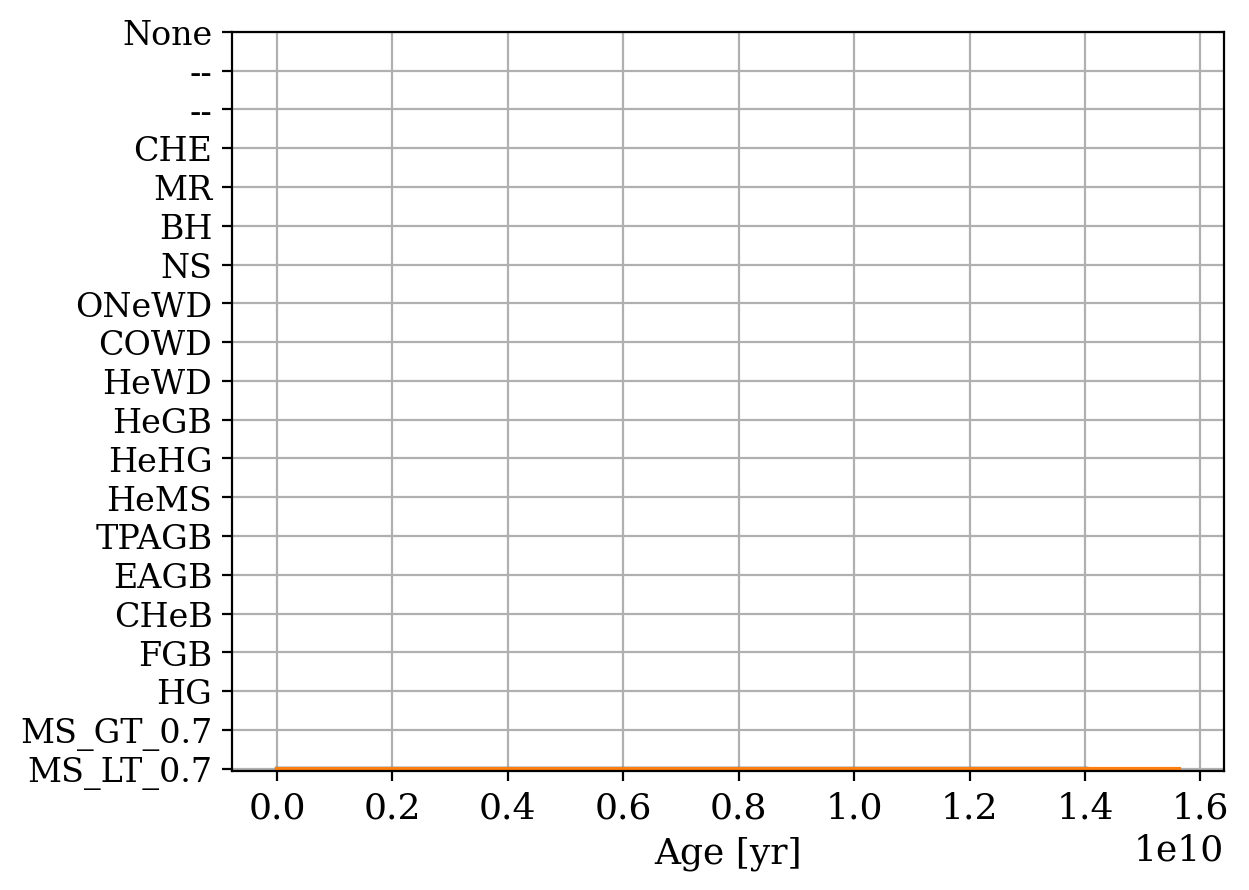

In [53]:
plt.plot(Time, st1)
plt.plot(Time_zahn, st1_zahn)
y_ticks=np.linspace(0, 19, 20)
plt.yticks(y_ticks, st_labels, fontsize=12)

plt.xlabel("Age [yr]")
plt.grid()
plt.show()

### Stellar Structure

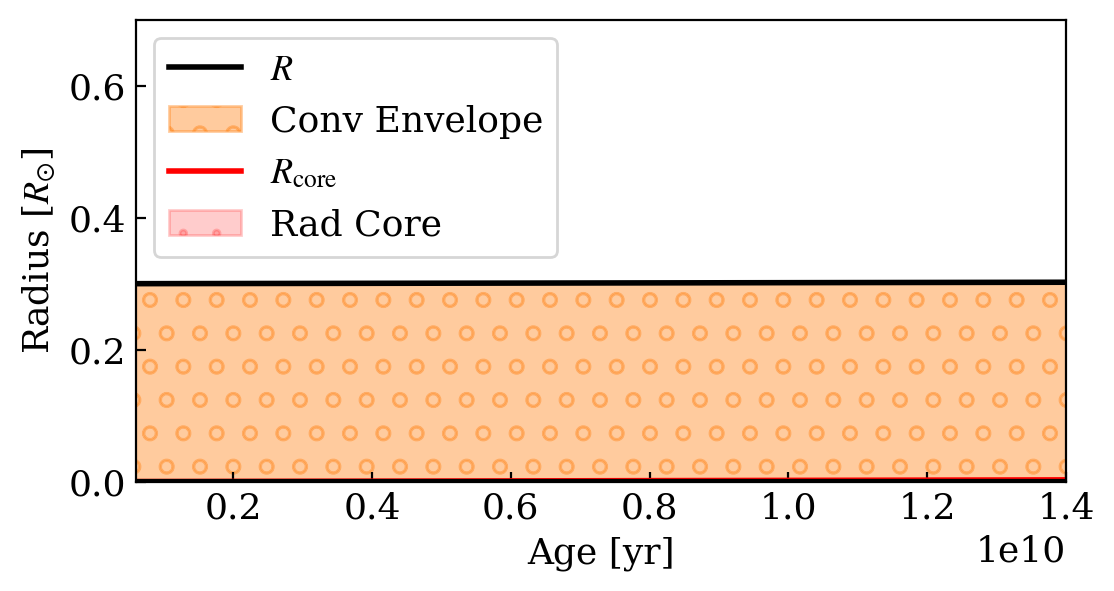

In [54]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

plt.plot(Time, R, c='k', zorder=10, lw=2, label="$R$")

if any(Renv/R > frac_limit):
    plt.fill_between(Time.value, R.value, (R-Renv).value, color='C1', alpha=0.4, hatch="o", label="Conv Envelope")
elif any((R-rc)/R > frac_limit):
    plt.fill_between(Time.value, rc.value, R.value, color='r', alpha=0.4, hatch="o", label="Rad Envelope")

if any(rc/R > frac_limit):
    plt.plot(Time.value, rc.value, lw=2, c='r', label='$R_{\\rm core}$') 
    plt.fill_between(Time.value, 0, rc.value, color='C1', alpha=0.2, hatch=".", label="Conv Core")

elif any((R-Renv)/R > frac_limit):
    plt.plot(Time.value, (R-Renv).value, lw=2, c='r', label='$R_{\\rm core}$') 
    plt.fill_between(Time.value, 0, (R-Renv).value, color='r', alpha=0.2, hatch=".", label="Rad Core")

plt.plot(Time.value, np.zeros(len(Time)), lw=2, c='k')

plt.ylabel("Radius [$R_{\odot}$]")
plt.xlabel("Age [yr]")

ax.tick_params(axis='both', which='both', direction='in')


plt.ylim(0, 0.7)

plt.xlim(6e8, 1.4e10) # Low Mass

plt.legend(loc='upper left')

plt.savefig(PlotDir+plot_prefix+'stellar_structure.png',dpi=300, bbox_inches='tight')
plt.show()

### Orbital Properties

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


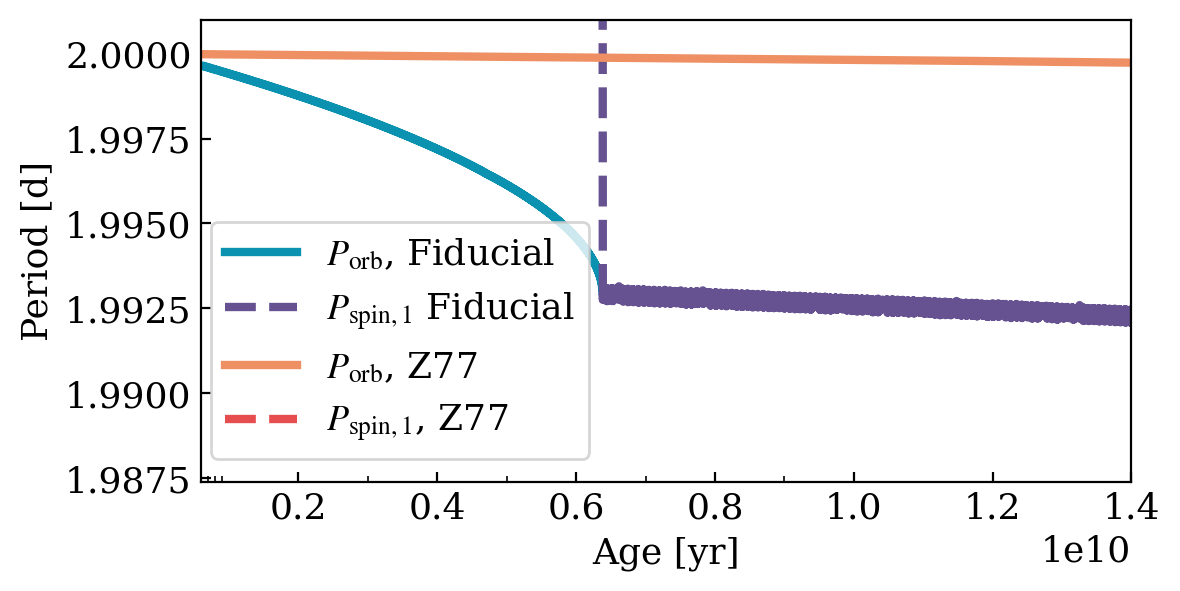

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

period_spin = 2 * np.pi / omega_spin.to(1/u.day)     # days
period_spin_zahn = 2 * np.pi / omega_spin_zahn.to(1/u.day)     # days

# Plot lines
ax.plot(Time, period_orb, lw=3, c=colorPalette['blue'], label='$P_{\\rm orb}$, '+this_work)
ax.plot(Time, period_spin, lw=3, c=colorPalette['violet'], ls='--', label='$P_{\\rm spin, 1}$ '+this_work)
ax.plot(Time_zahn, period_orb_zahn, lw=3, c=colorPalette['orange'], label='$P_{\\rm orb}$, '+that_work)
ax.plot(Time_zahn, period_spin_zahn, lw=3, c=colorPalette['red'], ls='--', label='$P_{\\rm spin, 1}$, '+that_work)

# Left Plot
# ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_ylabel("Period [d]")
ax.set_xlabel("Age [yr]")

ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.tick_params(axis='both', which='both', direction='in')

# Right Plot
ax.set_ylim(1.9874, 2.001)
ax.set_xlim(6e8, 1.4e10)

ax.legend(loc=(0.01, 0.05))

# fig.subplots_adjust(wspace=0.3)
# fig.text(0.5, -0.05, 'Age [yr]', ha='center')

plt.savefig(PlotDir+plot_prefix+'period_evolution.pdf',dpi=300, bbox_inches='tight')
plt.show()

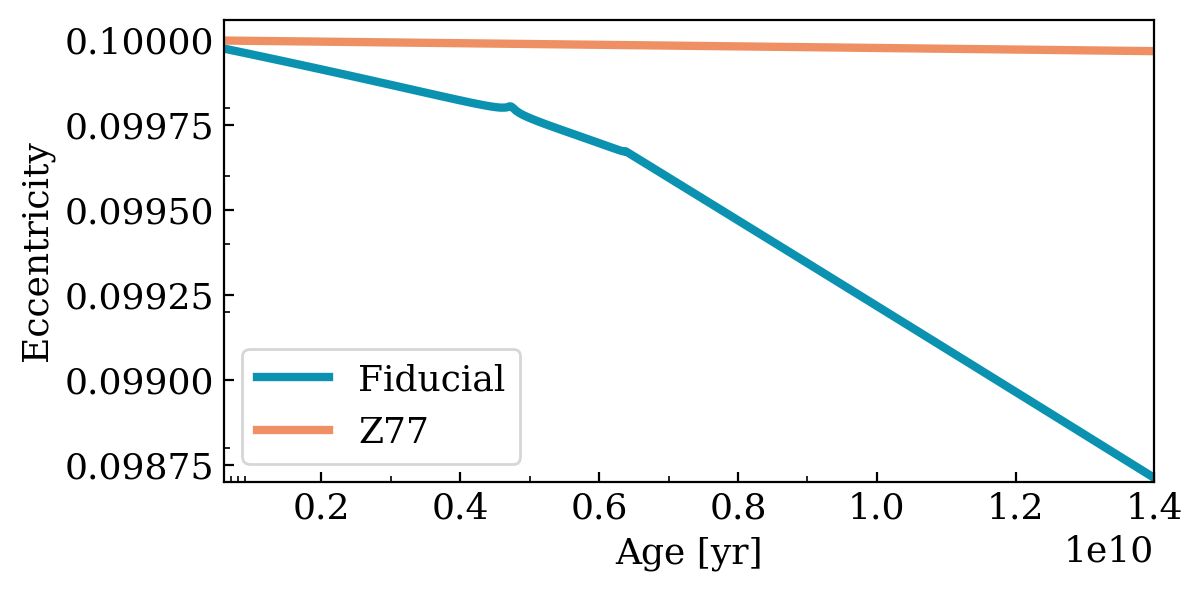

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

plt.plot(Time, ecc, lw=3, c=colorPalette['blue'], label=this_work)
plt.plot(Time_zahn, ecc_zahn, lw=3, c=colorPalette['orange'], label=that_work)

# plt.semilogx()
# plt.loglog()


ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))

plt.ylabel("Eccentricity")
plt.xlabel("Age [yr]")
ax.set_xlim(6e8, 1.4e10)
ax.set_ylim(0.0987, 0.10006)
ax.tick_params(axis='both', which='both', direction='in')

plt.legend()

plt.savefig(PlotDir+plot_prefix+'ecc_evolution.pdf',dpi=300, bbox_inches='tight')

plt.show()

### Equilibrium Tides

#### Fiducial

In [ ]:
dedt1_eq = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*Imk10_eq/2) - (Imk12_eq/4) - Imk22_eq + (49*Imk32_eq/4))
tau_circ_inv_eq = - dedt1_eq / ecc
1/tau_circ_inv_eq

<Quantity [4.77891600e+12, 4.77891600e+12, 4.77860261e+12, ...,
           2.46135698e+12, 1.08644903e+12, 2.46682463e+12] yr>

In [59]:
dedt1_eq_22 = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- Imk22_eq)
tau_circ_inv_eq_22 = - dedt1_eq_22 / ecc
1/tau_circ_inv_eq_22

<Quantity [-4.61961475e+13, -4.61961475e+13, -4.61901088e+13, ...,
           -4.31154844e+12,  3.54474773e+12, -4.29487323e+12] yr>

In [60]:
dOmegadt1_eq = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_eq + ecc**2 * ((Imk12_eq/4) - (5*Imk22_eq) + (49*Imk32_eq/4)))
tau_sync_inv_eq = - dOmegadt1_eq / (omega_spin - omega_orb)
1/tau_sync_inv_eq

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [1.26246197e+10, 1.26246184e+10, 1.26218530e+10, ...,
           5.55289569e+04, 6.67851943e+04, 5.53192413e+04] yr>

In [61]:
dOmegadt1_eq_22 = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_eq)
tau_sync_inv_eq_22 = - dOmegadt1_eq_22 / (omega_spin - omega_orb)
1/tau_sync_inv_eq_22

<Quantity [1.30875222e+10, 1.30875209e+10, 1.30846247e+10, ...,
           5.40998445e+04, 6.22696059e+04, 5.38906096e+04] yr>

#### Z77

In [62]:
dedt1_eq_zahn = -(3/4) * (ecc_zahn/omega_orb_zahn) * ((M_zahn + M2_zahn)/M_zahn) * (G_AU_Msol_yr*M2_zahn / R_AU_zahn**3) * (R_AU_zahn/sma_zahn)**8 * ((3*Imk10_eq_zahn/2) - (Imk12_eq_zahn/4) - Imk22_eq_zahn + (49*Imk32_eq_zahn/4))
tau_circ_inv_zahn_eq = - dedt1_eq_zahn / ecc_zahn
1/tau_circ_inv_zahn_eq

<Quantity [5.34214901e+12, 5.34066705e+12, 5.18345165e+12, 5.03025721e+12,
           4.88075658e+12, 4.73517637e+12] yr>

In [ ]:
dedt1_eq_22_zahn = -(3/4) * (ecc_zahn/omega_orb_zahn) * ((M_zahn + M2_zahn)/M_zahn) * (G_AU_Msol_yr*M2_zahn / R_AU_zahn**3) * (R_AU_zahn/sma_zahn)**8 * (- Imk22_eq_zahn)
tau_circ_inv_zahn_eq_22 = - dedt1_eq_22_zahn / ecc_zahn
1/tau_circ_inv_zahn_eq_22

<Quantity [-9.61588097e+13, -9.61379577e+13, -9.36732531e+13,
           -9.12647789e+13, -8.89069564e+13, -8.66048525e+13] yr>

In [64]:
dOmegadt1_eq_zahn = (3/2) * (1/I1_zahn) * (G_AU_Msol_yr*M2_zahn*M2_zahn / R_AU_zahn) * (R_AU_zahn/sma_zahn)**6 * (Imk22_eq_zahn + ecc_zahn**2 * ((Imk12_eq_zahn/4) - (5*Imk22_eq_zahn) + (49*Imk32_eq_zahn/4)))
tau_sync_inv_zahn_eq = - dOmegadt1_eq_zahn / (omega_spin_zahn - omega_orb_zahn)
1/tau_sync_inv_zahn_eq

<Quantity [2.40018548e+10, 2.39928188e+10, 2.32308696e+10, 2.24900308e+10,
           2.17689036e+10, 2.10683513e+10] yr>

In [65]:
dOmegadt1_eq_22 = (3/2) * (1/I1_zahn) * (G_AU_Msol_yr*M2_zahn*M2_zahn / R_AU_zahn) * (R_AU_zahn/sma_zahn)**6 * (Imk22_eq_zahn)
tau_sync_inv_zahn_eq_22 = - dOmegadt1_eq_22 / (omega_spin_zahn - omega_orb_zahn)
1/tau_sync_inv_zahn_eq_22

<Quantity [2.72421105e+10, 2.72320716e+10, 2.63807217e+10, 2.55526690e+10,
           2.47463481e+10, 2.39627761e+10] yr>

In [66]:
Imk22_eq[0] = Imk22_eq[1]
Imk22_eq_zahn[0] = Imk22_eq_zahn[1]

#### Plots

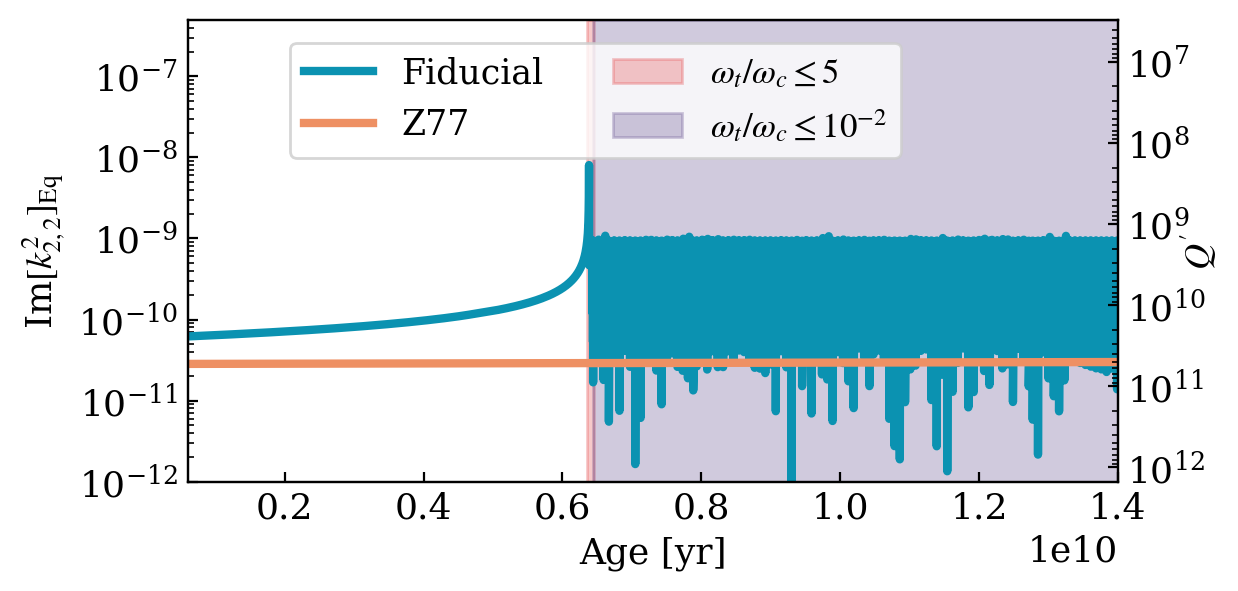

In [67]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

tidal_frequency_22 = np.abs(2*omega_orb - 2*omega_spin)
omega_c = 1/tau_conv

sync_idx = np.where(omega_spin >= omega_orb)[0][0]
tidal_freq_idx_5 = np.where((tidal_frequency_22/omega_c) <= 5)[0][0]
tidal_freq_idx_1e_2 = np.where((tidal_frequency_22/omega_c) <= 1e-2)[0][0]

ax.plot(Time, np.abs(Imk22_eq), lw=3, c=colorPalette['blue'], label=this_work)
ax.plot(Time_zahn, np.abs(Imk22_eq_zahn), lw=3, c=colorPalette['orange'], label=that_work)

ax.axvspan(Time.value[tidal_freq_idx_5-600], Time.value[tidal_freq_idx_1e_2+50], color=colorPalette['red'], alpha=0.3, label='$\\omega_{t} / \omega_c \leq 5$')
ax.axvspan(Time.value[tidal_freq_idx_1e_2], Time.value[-1], color=colorPalette['violet'], alpha=0.3, label='$\\omega_{t} / \omega_c \leq 10^{-2}$')


ax.set_yscale('log')
# ax.set_xscale('log')

ax.tick_params(axis='both', which='both', direction='in')
imk_min = 1e-12 # Low Mass 
imk_max = 5e-7 # Low Mass

ax.set_ylim(imk_min, imk_max)
ax.set_xlim(6e8, 1.4e10)
ax.set_ylabel("Im$[k_{2,2}^2 ]_{\\rm Eq}$")
ax.set_xlabel("Age [yr]")

ax2 = ax.twinx() 
ax2.set_ylim(3/(2*imk_min), 3/(2*imk_max))
ax2.set_yscale('log')
ax2.set_ylabel("$Q'$", labelpad=-10)
ax2.tick_params(axis='both', which='both', direction='in', bottom=False)


ax.legend(loc=(0.11, 0.7), ncols=2, fontsize=12.5)

plt.savefig(PlotDir+plot_prefix+'imk22_eq.pdf',dpi=300, bbox_inches='tight')

plt.show()

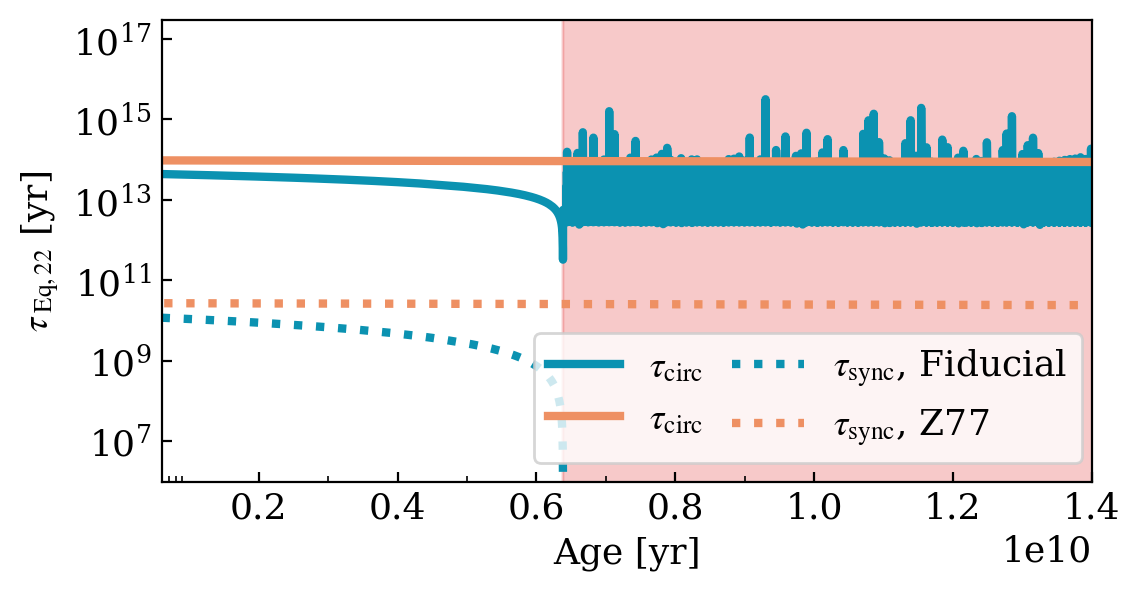

In [68]:
fig, (ax) = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

tidal_frequency_22 = np.abs(2*omega_orb - 2*omega_spin)
omega_c = 1/tau_conv

ax.fill_between(Time.value, 1e20, where=((tidal_frequency_22/omega_c <= 5)), color=colorPalette['red'], alpha=0.3)

ax.plot(Time, np.abs(1/tau_circ_inv_eq_22), c=colorPalette['blue'], lw=3, label="$\\tau_{\\rm circ}$")
ax.plot(Time_zahn, np.abs(1/tau_circ_inv_zahn_eq_22), c=colorPalette['orange'], lw=3, label="$\\tau_{\\rm circ} \;$")

ax.plot(Time, np.abs(1/tau_sync_inv_eq_22), c=colorPalette['blue'], lw=3, ls=':', label="$\\tau_{\\rm sync}$, "+this_work)
ax.plot(Time_zahn, np.abs(1/tau_sync_inv_zahn_eq_22), c=colorPalette['orange'], lw=3, ls=':', label="$\\tau_{\\rm sync}$, "+that_work)

ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.tick_params(axis='both', which='both', direction='in')

# ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(6e8, 1.4e10)
ax.set_ylim(1e6, 3e17)

ax.set_xlabel("Age [yr]") # Low Mass
ax.set_ylabel("$\\tau_{\\rm \; Eq, 22}$ [yr]")

ax.legend(loc=(0.4, 0.04), ncol=2, fancybox=True, columnspacing=.8) # Low Mass

plt.savefig(PlotDir+plot_prefix+'tau_circ_sync_eq.pdf',dpi=300, bbox_inches='tight')

plt.show()

### Compare tidal dissipation mechanisms

In [69]:
compare_tides(df_sanity, Imk22_dyn, Imk22_dyn, Imk22_dyn, Imk22_eq)

Convective core, NO radiative intershell, convective envelope:
Timesteps found: 57722
Stellar Types found: ['MS_LT_0.7']
Dynamical tides from convective core - radiative shell boundary: 0
Dynamical tides from radiative shell - convective envelope boundary: 0
*Dynamical tides from convective envelope IW dissipation: 0
*Equilibrium tides from convective envelope: 3.835484132788999e-06

Convective core, radiative intershell, convective envelope:
No timesteps found

Convective core, radiative envelope:
No timesteps found

Radiative core, convective envelope:
No timesteps found


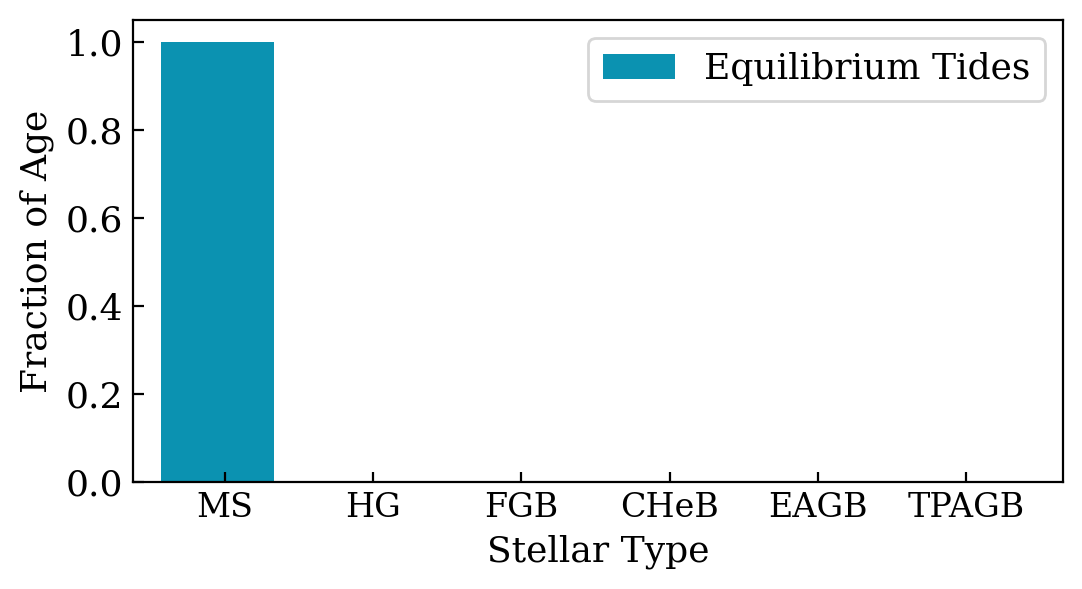

In [71]:
bins = np.linspace(-0.5, len(st_labels_plot)-0.5, len(st_labels_plot))

# Compute the fraction of the final time
total_time = df_sanity["Time"].values[-1] + df_sanity["Dt"].values[-1]

# Compute the sum of Dt for each stellar type
frac_dt_eq = df_sanity.loc[np.abs(df_sanity["ImK22_1_eq"]) > 0].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn = df_sanity.loc[np.abs(df_sanity["ImK22_1_dyn"]) > 0].groupby("StellarType_1")["Dt"].sum() / total_time

# Generally group together MS types to make labels smaller
frac_dt_eq.index = frac_dt_eq.index.where(frac_dt_eq.index != 0, 1)
frac_dt_dyn.index = frac_dt_dyn.index.where(frac_dt_dyn.index != 0, 1)

# Plot bar chart
fig, ax = plt.subplots(nrows=1, figsize=(6, 3))

ax.bar(frac_dt_eq.index, frac_dt_eq, alpha=1.0, color=colorPalette['blue'], label="Equilibrium Tides")
# ax.bar(frac_dt_eq.index, frac_dt_dyn, alpha=0.8, label="Dynamical Tides")

# Set x-axis labels to the stellar types
ax.set_xticks(bins+0.5, labels=st_labels_plot, rotation=0, fontsize=12)
ax.tick_params(axis='y', size=10)

ax.set_xlim(0.4, len(st_labels_plot)-13)
ax.set_ylabel("Fraction of Age")
ax.set_xlabel('Stellar Type')

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='y', length=4)


ax.legend()

plt.savefig(PlotDir+plot_prefix+'tides_type.pdf',dpi=300, bbox_inches='tight')
plt.show()

## Int Mass MS (Figure 5)

COMPAS --number-of-systems 1 --random-seed 1 --output-path sim_data --output-container int_mass --initial-mass-1 1.0 --initial-mass-2 1.0 --orbital-period 10.0 --eccentricity 0.5 --chemically-homogeneous-evolution-mode NONE --tides-prescription KAPIL2026 --maximum-number-timestep-iterations 250000 


COMPAS --number-of-systems 1 --random-seed 1 --output-path sim_data --output-container int_mass_z77 --initial-mass-1 1.0 --initial-mass-2 1.0 --orbital-period 10.0 --eccentricity 0.5 --chemically-homogeneous-evolution-mode NONE --tides-prescription ZAHN1977 --maximum-number-timestep-iterations 199999

In [58]:
plot_prefix = 'int_mass_'

In [59]:
DataPath = 'sim_data/int_mass'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())
pd.options.display.max_columns = None
df_sanity = df_sanity[df_sanity["SemiMajorAxis_after"]>0.0]
df_sanity = df_sanity[df_sanity["StellarType_1"]<=1]
df_sanity

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1,0.000000,0.000074,1,1,1.30168,1.30168,1.30168,1.30168,0.000000e+00,2.909640e-09,0.000000e+00,2.909640e-09,229.493,229.493,0.000000,0.001683,0.000000,0.001683,5.000000e-01,5.000000e-01,1.0,0.894082,0.000002,0.000002,1.0,0.894082,0.000002,0.000002,0.114450,0.114450,3.132960e-08,3.132960e-08,3.132960e-08,3.132960e-08,1.880520e-07,1.880520e-07,5.523170e-07,5.523170e-07,2.946980e-08,2.946980e-08,2.946980e-08,2.946980e-08,1.871220e-07,1.871220e-07,5.516970e-07,5.516970e-07,1.859770e-09,1.859770e-09,1.859770e-09,1.859770e-09,9.298830e-10,9.298830e-10,6.199220e-10,6.199220e-10,0.190789,0.0,0.190789,0.0,0.027006,0.027006,0.027006,0.027006,0.176528,0.176528,0.050056,0.050056,0.817982,0.817982,1.005770,1.005770,-1.245150e-11,-1.245150e-11,3.118270e-05,3.118270e-05,-3.603710e-11,-3.603710e-11,91.9165,138.746,0.073596,0.073596,0.0,0.0,0,0,3.211540e-09,3.211540e-09,3.211540e-09,3.211540e-09,6.423080e-09,6.423080e-09,9.634620e-09,9.634620e-09,6.987900e-15,6.987900e-15,6.987900e-15,6.987900e-15,4.437040e-14,4.437040e-14,1.308190e-13,1.308190e-13,-2.161970e-13,-2.161970e-13,-6.296670e-13,-6.296670e-13,5.322330e-07,5.322330e-07
1,1,0.000074,0.073597,1,1,1.30168,1.30168,1.30168,1.30167,2.909640e-09,2.912600e-06,2.909640e-09,2.912600e-06,229.493,229.499,0.001683,1.684740,0.001683,1.684740,5.000000e-01,4.999950e-01,1.0,0.894082,0.000002,0.000002,1.0,0.894082,0.000002,0.000002,0.114450,0.114448,3.132960e-08,3.132960e-08,3.132850e-08,3.132850e-08,1.880480e-07,1.880480e-07,5.523100e-07,5.523100e-07,2.946980e-08,2.946980e-08,2.946870e-08,2.946870e-08,1.871180e-07,1.871180e-07,5.516900e-07,5.516900e-07,1.859770e-09,1.859770e-09,1.859790e-09,1.859790e-09,9.298900e-10,9.298900e-10,6.199250e-10,6.199250e-10,0.190789,0.0,0.190789,0.0,0.027006,0.027006,0.027006,0.027006,0.176528,0.176528,0.050056,0.050056,0.817982,0.817982,1.005770,1.005770,-1.245140e-11,-1.245140e-11,3.118230e-05,3.118230e-05,-3.603670e-11,-3.603670e-11,91.9177,138.747,0.073597,0.073597,0.0,0.0,0,0,3.211590e-09,3.211590e-09,3.211540e-09,3.211540e-09,6.423130e-09,6.423130e-09,9.634710e-09,9.634710e-09,6.987900e-15,6.987900e-15,6.987630e-15,6.987630e-15,4.436960e-14,4.436960e-14,1.308170e-13,1.308170e-13,-2.161990e-13,-2.161990e-13,-6.296740e-13,-6.296740e-13,5.322380e-07,5.322380e-07
2,1,0.073671,0.074541,1,1,1.30168,1.30168,1.30167,1.30167,2.912600e-06,5.822000e-06,2.912600e-06,5.822000e-06,229.499,229.504,1.684730,3.367610,1.684730,3.367610,4.999950e-01,4.999890e-01,1.0,0.894084,0.000002,0.000002,1.0,0.894084,0.000002,0.000002,0.114448,0.114447,3.133210e-08,3.133210e-08,3.022000e-08,3.022000e-08,1.844340e-07,1.844340e-07,5.451970e-07,5.451970e-07,2.947

In [60]:
DataPath_Zahn = 'sim_data/int_mass_z77'

df_sanity_zahn = pd.read_csv(DataPath_Zahn+'/sanity_checks.csv')
df_sanity_zahn = df_sanity_zahn.rename(columns=lambda x: x.strip())
df_sanity_zahn = df_sanity_zahn[df_sanity_zahn["SemiMajorAxis_after"]>0.0]
df_sanity_zahn = df_sanity_zahn[df_sanity_zahn["StellarType_1"]<=1]
df_sanity_zahn

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1,0.000000,0.099936,1,1,1.30168,1.30168,1.30168,1.30168,0.000000e+00,9.195470e-08,0.000000e+00,9.195470e-08,229.493,229.493,0.000000,0.05319,0.000000,0.05319,0.500000,0.500000,1.0,0.894082,0.000002,0.000002,1.0,0.894082,0.000002,0.000002,0.114450,0.114450,3.132960e-08,3.132960e-08,3.132960e-08,3.132960e-08,1.880520e-07,1.880520e-07,5.523170e-07,5.523170e-07,2.946980e-08,2.946980e-08,2.946980e-08,2.946980e-08,1.871220e-07,1.871220e-07,5.516970e-07,5.516970e-07,1.859770e-09,1.859770e-09,1.859770e-09,1.859770e-09,9.298830e-10,9.298830e-10,6.199220e-10,6.199220e-10,0.190789,0.0,0.190789,0.0,0.027006,0.027006,0.027006,0.027006,0.176528,0.176528,0.050056,0.050056,0.817982,0.817982,1.005770,1.005770,-1.245150e-11,-1.245150e-11,0.000031,0.000031,-3.603710e-11,-3.603710e-11,91.916500,138.746000,0.073596,0.073596,0.0,0.0,0.0,0.0,3.211540e-09,3.211540e-09,3.211540e-09,3.211540e-09,6.423080e-09,6.423080e-09,9.634620e-09,9.634620e-09,6.987900e-15,6.987900e-15,6.987900e-15,6.987900e-15,4.437040e-14,4.437040e-14,1.308190e-13,1.308190e-13,-2.161970e-13,-2.161970e-13,-6.296670e-13,-6.296670e-13,5.322330e-07,5.322330e-07
1,1,0.099936,99.936400,1,1,1.30168,1.30168,1.30168,1.30167,9.195470e-08,4.059490e-06,9.195470e-08,4.059490e-06,229.493,229.499,0.053189,2.34812,0.053189,2.34812,0.500000,0.499994,1.0,0.894085,0.000002,0.000002,1.0,0.894085,0.000002,0.000002,0.114450,0.114448,3.133060e-08,3.133060e-08,3.129500e-08,3.129500e-08,1.879420e-07,1.879420e-07,5.521080e-07,5.521080e-07,2.947080e-08,2.947080e-08,2.943440e-08,2.943440e-08,1.870120e-07,1.870120e-07,5.514880e-07,5.514880e-07,1.859770e-09,1.859770e-09,1.860640e-09,1.860640e-09,9.301020e-10,9.301020e-10,6.200200e-10,6.200200e-10,0.190788,0.0,0.190788,0.0,0.027006,0.027006,0.027006,0.027006,0.176527,0.176527,0.050056,0.050056,0.817986,0.817986,1.005770,1.005770,-1.244710e-11,-1.244710e-11,0.000031,0.000031,-3.602440e-11,-3.602440e-11,91.949500,138.795000,0.073623,0.073623,0.0,0.0,0.0,0.0,3.213070e-09,3.213070e-09,3.211580e-09,3.211580e-09,6.424650e-09,6.424650e-09,9.637720e-09,9.637720e-09,6.987990e-15,6.987990e-15,6.979360e-15,6.979360e-15,4.434360e-14,4.434360e-14,1.307670e-13,1.307670e-13,-2.162700e-13,-2.162700e-13,-6.298880e-13,-6.298880e-13,5.324110e-07,5.324110e-07
2,1,100.036000,99.936400,1,1,1.30168,1.30168,1.30167,1.30167,4.059490e-06,8.049300e-06,4.059490e-06,8.049300e-06,229.499,229.505,2.335080,4.63007,2.335080,4.63007,0.499994,0.499989,1.0,0.896580,0.000002,0.000002,1.0,0.896580,0.000002,0.000002,0.114448,0.114446,3.226850e-08,3.226850e-08,3.068540e-08,3.068540e-08,1.887810e-07,1.887810e-07,5.595090e-07,5.595090e-07,3.040040e-08,3.040040e-08,2.8

In [61]:
rc = df_sanity["R1_core"].values * u.R_sun              # Rsol
R = df_sanity["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

rc2 = df_sanity["R2_core"].values * u.R_sun              # Rsol
R2 = df_sanity["R2"].values * u.R_sun                    # Rsol
Renv2 = df_sanity["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2 = R2 - Renv2

L = df_sanity["Lum_1"].values * u.L_sun                 # Lsol
L2 = df_sanity["Lum_2"].values * u.L_sun                 # Lsol

M = df_sanity["M1"].values * u.M_sun                    # Msol
Mc = df_sanity["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity["M2"].values * u.M_sun                   # Msol
Mc2 = df_sanity["M2_core"].values * u.M_sun              # Msol
Menv2 = df_sanity["M2_conv_env"].values * u.M_sun        # Msol


I1 = df_sanity["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity["tau_conv1"].values * u.yr                # yr
tau_conv2 = df_sanity["tau_conv2"].values * u.yr                # yr


omega_orb = df_sanity["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity["Omega1_before"].values / u.yr   # 1/yr
omega_spin2 = df_sanity["Omega2_before"].values / u.yr   # 1/yr

sma = df_sanity["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity["ecc_before"].values                           # 1
period_orb = 2 * np.pi / df_sanity["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk10 = df_sanity["ImK10_1"].values
Imk12 = df_sanity["ImK12_1"].values
Imk22 = df_sanity["ImK22_1"].values
Imk32 = df_sanity["ImK32_1"].values

Imk10_dyn = df_sanity["ImK10_1_dyn"].values
Imk12_dyn = df_sanity["ImK12_1_dyn"].values
Imk22_dyn = df_sanity["ImK22_1_dyn"].values
Imk32_dyn = df_sanity["ImK32_1_dyn"].values

Imk10_eq = df_sanity["ImK10_1_eq"].values
Imk12_eq = df_sanity["ImK12_1_eq"].values
Imk22_eq = df_sanity["ImK22_1_eq"].values
Imk32_eq = df_sanity["ImK32_1_eq"].values

Imk10_2 = df_sanity["ImK10_2"].values
Imk12_2 = df_sanity["ImK12_2"].values
Imk22_2 = df_sanity["ImK22_2"].values
Imk32_2 = df_sanity["ImK32_2"].values

Imk10_2_dyn = df_sanity["ImK10_2_dyn"].values
Imk12_2_dyn = df_sanity["ImK12_2_dyn"].values
Imk22_2_dyn = df_sanity["ImK22_2_dyn"].values
Imk32_2_dyn = df_sanity["ImK32_2_dyn"].values

Imk10_2_eq = df_sanity["ImK10_2_eq"].values
Imk12_2_eq = df_sanity["ImK12_2_eq"].values
Imk22_2_eq = df_sanity["ImK22_2_eq"].values
Imk32_2_eq = df_sanity["ImK32_2_eq"].values

dadt = df_sanity["dadt1"].values * u.AU / u.yr
dOmegadt = df_sanity["dOmegadt1"].values / u.yr**2
dedt1 = df_sanity["dedt1"].values / u.yr


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity["Time"].values  *1e6        # yr
st1 = df_sanity["StellarType_1"].values
st2 = df_sanity["StellarType_2"].values

rc_AU = df_sanity["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     


rc_AU2 = df_sanity["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2 = df_sanity["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2 = df_sanity["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2 = R_AU2 - Renv_AU2                 
Mint2 = M2 - Mc2 - Menv2   

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [62]:
rc_zahn = df_sanity_zahn["R1_core"].values * u.R_sun              # Rsol
R_zahn = df_sanity_zahn["R1"].values * u.R_sun                    # Rsol
Renv_zahn = df_sanity_zahn["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint_zahn = R_zahn - Renv_zahn

rc2_zahn = df_sanity_zahn["R2_core"].values * u.R_sun              # Rsol
R2_zahn = df_sanity_zahn["R2"].values * u.R_sun                    # Rsol
Renv2_zahn = df_sanity_zahn["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2_zahn = R2_zahn - Renv2_zahn

L_zahn = df_sanity_zahn["Lum_1"].values * u.L_sun                 # Lsol
L2_zahn = df_sanity_zahn["Lum_2"].values * u.L_sun                 # Lsol

M_zahn = df_sanity_zahn["M1"].values * u.M_sun                    # Msol
Mc_zahn = df_sanity_zahn["M1_core"].values * u.M_sun              # Msol
Menv_zahn = df_sanity_zahn["M1_conv_env"].values * u.M_sun        # Msol

M2_zahn = df_sanity_zahn["M2"].values * u.M_sun                   # Msol
Mc2_zahn = df_sanity_zahn["M2_core"].values * u.M_sun              # Msol
Menv2_zahn = df_sanity_zahn["M2_conv_env"].values * u.M_sun        # Msol


I1_zahn = df_sanity_zahn["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv_zahn = df_sanity_zahn["tau_conv1"].values * u.yr                # yr
tau_conv2_zahn = df_sanity_zahn["tau_conv2"].values * u.yr                # yr


omega_orb_zahn = df_sanity_zahn["Omega_before"].values / u.yr     # 1/yr
omega_spin_zahn = df_sanity_zahn["Omega1_before"].values / u.yr   # 1/yr
omega_spin2_zahn = df_sanity_zahn["Omega2_before"].values / u.yr   # 1/yr

sma_zahn = df_sanity_zahn["SemiMajorAxis_before"].values * u.AU   # AU
ecc_zahn = df_sanity_zahn["ecc_before"].values                           # 1
period_orb_zahn = 2 * np.pi / df_sanity_zahn["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk22_dyn_zahn = df_sanity_zahn["ImK22_Zahn_Dynamical1"].values
Imk22_eq_zahn = df_sanity_zahn["ImK22_Zahn_Equilibrium1"].values
Imk22_zahn = Imk22_dyn_zahn + Imk22_eq_zahn

Imk22_2_dyn_zahn = df_sanity_zahn["ImK22_Zahn_Dynamical2"].values
Imk22_2_eq_zahn = df_sanity_zahn["ImK22_Zahn_Equilibrium2"].values
Imk22_2_zahn = Imk22_2_dyn_zahn + Imk22_2_eq_zahn


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time_zahn = df_sanity_zahn["Time"].values  * 1e6        # yr
st1_zahn = df_sanity_zahn["StellarType_1"].values
st2_zahn = df_sanity_zahn["StellarType_2"].values

rc_AU_zahn = df_sanity_zahn["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU_zahn = df_sanity_zahn["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU_zahn = df_sanity_zahn["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU_zahn = R_AU_zahn - Renv_AU_zahn
Mint_zahn = M_zahn - Mc_zahn - Menv_zahn


rc_AU2_zahn = df_sanity_zahn["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2_zahn = df_sanity_zahn["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2_zahn = df_sanity_zahn["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2_zahn = R_AU2_zahn - Renv_AU2_zahn
Mint2_zahn = M2_zahn - Mc2_zahn - Menv2_zahn

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

### Stellar Evolution

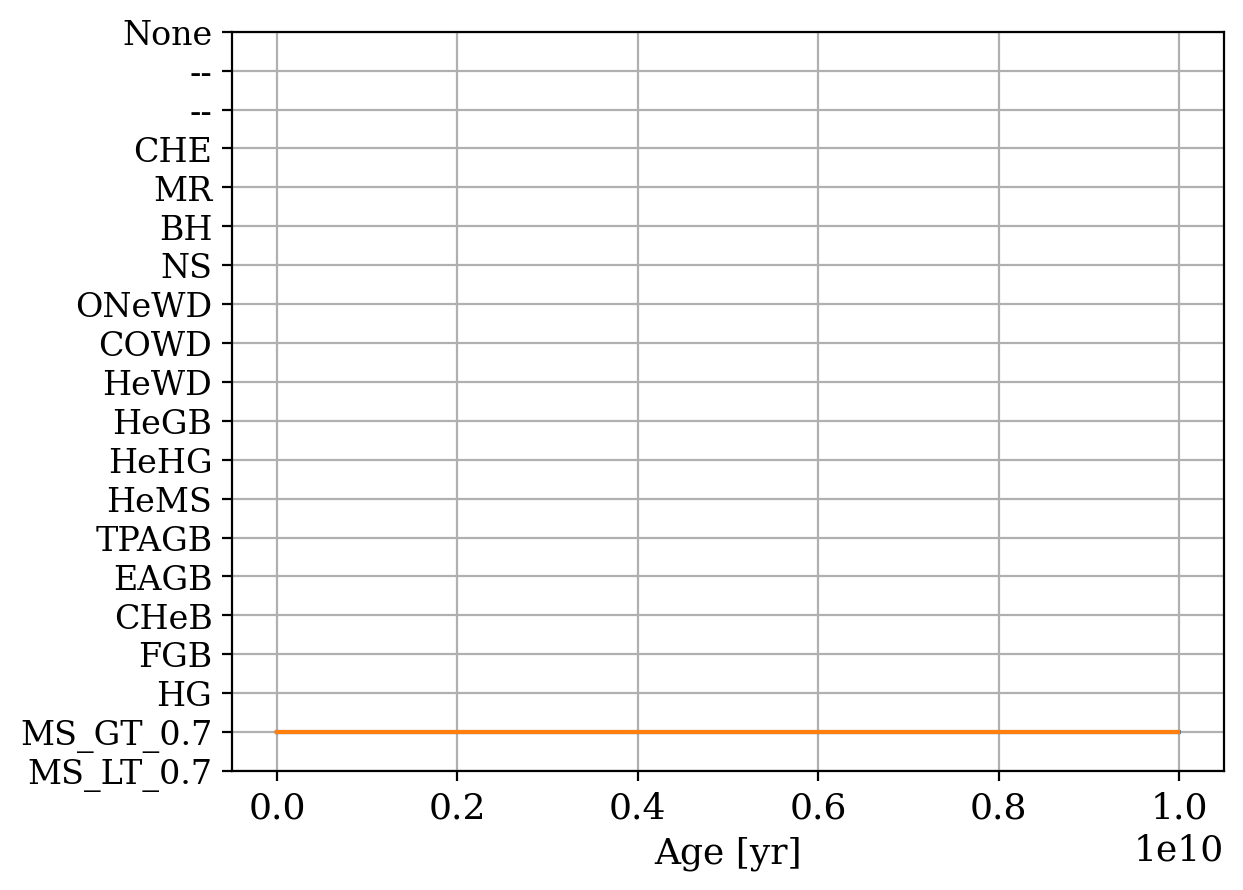

In [79]:
plt.plot(Time, st1)
plt.plot(Time_zahn, st1_zahn)
y_ticks=np.linspace(0, 19, 20)
plt.yticks(y_ticks, st_labels, fontsize=12)

plt.xlabel("Age [yr]")
plt.grid()
plt.show()

### Stellar Structure

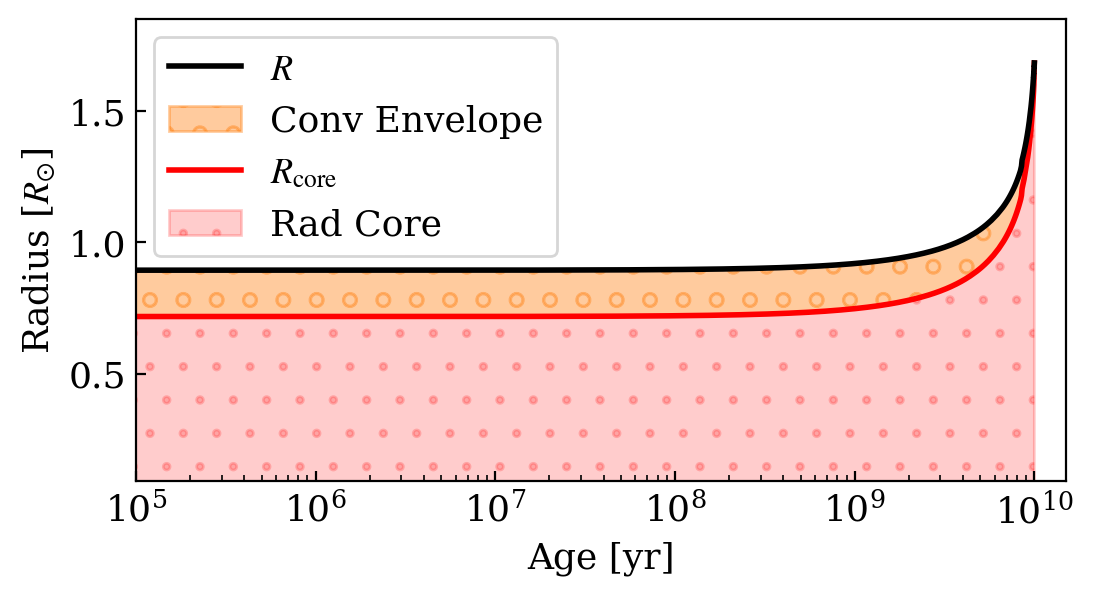

In [84]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

plt.plot(Time, R, c='k', zorder=10, lw=2, label="$R$")

if any(Renv/R > frac_limit):
    plt.fill_between(Time, R.value, (R-Renv).value, color='C1', alpha=0.4, hatch="o", label="Conv Envelope")
elif any((R-rc)/R > frac_limit):
    plt.fill_between(Time, rc.value, R.value, color='r', alpha=0.4, hatch="o", label="Rad Envelope")

if any((R-Renv)/R > frac_limit):
    plt.plot(Time, (R-Renv).value, lw=2, c='r', label='$R_{\\rm core}$') 
    plt.fill_between(Time, 0, (R-Renv).value, color='r', alpha=0.2, hatch=".", label="Rad Core")

plt.plot(Time, np.zeros(len(Time)), lw=2, c='k')

plt.ylabel("Radius [$R_{\odot}$]")
plt.xlabel("Age [yr]")

ax.tick_params(axis='both', which='both', direction='in')


plt.semilogx()

plt.ylim(9e-2, 1.85)
ax.set_xlim(1e5, 15e9)
plt.legend(loc='upper left')

plt.savefig(PlotDir+plot_prefix+'stellar_structure.png',dpi=300, bbox_inches='tight')
plt.show()

### Orbital Properties

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


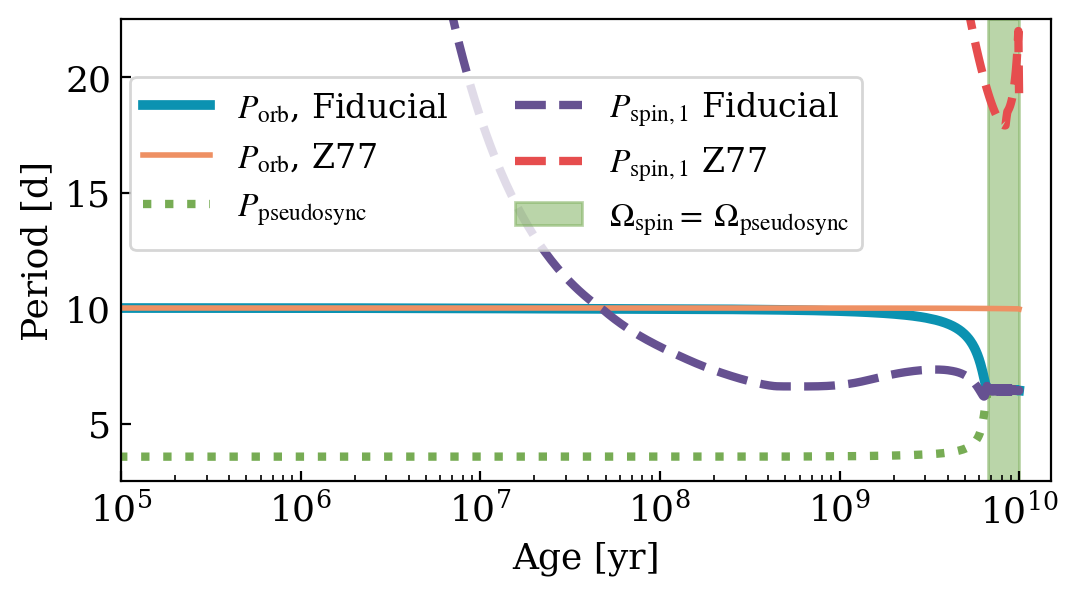

In [85]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))


period_spin = 2 * np.pi / omega_spin.to(1/u.day)     # days
period_spin_zahn = 2 * np.pi / omega_spin_zahn.to(1/u.day)     # days

omega_pseudosync = (1 + (15/2)*ecc**2 + (45/8)*ecc**4 + (5/16)*ecc**6)/ ((1 + 3*ecc**2 + (3/8)*ecc**4)*(1-ecc**2)**(3/2)) * omega_orb
period_pseudosync = 2 * np.pi / omega_pseudosync.to(1/u.day)     # days

tidal_frequency_22 = np.abs(2*omega_orb - 2*omega_spin)

omega_c = 1/tau_conv

viscous_freq_idx_start, viscous_freq_idx_end = np.where(tidal_frequency_22/omega_c <= 5)[0][0], np.where(tidal_frequency_22/omega_c <= 5)[0][-1]
sync_idx = np.where(omega_spin >= omega_orb)[0][0]
sync_32_idx = np.where(2*omega_spin >= 3*omega_orb)[0][0]

omega_pseudosync = (1 + (15/2)*ecc**2 + (45/8)*ecc**4 + (5/16)*ecc**6)/ ((1 + 3*ecc**2 + (3/8)*ecc**4)*(1-ecc**2)**(3/2)) * omega_orb
pseudosync_idx = np.where(omega_spin >= omega_pseudosync)[0][0]


plt.plot(Time, period_orb, lw=3.5, c=colorPalette['blue'], label='$P_{\\rm orb}$, '+this_work)
plt.plot(Time_zahn, period_orb_zahn, lw=2, c=colorPalette['orange'], label='$P_{\\rm orb}$, '+that_work)
plt.plot(Time, period_pseudosync, lw=3, c=colorPalette['green'], ls=':', label="$P_{\\rm pseudosync}$")


plt.plot(Time, period_spin, lw=3, c=colorPalette['violet'], ls='--', label="$P_{\\rm spin, 1}$ "+this_work)
plt.plot(Time_zahn, period_spin_zahn, lw=3, c=colorPalette['red'], ls='--', label="$P_{\\rm spin, 1}$ "+that_work)
ax.axvspan(Time[pseudosync_idx], Time[-1], color=colorPalette['green'], alpha=0.5, label='$\Omega_{\\rm spin} = \; \Omega_{\\rm pseudosync}$')


ax.tick_params(axis='both', which='both', direction='in')


plt.ylabel("Period [d]")
plt.xlabel("Age [yr]")
plt.ylim(2.5, 22.5)


ax.set_xlim(1e5, 15e9)
plt.semilogx()
# plt.loglog()

plt.legend(loc=(0.01, 0.5), fontsize=12, ncols=2)
plt.savefig(PlotDir+plot_prefix+'period_evolution.pdf',dpi=300, bbox_inches='tight')

plt.show()

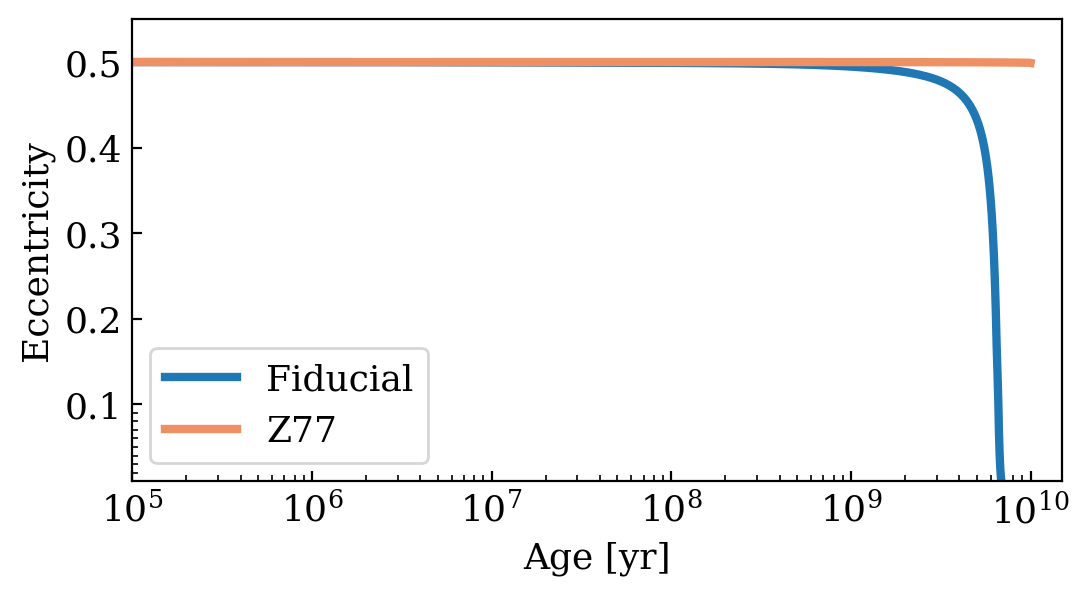

In [86]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

plt.plot(Time, ecc, c='C0', lw=3, label=this_work)
plt.plot(Time_zahn, ecc_zahn, c=colorPalette['orange'], lw=3, label=that_work)

ax.tick_params(axis='both', which='both', direction='in')

ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))

plt.ylabel("Eccentricity")
plt.xlabel("Age [yr]")
ax.set_xlim(1e5, 15e9)
ax.set_ylim(0.01, 0.55)
plt.legend()
plt.semilogx()
plt.savefig(PlotDir+plot_prefix+'ecc_evolution.pdf',dpi=300, bbox_inches='tight')

plt.show()

In [87]:
# final sma
df_sanity['ecc'].iloc[-1]
print("Initial sma (this work):", df_sanity['SemiMajorAxis_before'].iloc[0], "AU")
print("Expected final sma from angular momentum conservation:", df_sanity['SemiMajorAxis_before'].iloc[0] * (1 - df_sanity['ecc'].iloc[0]**2) / (1 - df_sanity['ecc'].iloc[-1]**2), "AU")
print("Final sma (this work):", df_sanity['SemiMajorAxis_after'].iloc[-1], "AU")



Initial sma (this work): 0.11445 AU
Expected final sma from angular momentum conservation: 0.0858375 AU
Final sma (this work): 0.0852615 AU


### Equilibrium Tides

#### Fiducial

In [88]:
dedt1_eq = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*Imk10_eq/2) - (Imk12_eq/4) - Imk22_eq + (49*Imk32_eq/4))
tau_circ_inv_eq = - dedt1_eq / ecc
1/tau_circ_inv_eq

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [1.02137735e+13, 1.02137453e+13, 1.01860313e+13, ...,
                      inf,            inf,            inf] yr>

In [89]:
dedt1_eq_22 = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- Imk22_eq)
tau_circ_inv_eq_22 = - dedt1_eq_22 / ecc
1/tau_circ_inv_eq_22

<Quantity [-9.87331983e+13, -9.87324551e+13, -9.79982297e+13, ...,
                      -inf,            -inf,            -inf] yr>

In [90]:
dOmegadt1_eq = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_eq + ecc**2 * ((Imk12_eq/4) - (5*Imk22_eq) + (49*Imk32_eq/4)))
tau_sync_inv_eq = - dOmegadt1_eq / (omega_spin - omega_orb)
1/tau_sync_inv_eq

<Quantity [6.79879939e+09, 6.79871639e+09, 6.71330800e+09, ...,
           5.47830918e+10, 7.85039939e+10,            inf] yr>

In [91]:
dOmegadt1_eq_22 = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_eq)
tau_sync_inv_eq_22 = - dOmegadt1_eq_22 / (omega_spin - omega_orb)
1/tau_sync_inv_eq_22

<Quantity [1.30310340e+10, 1.30308403e+10, 1.28396067e+10, ...,
           5.47830918e+10, 7.85039939e+10,            inf] yr>

#### Zahn 1977

In [92]:
# From Simulations
dedt1_eq_22 = -(3/4) * (ecc_zahn/omega_orb_zahn) * ((M_zahn + M2_zahn)/M_zahn) * (G_AU_Msol_yr*M2_zahn / R_AU_zahn**3) * (R_AU_zahn/sma_zahn)**8 * (- Imk22_eq_zahn)
tau_circ_inv_zahn_eq_22 = - dedt1_eq_22 / ecc_zahn
1/tau_circ_inv_zahn_eq_22

<Quantity [-1.42938158e+13, -1.42900831e+13, -1.37740296e+13,
           -1.32744710e+13, -1.27916344e+13, -1.23232993e+13,
           -1.18698258e+13, -1.14308364e+13, -1.10057580e+13,
           -1.05943223e+13, -1.01959835e+13, -9.81041990e+12,
           -9.43718820e+12, -9.07598049e+12, -8.72639081e+12,
           -8.38813705e+12, -8.06083836e+12, -7.74418763e+12,
           -7.43793049e+12, -7.14172074e+12, -6.85531134e+12,
           -6.57836036e+12, -6.31066387e+12, -6.05199794e+12,
           -5.80165509e+12, -5.56021695e+12, -5.32703436e+12,
           -5.10185782e+12, -4.88450541e+12, -4.67475125e+12,
           -4.47206134e+12, -4.27691419e+12, -4.08870673e+12,
           -3.90730922e+12, -3.73223552e+12, -3.56385948e+12,
           -3.40169034e+12, -3.24559208e+12, -3.09513917e+12,
           -2.95066956e+12, -2.81168449e+12, -2.67793255e+12,
           -2.54950625e+12, -2.42605996e+12, -2.30765628e+12,
           -2.19412070e+12, -2.08495449e+12, -1.98043578e+12,
        

In [93]:
dOmegadt1_eq_22 = (3/2) * (1/I1_zahn) * (G_AU_Msol_yr*M2_zahn*M2_zahn / R_AU_zahn) * (R_AU_zahn/sma_zahn)**6 * (Imk22_eq_zahn)
tau_sync_inv_zahn_eq_22 = - dOmegadt1_eq_22 / (omega_spin_zahn - omega_orb_zahn)
1/tau_sync_inv_zahn_eq_22

<Quantity [1.88653060e+09, 1.88561173e+09, 1.80955944e+09, 1.73622379e+09,
           1.66557992e+09, 1.59738319e+09, 1.53161802e+09, 1.46822971e+09,
           1.40711320e+09, 1.34822730e+09, 1.29147209e+09, 1.23679864e+09,
           1.18411572e+09, 1.13338268e+09, 1.08452101e+09, 1.03748640e+09,
           9.92199786e+08, 9.48614846e+08, 9.06684184e+08, 8.66347262e+08,
           8.27553637e+08, 7.90251777e+08, 7.54394465e+08, 7.19941736e+08,
           6.86801999e+08, 6.55010585e+08, 6.24486492e+08, 5.95185000e+08,
           5.67066763e+08, 5.40097465e+08, 5.14204978e+08, 4.89415146e+08,
           4.65654712e+08, 4.42895177e+08, 4.21076249e+08, 4.00212581e+08,
           3.80246657e+08, 3.61146460e+08, 3.42864576e+08, 3.25410632e+08,
           3.08728192e+08, 2.92784083e+08, 2.77565365e+08, 2.63036741e+08,
           2.49185550e+08, 2.35988102e+08, 2.23386243e+08, 2.11392950e+08,
           1.99965154e+08, 1.89081987e+08, 1.78725565e+08, 1.68874873e+08,
           1.59513779e+08

#### Plots

In [94]:
Imk22_eq[0] = Imk22_eq[1]
Imk22_eq_zahn[0] = Imk22_eq_zahn[1]

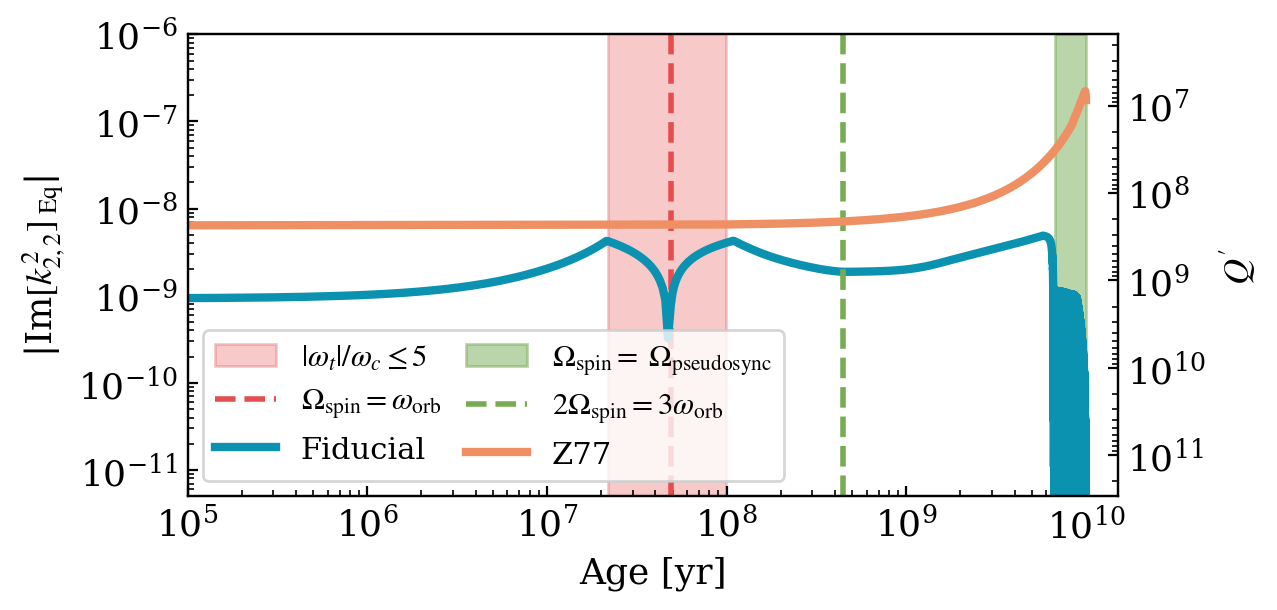

In [95]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

viscous_freq_idx_start, viscous_freq_idx_end = np.where(tidal_frequency_22/omega_c <= 5)[0][0], np.where(tidal_frequency_22/omega_c <= 5)[0][-1]
sync_idx = np.where(omega_spin >= omega_orb)[0][0]
sync_32_idx = np.where(2*omega_spin >= 3*omega_orb)[0][0]

omega_pseudosync = (1 + (15/2)*ecc**2 + (45/8)*ecc**4 + (5/16)*ecc**6)/ ((1 + 3*ecc**2 + (3/8)*ecc**4)*(1-ecc**2)**(3/2)) * omega_orb
pseudosync_idx = np.where(omega_spin >= omega_pseudosync)[0][0]

ax.fill_between(Time, 1e-1, where=((np.abs(tidal_frequency_22)/omega_c <= 5) & (Time < 1e8)), color=colorPalette['red'], alpha=0.3, label='$|\\omega_{t}| / \omega_c \leq 5$')

ax.axvline(Time[sync_idx], color=colorPalette['red'], ls='--', lw=2, alpha=1, label='$\Omega_{\\rm spin} = \omega_{\\rm orb}$')

ax.plot(Time, np.abs(Imk22_eq), c=colorPalette['blue'], lw=3, label=this_work)

ax.axvspan(Time[pseudosync_idx], Time[-1], color=colorPalette['green'], alpha=0.5, label='$\Omega_{\\rm spin} = \; \Omega_{\\rm pseudosync}$')

ax.axvline(Time[sync_32_idx], color=colorPalette['green'], ls='--', lw=2, alpha=1, label='$2\Omega_{\\rm spin} = 3\omega_{\\rm orb}$')

ax.plot(Time_zahn, np.abs(Imk22_eq_zahn), c=colorPalette['orange'], lw=3, label=that_work)


imk_min = 5e-12
imk_max = 1e-6

ax.set_ylim(imk_min, imk_max)
ax.set_xlim(1e5, 15e9)

ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', direction='in')

ax.set_ylabel("|Im$[k_{2,2}^2]_{\\rm \; Eq}$|")
ax.set_xlabel("Age [yr]")

ax2 = ax.twinx() 
ax2.set_ylim(3/(2*imk_min), 3/(2*imk_max))
ax2.set_yscale('log')
ax2.set_ylabel("$Q'$")
ax2.tick_params(axis='both', which='both', direction='in', bottom=False)

ax.legend(loc='lower left', columnspacing=0.8, fontsize=11, ncol=2)

plt.savefig(PlotDir+plot_prefix+'imk22_eq.pdf',dpi=300, bbox_inches='tight')

plt.show()

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


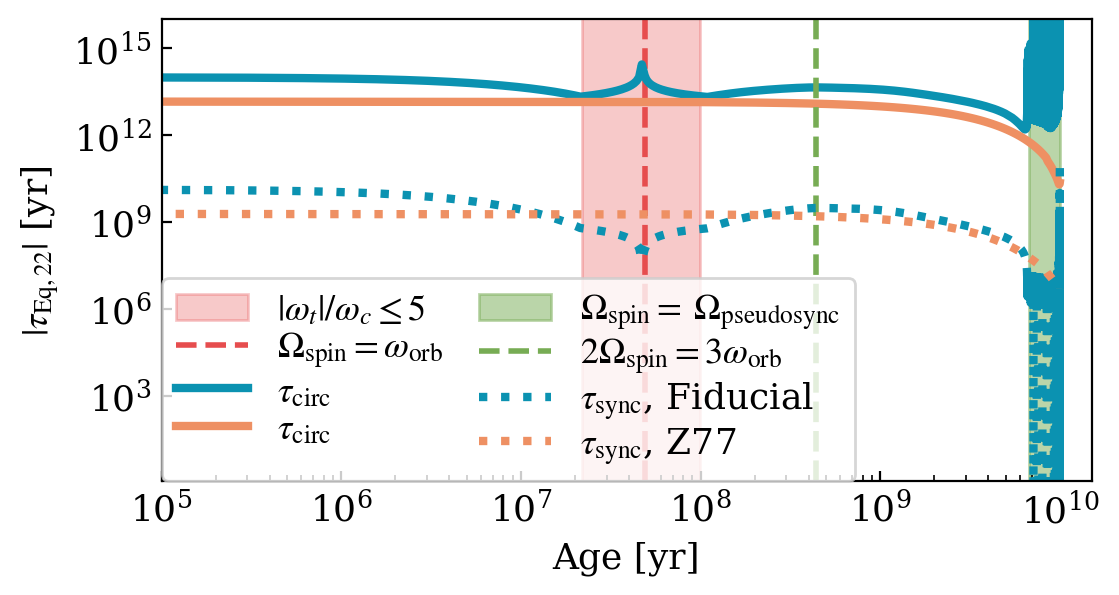

In [97]:
fig, (ax) = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

viscous_freq_idx_start, viscous_freq_idx_end = np.where(tidal_frequency_22/omega_c <= 5)[0][0], np.where(tidal_frequency_22/omega_c <= 5)[0][-1]
sync_idx = np.where(omega_spin >= omega_orb)[0][0]
sync_32_idx = np.where(2*omega_spin >= 3*omega_orb)[0][0]

omega_pseudosync = (1 + (15/2)*ecc**2 + (45/8)*ecc**4 + (5/16)*ecc**6)/ ((1 + 3*ecc**2 + (3/8)*ecc**4)*(1-ecc**2)**(3/2)) * omega_orb
pseudosync_idx = np.where(omega_spin >= omega_pseudosync)[0][0]

ax.fill_between(Time, 1e20, where=((tidal_frequency_22/omega_c <= 5) & (Time < 1e8)), color=colorPalette['red'], alpha=0.3, label='$|\\omega_{t}| / \omega_c \leq 5$')
ax.axvline(Time[sync_idx], color=colorPalette['red'], ls='--', lw=2, alpha=1, label='$\Omega_{\\rm spin} = \omega_{\\rm orb}$')

ax.plot(Time, np.abs(1/tau_circ_inv_eq_22), c=colorPalette['blue'], lw=3, label="$\\tau_{\\rm circ}$")
ax.plot(Time_zahn, np.abs(1/tau_circ_inv_zahn_eq_22), c=colorPalette['orange'], lw=3, label="$\\tau_{\\rm circ} \;$")

ax.axvspan(Time[pseudosync_idx], Time[-1], color=colorPalette['green'], alpha=0.5, label='$\Omega_{\\rm spin} = \; \Omega_{\\rm pseudosync}$')
ax.axvline(Time[sync_32_idx], color=colorPalette['green'], ls='--', lw=2, alpha=1, label='$2\Omega_{\\rm spin} = 3\omega_{\\rm orb}$')

ax.plot(Time, np.abs(1/tau_sync_inv_eq_22), c=colorPalette['blue'], lw=3, ls=':', label="$\\tau_{\\rm sync}$, "+this_work)
ax.plot(Time_zahn, np.abs(1/tau_sync_inv_zahn_eq_22), c=colorPalette['orange'], lw=3, ls=':', label="$\\tau_{\\rm sync}$, "+that_work)

ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.tick_params(axis='both', which='both', direction='in')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e5, 15e9)
ax.set_ylim(1.1e0, 1e16)


ax.legend(loc=(0,0.0), ncol=2, columnspacing=1, labelspacing=0.1) # Int Mass

ax.set_ylabel("$|\\tau_{\\rm Eq, 22}|$ [yr]")
ax.set_xlabel("Age [yr]")

plt.savefig(PlotDir+plot_prefix+'tau_circ_sync_eq.pdf', dpi=300, bbox_inches='tight')

plt.show()

### Dynamical Tide with Radiative Damping

#### Fiducial

In [63]:
# Total Dynamical Tide
dedt1_dyn = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*Imk10_dyn/2) - (Imk12_dyn/4) - Imk22_dyn + (49*Imk32_dyn/4))
tau_circ_inv_dyn = - dedt1_dyn / ecc
1/tau_circ_inv_dyn

<Quantity [1.38938066e+10, 1.38939779e+10, 1.40695243e+10, ...,
           2.36128293e+02, 1.82513720e+02, 1.16394062e+02] yr>

In [64]:
# (2,2) Dynamical Tide
dedt1_dyn_22 = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- Imk22_dyn)
tau_circ_inv_dyn_22 = - dedt1_dyn_22 / ecc
1/tau_circ_inv_dyn_22

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [-4.90644193e+11, -4.90654681e+11, -5.00274455e+11, ...,
                      -inf,            -inf,            -inf] yr>

In [65]:
dOmegadt1_dyn = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_dyn + ecc**2 * ((Imk12_dyn/4) - (5*Imk22_dyn) + (49*Imk32_dyn/4)))
tau_sync_inv_dyn = - dOmegadt1_dyn / (omega_spin - omega_orb)
1/tau_sync_inv_dyn

<Quantity [7367804.15352496, 7367841.98690666, 7407725.70252912, ...,
           7037210.882633  , 5551197.63217318, 3590214.70651482] yr>

In [66]:
dOmegadt1_dyn_22 = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_dyn)
tau_sync_inv_dyn_22 = - dOmegadt1_dyn_22 / (omega_spin - omega_orb)
1/tau_sync_inv_dyn_22

<Quantity [64756346.01885924, 64757255.39485969, 65545339.48100676, ...,
            7037210.882633  ,  5551197.63217318,  3590214.70651482] yr>

##### Core only, IGWs

In [67]:
E2_kushnir = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.)

In [68]:
l=1
m=0
imk10_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk10_core_gw[np.isnan(imk10_core_gw)] = 0.0

l=1
m=2
imk12_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk12_core_gw[np.isnan(imk12_core_gw)] = 0.0

l=2
m=2
imk22_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk22_core_gw[(rc_AU/R_AU < frac_limit) | (Mc/M < frac_limit)] = 0.0
imk22_core_gw[np.isnan(imk22_core_gw)] = 0.0

l=3
m=2
imk32_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk32_core_gw[np.isnan(imk32_core_gw)] = 0.0

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [69]:
dedt1_dyn_core_gw = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*imk10_core_gw/2) - (imk12_core_gw/4) - imk22_core_gw + (49*imk32_core_gw/4))
tau_circ_inv_dyn_core_gw = - dedt1_dyn_core_gw / ecc
tau_circ_inv_dyn_core_gw

<Quantity [0., 0., 0., ..., 0., 0., 0.] 1 / yr>

In [70]:
dOmegadt1_dyn_core_gw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_core_gw + ecc**2 * ((imk12_core_gw/4) - (5*imk22_core_gw) + (49*imk32_core_gw/4)))
tau_sync_inv_dyn_core_gw = - dOmegadt1_dyn_core_gw / (omega_spin - omega_orb)
tau_sync_inv_dyn_core_gw

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [0., 0., 0., ..., 0., 0., 0.] 1 / yr>

##### Envelope only, IGWs

In [81]:
dNlnr_cbrt = (G_AU_Msol_yr * Mint / (Rint_AU**2 * (R_AU - Rint_AU/2)))**(1/3)

alpha = Rint_AU/R_AU
beta = Mint/M

one_minus_beta = Menv/M

rho_conv = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3))
rho_rad = Mint / (4 * np.pi * (Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

Epsilon = alpha**11 * (one_minus_beta) * (1-gamma)**2 * (2*alpha/3 - 1)**2 / (beta**2 * (1-alpha**3) * (1-alpha)**2)

n=2

l=1
m=0
imk10_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (n*(n+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk10_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk10_env_gw)
imk10_env_gw[np.isnan(imk10_env_gw)] = 0.0

l=1
m=2
imk12_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (n*(n+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk12_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk12_env_gw)
imk12_env_gw[np.isnan(imk12_env_gw)] = 0.0

l=2
m=2
imk22_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (n*(n+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk22_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk22_env_gw)
imk22_env_gw[(Renv_AU/R_AU < frac_limit) | (Menv/M < frac_limit)] = 0.0
imk22_env_gw[np.isnan(imk22_env_gw)] = 0.0


l=3
m=2
imk32_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * m * (n*(n+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk32_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk32_env_gw)
imk32_env_gw[np.isnan(imk32_env_gw)] = 0.0

In [82]:
dedt1_dyn_env_gw = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*imk10_env_gw/2) - (imk12_env_gw/4) - imk22_env_gw + (49*imk32_env_gw/4))
tau_circ_inv_dyn_env_gw = - dedt1_dyn_env_gw / ecc
tau_circ_inv_dyn_env_gw

<Quantity [2.10733097e-10, 2.10730381e-10, 2.08069083e-10, ...,
           7.94791942e-02, 1.08250095e-01, 1.85696282e-01] 1 / yr>

In [83]:
dOmegadt1_dyn_env_gw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_env_gw + ecc**2 * ((imk12_env_gw/4) - (5*imk22_env_gw) + (49*imk32_env_gw/4)))
tau_sync_inv_dyn_env_gw = - dOmegadt1_dyn_env_gw / (omega_spin - omega_orb)
tau_sync_inv_dyn_env_gw

<Quantity [3.98289175e-07, 3.98286933e-07, 3.96110173e-07, ...,
           1.56900508e-06, 2.13697375e-06, 0.00000000e+00] 1 / yr>

##### Envelope only, IWs

In [84]:
alpha = Rint_AU/R_AU
beta = Mint/M
one_minus_beta = Menv/M

rho_conv = Menv / ((R_AU**3 - Rint_AU**3))
rho_rad = Mint / ((Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

eps = omega_spin / np.sqrt(G_AU_Msol_yr * M / R_AU**3)

b1 = (1 + 2*alpha + 3*alpha**2 + (3/2)*alpha**3)
b2 = 1 + ((1-gamma) / gamma) * alpha**3
b3 = 1 + (3*gamma/2) + ((5*alpha**3)/(2*gamma))*(1 + gamma/2 - (3*gamma**2)/2) - (9/4)*(1-gamma)*alpha**5
imk22_inertial = (100 * np.pi / 63) * eps**2 * (alpha**5 / (1 - alpha**5)) * (1-gamma)**2 * (1-alpha)**4 * b1**2 * b2 * b3**(-2)

imk22_inertial[((Renv_AU/R_AU < frac_limit) & (Menv/M < frac_limit)) | (omega_orb > 2*omega_spin)] = 0.0
imk22_inertial[np.isnan(imk22_inertial)] = 0.0
imk22_inertial = np.sign(omega_orb - omega_spin) * np.abs(imk22_inertial)

In [85]:
dedt1_dyn_env_iw_22 = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- imk22_inertial)
tau_circ_inv_dyn_env_iw_22 = - dedt1_dyn_env_iw_22 / ecc
tau_circ_inv_dyn_env_iw_22

<Quantity [-0., -0., -0., ..., -0., -0., -0.] 1 / yr>

In [86]:
dOmegadt1_dyn_env_iw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_inertial + ecc**2 * (-5*imk22_inertial))
tau_sync_inv_dyn_env_iw_22 = - dOmegadt1_dyn_env_iw / (omega_spin - omega_orb)
tau_sync_inv_dyn_env_iw_22

<Quantity [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
           5.59987449e-09, 3.52624262e-09, 1.57151277e-09] 1 / yr>

#### Zahn 1977

In [87]:
dedt1_dyn_22 = -(3/4) * (ecc_zahn/omega_orb_zahn) * ((M_zahn + M2_zahn)/M_zahn) * (G_AU_Msol_yr*M2_zahn / R_AU_zahn**3) * (R_AU_zahn/sma_zahn)**8 * (- Imk22_dyn_zahn)
tau_circ_inv_zahn_dyn_22 = - dedt1_dyn_22 / ecc_zahn
1/tau_circ_inv_zahn_dyn_22

<Quantity [-2.07043007e+18, -2.07039533e+18, -2.07329051e+18,
           -2.07642185e+18, -2.07990210e+18, -2.08344169e+18,
           -2.08716412e+18, -2.09106290e+18, -2.09510399e+18,
           -2.09929270e+18, -2.10359928e+18, -2.10801491e+18,
           -2.11250697e+18, -2.11707642e+18, -2.12168945e+18,
           -2.12633412e+18, -2.13098678e+18, -2.13562256e+18,
           -2.14023957e+18, -2.14479129e+18, -2.14927353e+18,
           -2.15364910e+18, -2.15789714e+18, -2.16201947e+18,
           -2.16579847e+18, -2.16952790e+18, -2.17303258e+18,
           -2.17629249e+18, -2.17926101e+18, -2.18191490e+18,
           -2.18407358e+18, -2.18601963e+18, -2.18755941e+18,
           -2.18865659e+18, -2.18914718e+18, -2.18927184e+18,
           -2.18886062e+18, -2.18787906e+18, -2.18613904e+18,
           -2.18393086e+18, -2.18100032e+18, -2.17722295e+18,
           -2.17276115e+18, -2.16742173e+18, -2.16135765e+18,
           -2.15450738e+18, -2.14649518e+18, -2.13769575e+18,
        

In [88]:
dOmegadt1_dyn_22 = (3/2) * (1/I1_zahn) * (G_AU_Msol_yr*M2_zahn*M2_zahn / R_AU_zahn) * (R_AU_zahn/sma_zahn)**6 * (Imk22_dyn_zahn )
tau_sync_inv_zahn_dyn_22 = - dOmegadt1_dyn_22 / (omega_spin_zahn - omega_orb_zahn)
tau_sync_inv_zahn_dyn_22

<Quantity [3.65951694e-15, 3.66040554e-15, 3.67136870e-15, 3.68210300e-15,
           3.69247589e-15, 3.70285355e-15, 3.71310538e-15, 3.72320462e-15,
           3.73323508e-15, 3.74314860e-15, 3.75302178e-15, 3.76283278e-15,
           3.77268303e-15, 3.78251315e-15, 3.79240639e-15, 3.80234568e-15,
           3.81241639e-15, 3.82262283e-15, 3.83295470e-15, 3.84349057e-15,
           3.85424522e-15, 3.86524685e-15, 3.87655380e-15, 3.88813933e-15,
           3.90033862e-15, 3.91271467e-15, 3.92551112e-15, 3.93875629e-15,
           3.95254801e-15, 3.96687540e-15, 3.98202708e-15, 3.99759759e-15,
           4.01385890e-15, 4.03087385e-15, 4.04886535e-15, 4.06752419e-15,
           4.08706235e-15, 4.10759163e-15, 4.12933183e-15, 4.15192934e-15,
           4.17575074e-15, 4.20096699e-15, 4.22745332e-15, 4.25541275e-15,
           4.28471195e-15, 4.31541356e-15, 4.34820726e-15, 4.38252470e-15,
           4.41886217e-15, 4.45731391e-15, 4.49799298e-15, 4.54094808e-15,
           4.58628868e-15

#### Plots

In [89]:
Imk22_dyn[0] = Imk22_dyn[1]
Imk22_dyn_zahn[0] = Imk22_dyn_zahn[1]


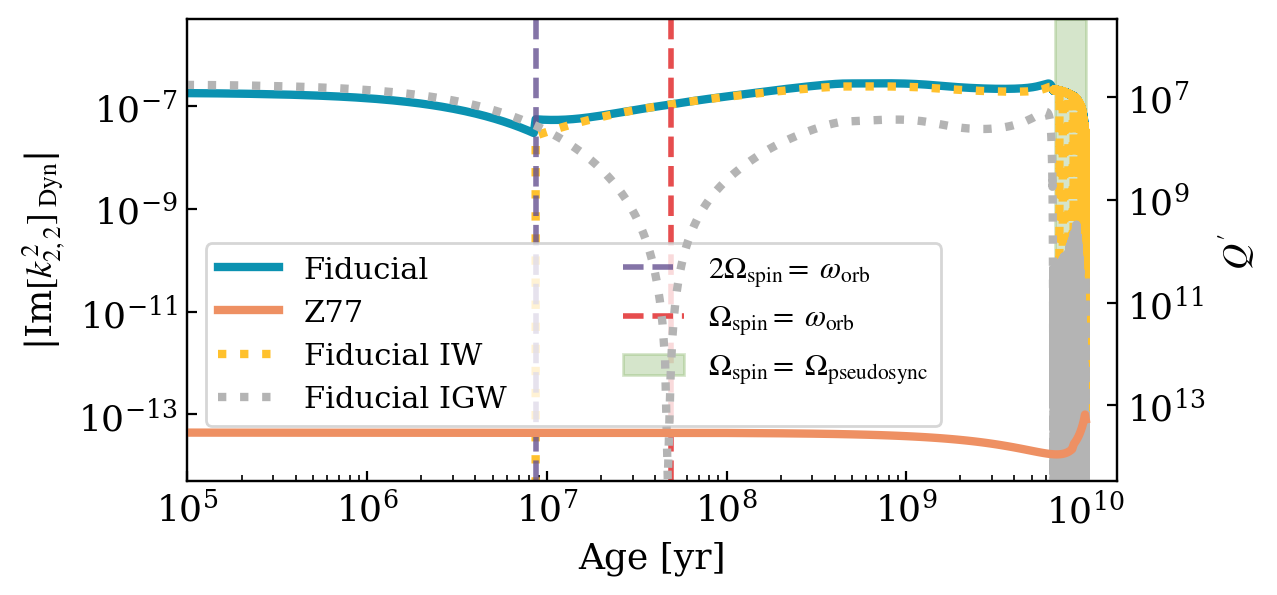

In [90]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

iw_idx = np.where(2*omega_spin >= omega_orb)[0][0]
sync_idx = np.where(omega_spin >= omega_orb)[0][0]

omega_pseudosync = (1 + (15/2)*ecc**2 + (45/8)*ecc**4 + (5/16)*ecc**6)/ ((1 + 3*ecc**2 + (3/8)*ecc**4)*(1-ecc**2)**(3/2)) * omega_orb
pseudosync_idx = np.where(omega_spin >= omega_pseudosync)[0][0]

ax.plot(Time, np.abs(Imk22_dyn), c=colorPalette['blue'], lw=3, ls='-', label=this_work)
ax.plot(Time_zahn, np.abs(Imk22_dyn_zahn), c=colorPalette['orange'], zorder=30, lw=3, ls='-', label=that_work)
ax.plot(Time, np.abs(imk22_inertial), c='#FFC12D', lw=3, ls=':', label=this_work+" IW")
ax.plot(Time, np.abs(imk22_env_gw), c=colorPalette['gray'], lw=3, ls=':', zorder=20,label=this_work+" IGW")

ax.axvline(Time[iw_idx], color=colorPalette['violet'], ls='--', lw=2, alpha=0.8, label='$2\Omega_{\\rm spin} = \; \omega_{\\rm orb}$')
ax.axvline(Time[sync_idx], color=colorPalette['red'], ls='--', lw=2, alpha=1, label='$\Omega_{\\rm spin} = \; \omega_{\\rm orb}$')
ax.axvspan(Time[pseudosync_idx], Time[-1], color=colorPalette['green'], alpha=0.3, label='$\Omega_{\\rm spin} = \; \Omega_{\\rm pseudosync}$')


imk_min = 5e-15 
imk_max = 5e-6
ax.set_ylim(imk_min, imk_max)
ax.set_xlim(1e5, 15e9)

ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', direction='in')

ax.set_ylabel("|Im$[k_{2,2}^2]_{\\rm \; Dyn}$|")
ax.set_xlabel("Age [yr]")

ax2 = ax.twinx() 
ax2.set_ylim(3/(2*imk_min), 3/(2*imk_max))
ax2.set_yscale('log')
ax2.set_ylabel("$Q'$")
ax2.tick_params(axis='both', which='both', direction='in', bottom=False)

ax.legend(loc=(0.02, 0.12), columnspacing=3.8, ncol=2, fontsize=11)

plt.savefig(PlotDir+plot_prefix+'imk22_dyn.pdf',dpi=300, bbox_inches='tight')

plt.show()

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


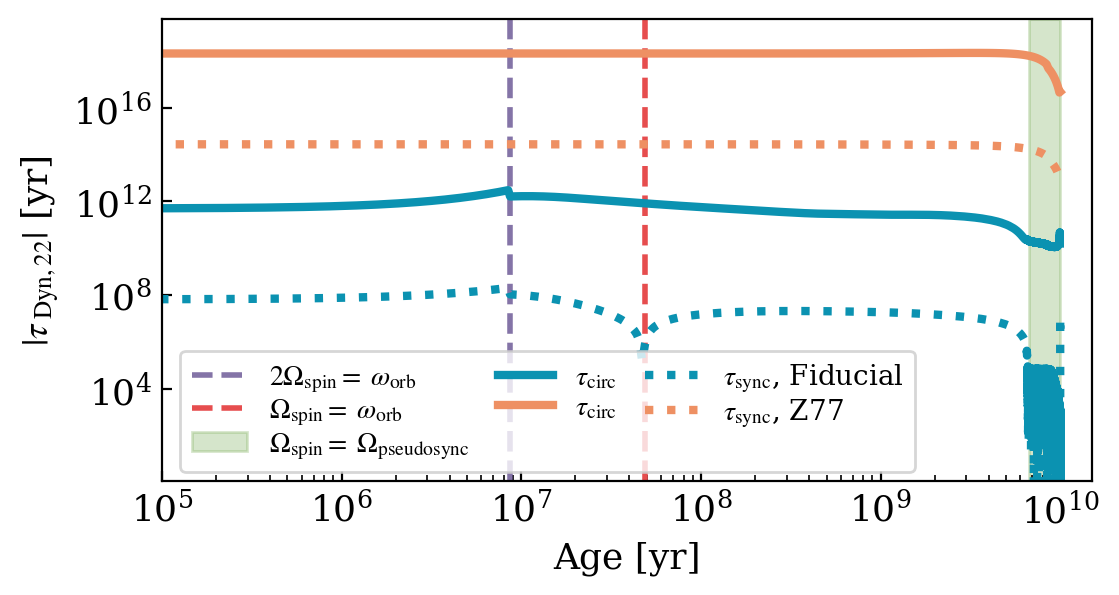

In [91]:
fig, (ax) = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

iw_idx = np.where(2*omega_spin >= omega_orb)[0][0]
sync_idx = np.where(omega_spin >= omega_orb)[0][0]

omega_pseudosync = (1 + (15/2)*ecc**2 + (45/8)*ecc**4 + (5/16)*ecc**6)/ ((1 + 3*ecc**2 + (3/8)*ecc**4)*(1-ecc**2)**(3/2)) * omega_orb
pseudosync_idx = np.where(omega_spin >= omega_pseudosync)[0][0]

ax.axvline(Time[iw_idx], color=colorPalette['violet'], ls='--', lw=2, alpha=0.8, label='$2\Omega_{\\rm spin} = \; \omega_{\\rm orb}$')
ax.axvline(Time[sync_idx], color=colorPalette['red'], ls='--', lw=2, alpha=1, label='$\Omega_{\\rm spin} = \; \omega_{\\rm orb}$')
ax.axvspan(Time[pseudosync_idx], Time[-1], color=colorPalette['green'], alpha=0.3, label='$\Omega_{\\rm spin} = \; \Omega_{\\rm pseudosync}$')

ax.plot(Time, np.abs(1/tau_circ_inv_dyn_22), c=colorPalette['blue'], lw=3, label="$\\tau_{\\rm circ}$")
ax.plot(Time_zahn, np.abs(1/tau_circ_inv_zahn_dyn_22), c=colorPalette['orange'], lw=3, label="$\\tau_{\\rm circ} \;$")

ax.plot(Time, np.abs(1/tau_sync_inv_dyn_22), c=colorPalette['blue'], lw=3, ls=':', label="$\\tau_{\\rm sync}$, "+this_work)
ax.plot(Time_zahn, np.abs(1/tau_sync_inv_zahn_dyn_22), c=colorPalette['orange'], lw=3, ls=':', label="$\\tau_{\\rm sync}$, "+that_work)

ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.tick_params(axis='both', which='both', direction='in')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e5, 15e9)
ax.set_ylim(1.1e0, 6e19)

ax.legend(loc=(0.02, 0.02), ncol=3, columnspacing=1, labelspacing=0.1, fontsize=10) # Int Mass


ax.set_ylabel("$|\\tau_{\\rm \; Dyn,22}|$ [yr]")
ax.set_xlabel("Age [yr]")

plt.savefig(PlotDir+plot_prefix+'tau_circ_sync_dyn.pdf', dpi=300, bbox_inches='tight')

plt.show()

### Compare Tidal Dissipation Mechanisms

In [118]:
compare_tides(df_sanity, imk22_core_gw, imk22_env_gw, imk22_inertial, Imk22_eq)

Convective core, NO radiative intershell, convective envelope:
No timesteps found

Convective core, radiative intershell, convective envelope:
Timesteps found: 135720
Stellar Types found: ['MS_GT_0.7']
Dynamical tides from convective core - radiative shell boundary: 0.0
Dynamical tides from radiative shell - convective envelope boundary: -0.00023319376296110578
*Dynamical tides from convective envelope IW dissipation: -0.0009615223992409003
*Equilibrium tides from convective envelope: -1.6937192715897328e-05

Convective core, radiative envelope:
Timesteps found: 1
Stellar Types found: ['MS_GT_0.7']
*Dynamical tides from convective core - radiative shell boundary: 0.0
Dynamical tides from radiative shell - convective envelope boundary: 0.0
Dynamical tides from convective envelope IW dissipation: 3.823274201246395e-14
Equilibrium tides from convective envelope: 0.0

Radiative core, convective envelope:
No timesteps found


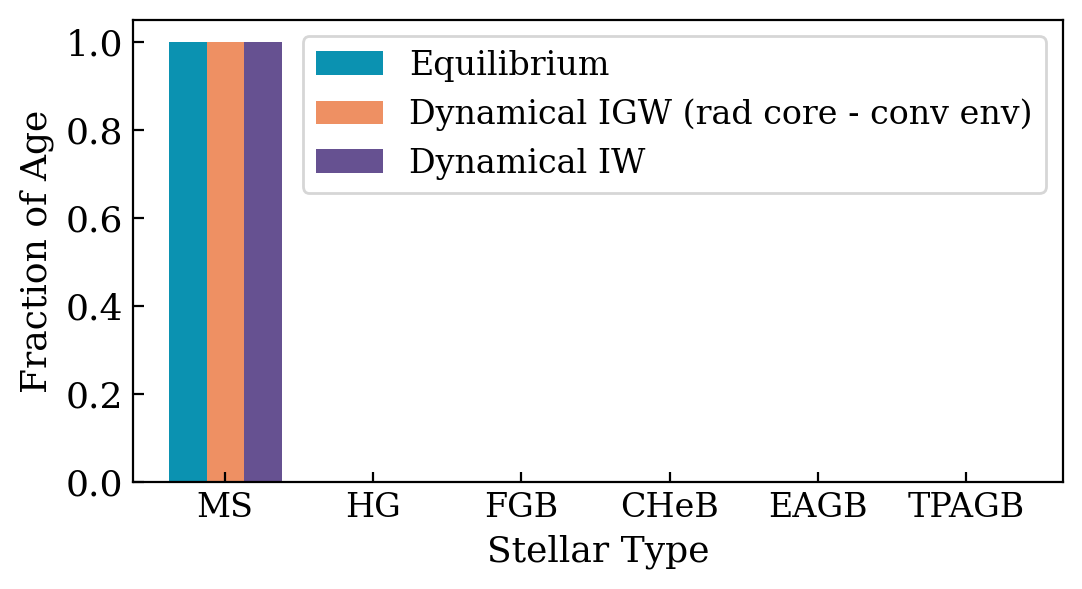

In [119]:
bins = np.linspace(-0.5, len(st_labels_plot)-0.5, len(st_labels_plot))


# Compute the fraction of the final time
total_time = df_sanity["Time"].values[-1] + df_sanity["Dt"].values[-1]

# Compute the sum of Dt for each stellar type
frac_dt_eq = df_sanity.loc[(np.abs(df_sanity["ImK10_1_eq"]) > 0)|(np.abs(df_sanity["ImK12_1_eq"]) > 0)|(np.abs(df_sanity["ImK22_1_eq"]) > 0)|(np.abs(df_sanity["ImK32_1_eq"]) > 0) ].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_core = df_sanity.loc[(np.abs(imk10_core_gw) > 0)|(np.abs(imk12_core_gw) > 0)|(np.abs(imk22_core_gw) > 0)|(np.abs(imk32_core_gw) > 0)].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_env = df_sanity.loc[(np.abs(imk10_env_gw) > 0) | (np.abs(imk22_env_gw) > 0) | (np.abs(imk12_env_gw) > 0) | (np.abs(imk32_env_gw) > 0)].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_iw = df_sanity.loc[np.abs(imk22_inertial) > 0].groupby("StellarType_1")["Dt"].sum() / total_time

# Generally group together MS types to make labels smaller
frac_dt_eq.index = frac_dt_eq.index.where(frac_dt_eq.index != 0, 1)
frac_dt_dyn_core.index = frac_dt_dyn_core.index.where(frac_dt_dyn_core.index != 0, 1)
frac_dt_dyn_env.index = frac_dt_dyn_env.index.where(frac_dt_dyn_env.index != 0, 1)
frac_dt_dyn_iw.index = frac_dt_dyn_iw.index.where(frac_dt_dyn_iw.index != 0, 1)

unique_idxs = np.unique(np.concatenate([frac_dt_eq.index.values, frac_dt_dyn_core.index.values, frac_dt_dyn_env.index.values, frac_dt_dyn_iw.index.values]))

# Plot bar chart
fig, ax = plt.subplots(nrows=1, figsize=(6, 3))

for idx in unique_idxs:
    n_bars = ((idx in frac_dt_eq.index) + (idx in frac_dt_dyn_core.index) + (idx in frac_dt_dyn_env.index) + (idx in frac_dt_dyn_iw.index))

    bar_width = 0.8 / n_bars
    offset = -0.07*n_bars

    if idx in frac_dt_eq.index:
        ax.bar(idx + offset, frac_dt_eq[idx], alpha=1.0, label="Equilibrium" if idx == frac_dt_eq.index[0] else "", width=bar_width, color=colorPalette['blue'])
        offset += bar_width

    if idx in frac_dt_dyn_core.index:
        ax.bar(idx + offset, frac_dt_dyn_core[idx], alpha=1.0, label="Dynamical IGW (conv core - rad env)" if idx == frac_dt_dyn_core.index[0] else "", width=bar_width, color=colorPalette['red'])
        offset += bar_width

    if idx in frac_dt_dyn_env.index:
        ax.bar(idx + offset, frac_dt_dyn_env[idx], alpha=1.0, label="Dynamical IGW (rad core - conv env)" if idx == frac_dt_dyn_env.index[0] else "", width=bar_width, color=colorPalette['orange'])
        offset += bar_width

    if idx in frac_dt_dyn_iw.index:
        ax.bar(idx + offset, frac_dt_dyn_iw[idx], alpha=1.0, label="Dynamical IW" if idx == frac_dt_dyn_iw.index[0] else "", width=bar_width, color=colorPalette['violet'])

# Set x-axis labels to the stellar types

ax.set_xticks(bins+0.5, labels=st_labels_plot, rotation=0, fontsize=12)
ax.tick_params(axis='y', size=10)

ax.set_xlim(0.4, len(st_labels_plot)-13)
ax.set_ylabel("Fraction of Age")
ax.set_xlabel('Stellar Type')

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='y', length=4)


ax.legend(fontsize=12)

plt.savefig(PlotDir+plot_prefix+'tides_type.pdf',dpi=300, bbox_inches='tight')
plt.show()

## High Mass MS (Figure 7)

COMPAS --number-of-systems 1 --random-seed 1 --output-path sim_data --output-container high_mass_ms --initial-mass-1 2.5 --initial-mass-2 2.5 --orbital-period 3 --eccentricity 0.5 --chemically-homogeneous-evolution-mode NONE --tides-prescription KAPIL2026  --maximum-number-timestep-iterations 1999999 


COMPAS --number-of-systems 1 --random-seed 1 --output-path sim_data --output-container high_mass_ms_z77 --initial-mass-1 2.5 --initial-mass-2 2.5 --orbital-period 3 --eccentricity 0.5 --chemically-homogeneous-evolution-mode NONE --tides-prescription ZAHN1977

In [120]:
plot_prefix = 'high_mass_ms_'

In [ ]:
DataPath = 'sim_data/high_mass_ms'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())
df_sanity = df_sanity[df_sanity["StellarType_1"]<=1]
df_sanity

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1,0.000000,0.001515,1,1,4.01277,4.01277,4.01277,4.01277,0.000000e+00,8.881670e-08,0.000000e+00,8.881670e-08,764.978,764.978,0.00000,0.00561,0.00000,0.00561,0.500000,0.500000,2.50000,1.71119,0.000016,0.000016,2.50000,1.71119,0.000016,0.000016,0.069611,0.069611,1.379820e-11,1.379820e-11,1.379820e-11,1.379820e-11,8.761300e-11,8.761300e-11,2.583120e-10,2.583120e-10,1.379820e-11,1.379820e-11,1.379820e-11,1.379820e-11,8.761300e-11,8.761300e-11,2.583120e-10,2.583120e-10,0,0,0,0,0,0,0,0,0.529192,0.270026,0.529192,0.270026,0,0,0,0,0,0,0,0,42.9696,42.9696,1.95723,1.95723,-3.642340e-12,-3.642340e-12,5.049230e-06,5.049230e-06,-1.732940e-11,-1.732940e-11,191.116,288.528,1.51504,1.51504,-2.653500e-10,-2.653500e-10,0,0,0,0,0,0,0,0,0,0,9.245620e-12,9.245620e-12,9.245620e-12,9.245620e-12,5.870610e-11,5.870610e-11,1.730850e-10,1.730850e-10,-2.440590e-12,-2.440590e-12,-1.161170e-11,-1.161170e-11,0.000003,0.000003
1,1,0.001515,1.515090,1,1,4.01277,4.01277,4.01277,4.01259,8.881670e-08,8.892240e-05,8.881670e-08,8.892240e-05,764.978,765.160,0.00561,5.61669,0.00561,5.61669,0.500000,0.499947,2.50000,1.71119,0.000016,0.000016,2.50000,1.71119,0.000016,0.000016,0.069611,0.069600,1.379790e-11,1.379790e-11,1.379730e-11,1.379730e-11,8.760920e-11,8.760920e-11,2.583030e-10,2.583030e-10,1.379790e-11,1.379790e-11,1.379730e-11,1.379730e-11,8.760920e-11,8.760920e-11,2.583030e-10,2.583030e-10,0,0,0,0,0,0,0,0,0.529192,0.270026,0.529192,0.270026,0,0,0,0,0,0,0,0,42.9696,42.9696,1.95723,1.95723,-3.642230e-12,-3.642230e-12,5.049070e-06,5.049070e-06,-1.732880e-11,-1.732880e-11,191.122,288.536,1.51509,1.51509,-2.653590e-07,-2.653590e-07,0,0,0,0,0,0,0,0,0,0,9.245670e-12,9.245670e-12,9.245300e-12,9.245300e-12,5.870520e-11,5.870520e-11,1.730840e-10,1.730840e-10,-2.440580e-12,-2.440580e-12,-1.161170e-11,-1.161170e-11,0.000003,0.000003
2,1,1.516600,1.562940,1,1,4.01277,4.01277,4.01259,4.01241,8.892230e-05,1.779860e-04,8.892230e-05,1.779860e-04,765.160,765.342,5.60325,11.21540,5.60325,11.21540,0.499947,0.499895,2.50000,1.71324,0.000016,0.000016,2.50000,1.71324,0.000016,0.000016,0.069600,0.069589,1.349310e-11,1.349310e-11,1.297250e-11,1.297250e-11,8.401300e-11,8.401300e-11,2.493260e-10,2.493260e-10,1.349310e-11,1.349310e-11,1.297250e-11,1.297250e-11,8.401300e-11,8.401300e-11,2.493260e-10,2.493260e-10,0,0,0,0,0,0,0,0,0.528648,0.269475,0.528648,0.269475,0,0,0,0,0,0,0,0,43.0167,43.0167,1.95659,1.95659,-3.539650e-12,-3.539650e-12,4.895630e-06,4.895630e-06,-1.684770e-11,-1.684770e-11,196.629,296.746,1.56294,1.56294,-2.743090e-07,-2.743090e-07,0,0,0,0,0,0,0,0,0,0,9.295930e-12,9.295930e-12,8.937290e-12,8.937290e-12,5.787990e-11,5.787990e-11,1.717710e

In [ ]:
DataPath_Zahn = 'sim_data/high_mass_ms_z77'
df_sanity_zahn = pd.read_csv(DataPath_Zahn+'/sanity_checks.csv')
df_sanity_zahn = df_sanity_zahn.rename(columns=lambda x: x.strip())
df_sanity_zahn = df_sanity_zahn[df_sanity_zahn["StellarType_1"]<=1]
df_sanity_zahn

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1,0.000000,0.005898,1,1,4.01277,4.01277,4.01277,4.01277,0.000000e+00,3.159390e-07,0.000000e+00,3.159390e-07,764.978,764.978,0.000000,0.019956,0.000000,0.019956,0.500000,0.500000,2.50000,1.71119,0.000016,0.000016,2.50000,1.71119,0.000016,0.000016,0.069611,0.069611,1.379820e-11,1.379820e-11,1.379820e-11,1.379820e-11,8.761300e-11,8.761300e-11,2.583120e-10,2.583120e-10,1.379820e-11,1.379820e-11,1.379820e-11,1.379820e-11,8.761300e-11,8.761300e-11,2.583120e-10,2.583120e-10,0,0,0,0,0,0,0,0,0.529192,0.270026,0.529192,0.270026,0,0,0,0,0,0,0,0,42.9696,42.9696,1.95723,1.95723,-3.642340e-12,-3.642340e-12,5.049230e-06,5.049230e-06,-1.732940e-11,-1.732940e-11,191.116,288.528,1.51504,1.51504,-1.033070e-09,-1.033070e-09,0,0,0,0,0,0,0,0,0,0,9.245620e-12,9.245620e-12,9.245620e-12,9.245620e-12,5.870610e-11,5.870610e-11,1.730850e-10,1.730850e-10,-2.440590e-12,-2.440590e-12,-1.161170e-11,-1.161170e-11,0.000003,0.000003
1,1,0.005898,5.898390,1,1,4.01277,4.01283,4.01277,4.01259,3.159380e-07,1.214270e-04,3.159380e-07,1.214270e-04,764.978,765.160,0.019956,7.669730,0.019956,7.669730,0.500000,0.499947,2.50000,1.71120,0.000016,0.000016,2.50000,1.71120,0.000016,0.000016,0.069611,0.069600,1.379690e-11,1.379690e-11,1.379500e-11,1.379500e-11,8.759890e-11,8.759890e-11,2.582770e-10,2.582770e-10,1.379690e-11,1.379690e-11,1.379500e-11,1.379500e-11,8.759890e-11,8.759890e-11,2.582770e-10,2.582770e-10,0,0,0,0,0,0,0,0,0.529190,0.270024,0.529190,0.270024,0,0,0,0,0,0,0,0,42.9697,42.9697,1.95722,1.95722,-3.641920e-12,-3.641920e-12,5.048600e-06,5.048600e-06,-1.732740e-11,-1.732740e-11,191.138,288.561,1.51523,1.51523,-1.033080e-06,-1.033080e-06,0,0,0,0,0,0,0,0,0,0,9.245780e-12,9.245780e-12,9.244490e-12,9.244490e-12,5.870290e-11,5.870290e-11,1.730800e-10,1.730800e-10,-2.440570e-12,-2.440570e-12,-1.161170e-11,-1.161170e-11,0.000003,0.000003
2,1,5.904290,5.898400,1,1,4.01283,4.01290,4.01259,4.01241,1.214260e-04,2.437000e-04,1.214260e-04,2.437000e-04,765.159,765.343,7.598540,15.250100,7.598540,15.250100,0.499947,0.499894,2.50000,1.71919,0.000016,0.000016,2.50000,1.71919,0.000016,0.000016,0.069600,0.069589,1.262210e-11,1.262210e-11,1.196460e-11,1.196460e-11,7.804070e-11,7.804070e-11,2.321470e-10,2.321470e-10,1.262210e-11,1.262210e-11,1.196460e-11,1.196460e-11,7.804070e-11,7.804070e-11,2.321470e-10,2.321470e-10,0,0,0,0,0,0,0,0,0.527073,0.267882,0.527073,0.267882,0,0,0,0,0,0,0,0,43.1539,43.1539,1.95476,1.95476,-3.353560e-12,-3.353560e-12,4.606230e-06,4.606230e-06,-1.596290e-11,-1.596290e-11,207.540,313.194,1.66114,1.66114,-1.041480e-06,-1.041480e-06,0,0,0,0,0,0,0,0,0,0,9.425730e-12,9.425730e-12,8.934740e-12,8.934740e-12,5.827780e-11,5.827780e-

In [124]:
rc = df_sanity["R1_core"].values * u.R_sun              # Rsol
R = df_sanity["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

rc2 = df_sanity["R2_core"].values * u.R_sun              # Rsol
R2 = df_sanity["R2"].values * u.R_sun                    # Rsol
Renv2 = df_sanity["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2 = R2 - Renv2

L = df_sanity["Lum_1"].values * u.L_sun                 # Lsol
L2 = df_sanity["Lum_2"].values * u.L_sun                 # Lsol

M = df_sanity["M1"].values * u.M_sun                    # Msol
Mc = df_sanity["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity["M2"].values * u.M_sun                   # Msol
Mc2 = df_sanity["M2_core"].values * u.M_sun              # Msol
Menv2 = df_sanity["M2_conv_env"].values * u.M_sun        # Msol


I1 = df_sanity["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity["tau_conv1"].values * u.yr                # yr
tau_conv2 = df_sanity["tau_conv2"].values * u.yr                # yr


omega_orb = df_sanity["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity["Omega1_before"].values / u.yr   # 1/yr
omega_spin2 = df_sanity["Omega2_before"].values / u.yr   # 1/yr

sma = df_sanity["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity["ecc_before"].values                           # 1
period_orb = 2 * np.pi / df_sanity["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk10 = df_sanity["ImK10_1"].values
Imk12 = df_sanity["ImK12_1"].values
Imk22 = df_sanity["ImK22_1"].values
Imk32 = df_sanity["ImK32_1"].values

Imk10_dyn = df_sanity["ImK10_1_dyn"].values
Imk12_dyn = df_sanity["ImK12_1_dyn"].values
Imk22_dyn = df_sanity["ImK22_1_dyn"].values
Imk32_dyn = df_sanity["ImK32_1_dyn"].values

Imk10_eq = df_sanity["ImK10_1_eq"].values
Imk12_eq = df_sanity["ImK12_1_eq"].values
Imk22_eq = df_sanity["ImK22_1_eq"].values
Imk32_eq = df_sanity["ImK32_1_eq"].values

Imk10_2 = df_sanity["ImK10_2"].values
Imk12_2 = df_sanity["ImK12_2"].values
Imk22_2 = df_sanity["ImK22_2"].values
Imk32_2 = df_sanity["ImK32_2"].values

Imk10_2_dyn = df_sanity["ImK10_2_dyn"].values
Imk12_2_dyn = df_sanity["ImK12_2_dyn"].values
Imk22_2_dyn = df_sanity["ImK22_2_dyn"].values
Imk32_2_dyn = df_sanity["ImK32_2_dyn"].values

Imk10_2_eq = df_sanity["ImK10_2_eq"].values
Imk12_2_eq = df_sanity["ImK12_2_eq"].values
Imk22_2_eq = df_sanity["ImK22_2_eq"].values
Imk32_2_eq = df_sanity["ImK32_2_eq"].values

dadt = df_sanity["dadt1"].values * u.AU / u.yr
dOmegadt = df_sanity["dOmegadt1"].values / u.yr**2
dedt1 = df_sanity["dedt1"].values / u.yr


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity["StellarType_1"].values
st2 = df_sanity["StellarType_2"].values

rc_AU = df_sanity["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     


rc_AU2 = df_sanity["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2 = df_sanity["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2 = df_sanity["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2 = R_AU2 - Renv_AU2                 
Mint2 = M2 - Mc2 - Menv2    

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [125]:
rc_zahn = df_sanity_zahn["R1_core"].values * u.R_sun              # Rsol
R_zahn = df_sanity_zahn["R1"].values * u.R_sun                    # Rsol
Renv_zahn = df_sanity_zahn["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint_zahn = R_zahn - Renv_zahn

rc2_zahn = df_sanity_zahn["R2_core"].values * u.R_sun              # Rsol
R2_zahn = df_sanity_zahn["R2"].values * u.R_sun                    # Rsol
Renv2_zahn = df_sanity_zahn["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2_zahn = R2_zahn - Renv2_zahn

L_zahn = df_sanity_zahn["Lum_1"].values * u.L_sun                 # Lsol
L2_zahn = df_sanity_zahn["Lum_2"].values * u.L_sun                 # Lsol

M_zahn = df_sanity_zahn["M1"].values * u.M_sun                    # Msol
Mc_zahn = df_sanity_zahn["M1_core"].values * u.M_sun              # Msol
Menv_zahn = df_sanity_zahn["M1_conv_env"].values * u.M_sun        # Msol

M2_zahn = df_sanity_zahn["M2"].values * u.M_sun                   # Msol
Mc2_zahn = df_sanity_zahn["M2_core"].values * u.M_sun              # Msol
Menv2_zahn = df_sanity_zahn["M2_conv_env"].values * u.M_sun        # Msol


I1_zahn = df_sanity_zahn["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv_zahn = df_sanity_zahn["tau_conv1"].values * u.yr                # yr
tau_conv2_zahn = df_sanity_zahn["tau_conv2"].values * u.yr                # yr


omega_orb_zahn = df_sanity_zahn["Omega_before"].values / u.yr     # 1/yr
omega_spin_zahn = df_sanity_zahn["Omega1_before"].values / u.yr   # 1/yr
omega_spin2_zahn = df_sanity_zahn["Omega2_before"].values / u.yr   # 1/yr

sma_zahn = df_sanity_zahn["SemiMajorAxis_before"].values * u.AU   # AU
ecc_zahn = df_sanity_zahn["ecc_before"].values                           # 1
period_orb_zahn = 2 * np.pi / df_sanity_zahn["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk22_dyn_zahn = df_sanity_zahn["ImK22_Zahn_Dynamical1"].values
Imk22_eq_zahn = df_sanity_zahn["ImK22_Zahn_Equilibrium1"].values
Imk22_zahn = Imk22_dyn_zahn + Imk22_eq_zahn

Imk22_2_dyn_zahn = df_sanity_zahn["ImK22_Zahn_Dynamical2"].values
Imk22_2_eq_zahn = df_sanity_zahn["ImK22_Zahn_Equilibrium2"].values
Imk22_2_zahn = Imk22_2_dyn_zahn + Imk22_2_eq_zahn


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time_zahn = df_sanity_zahn["Time"].values * 1e6 * u.yr          # yr
st1_zahn = df_sanity_zahn["StellarType_1"].values
st2_zahn = df_sanity_zahn["StellarType_2"].values

rc_AU_zahn = df_sanity_zahn["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU_zahn = df_sanity_zahn["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU_zahn = df_sanity_zahn["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU_zahn = R_AU_zahn - Renv_AU_zahn
Mint_zahn = M_zahn - Mc_zahn - Menv_zahn


rc_AU2_zahn = df_sanity_zahn["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2_zahn = df_sanity_zahn["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2_zahn = df_sanity_zahn["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2_zahn = R_AU2_zahn - Renv_AU2_zahn
Mint2_zahn = M2_zahn - Mc2_zahn - Menv2_zahn

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

### Stellar Evolution

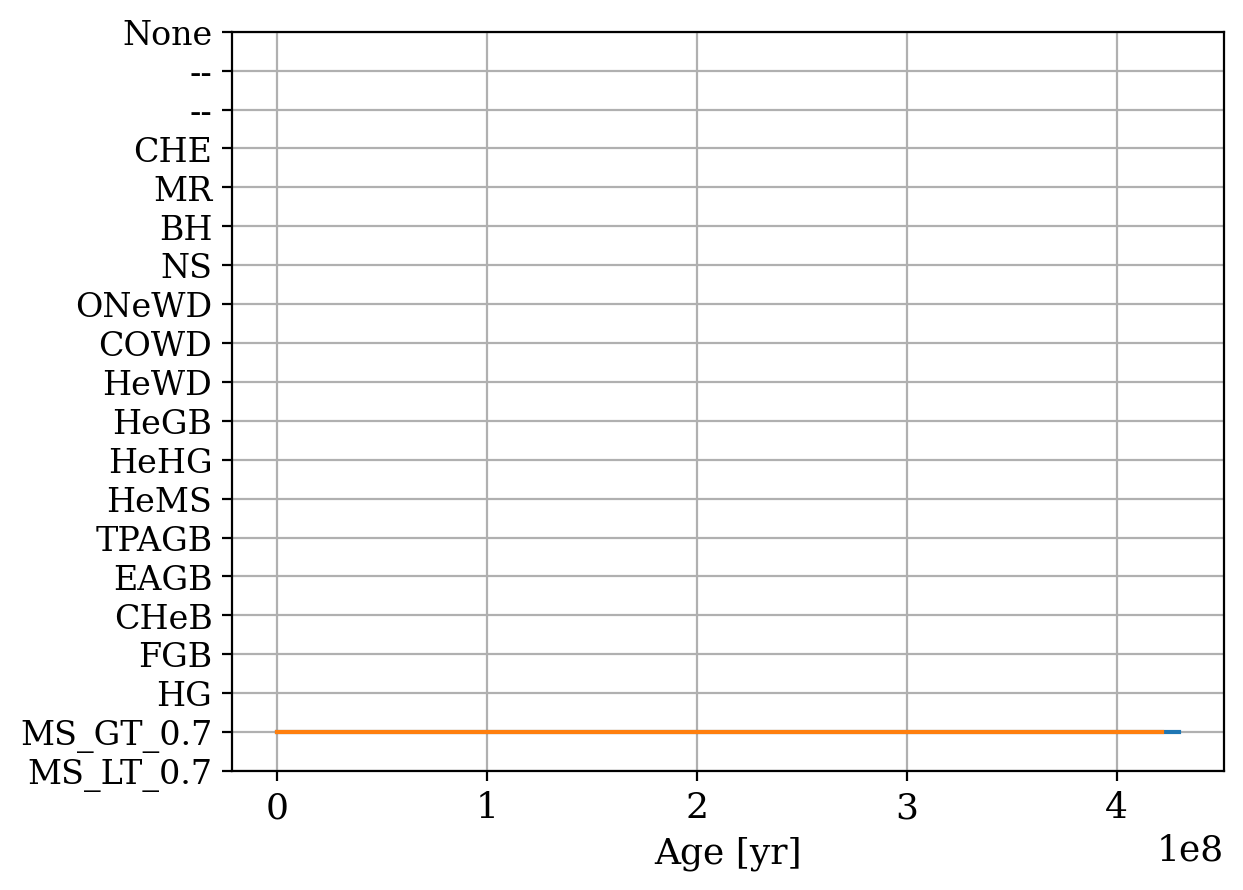

In [126]:
plt.plot(Time, st1)
plt.plot(Time_zahn, st1_zahn)
y_ticks=np.linspace(0, 19, 20)
plt.yticks(y_ticks, st_labels, fontsize=12)

plt.xlabel("Age [yr]")
plt.grid()
plt.show()

### Stellar Structure

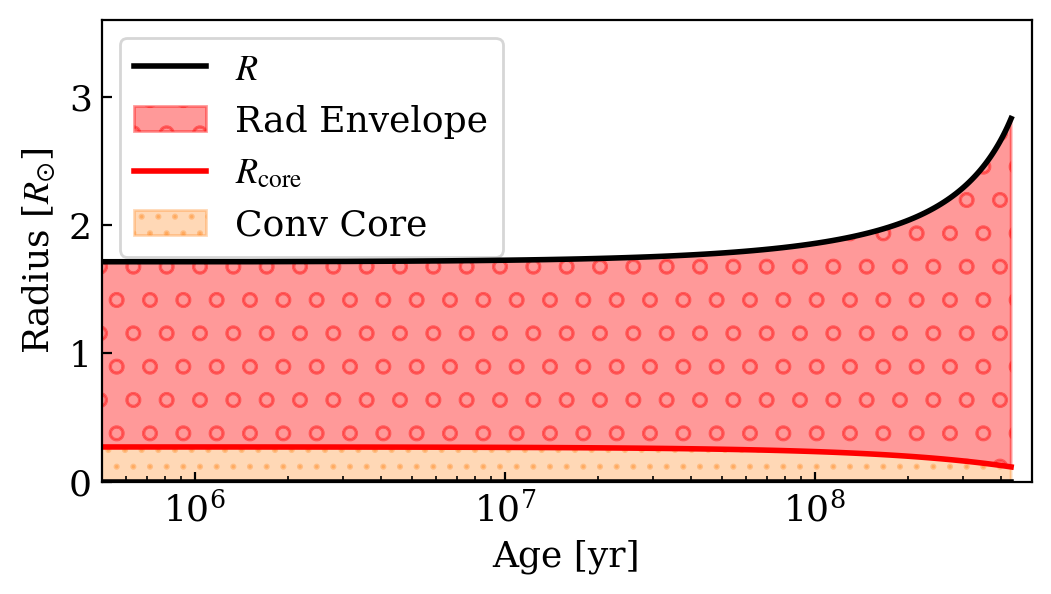

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

plt.plot(Time, R, c='k', zorder=10, lw=2, label="$R$")

if any(Rint<=R) and any(Rint>rc):
    ax.fill_between(Time.value, rc.value, Rint.value, color='r', alpha=0.4, hatch="o", label="Rad Envelope")

if any(rc/R > frac_limit):
    ax.plot(Time.value, rc.value, lw=2, c='r', label='$R_{\\rm core}$') 
    ax.fill_between(Time.value, 0, rc.value, color='C1', alpha=0.3, hatch="..", label="Conv Core")


elif any((R-Renv)/R > frac_limit):
    plt.plot(Time.value, (R-Renv).value, lw=2, c='r', label='$R_{\\rm core}$') 
    plt.fill_between(Time.value, 0, (R-Renv).value, color='r', alpha=0.2, hatch=".", label="Rad Core")

plt.plot(Time.value, np.zeros(len(Time)), lw=2, c='k')

plt.ylabel("Radius [$R_{\odot}$]")
plt.xlabel("Age [yr]")

ax.tick_params(axis='both', which='both', direction='in')


plt.ylim(0, 3.6) 
plt.xlim(5e5, 5e8)

plt.semilogx()

plt.legend(loc='upper left')

plt.savefig(PlotDir+plot_prefix+'stellar_structure.png',dpi=300, bbox_inches='tight')
plt.show()

### Orbital Properties

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


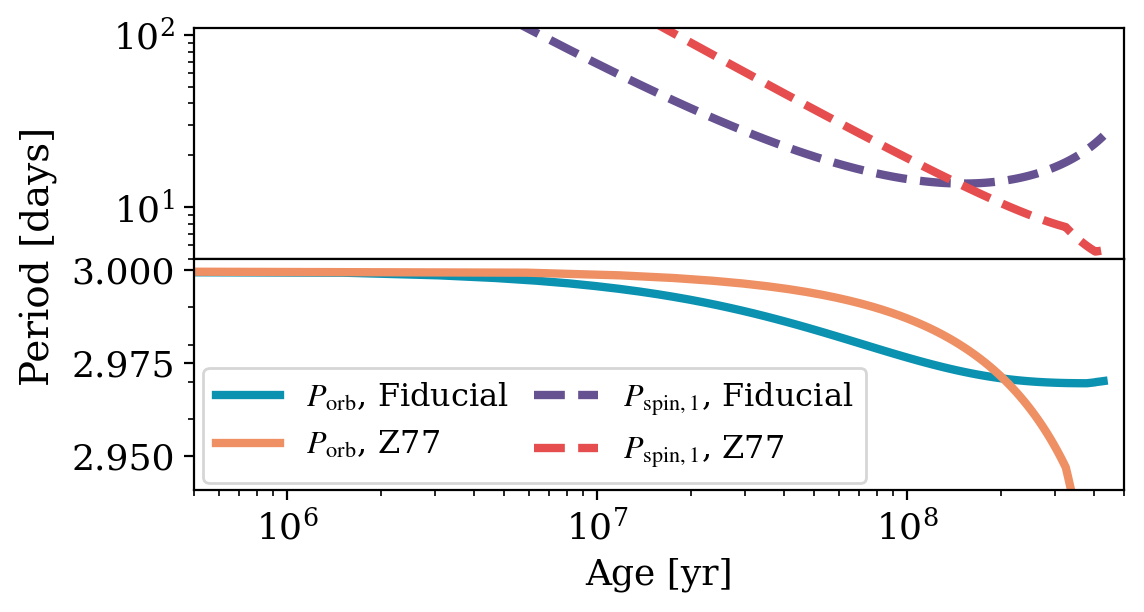

In [128]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6,3), sharex=True)

for ax in [ax1, ax2]:
    period_spin = 2 * np.pi / omega_spin.to(1/u.day)     # days
    period_spin_zahn = 2 * np.pi / omega_spin_zahn.to(1/u.day)     # days

    ax.plot(Time, period_orb, lw=3, c=colorPalette['blue'], label='$P_{\\rm orb}$, '+this_work)
    ax.plot(Time_zahn, period_orb_zahn, lw=3, c=colorPalette['orange'], label='$P_{\\rm orb}$, '+that_work)
    ax.plot(Time, period_spin, lw=3, c=colorPalette['violet'], ls='--', label='$P_{\\rm spin, 1}$, '+this_work)
    ax.plot(Time_zahn, period_spin_zahn, lw=3, c=colorPalette['red'], ls='--', label='$P_{\\rm spin, 1}$, '+that_work)

    ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
    ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
    
    ax.set_xlim(5e5, 5e8)
    ax.set_xscale('log')

ax = ax1
ax.set_ylim(5e0, 1.1e2)
ax.set_yscale('log')

ax = ax2
ax.set_ylim(2.941, 3.003)

ax.set_xlabel("Age [yr]")

ax.legend(loc=(0.01, 0.03), ncol=2, columnspacing=0.8, fontsize=11.5)
fig.subplots_adjust(hspace=0.0)
fig.text(-0.02, 0.5, 'Period [days]', ha='left', va='center', fontsize=14, rotation='vertical')

plt.savefig(PlotDir+plot_prefix+'period_evolution.pdf',dpi=300, bbox_inches='tight')

plt.show()

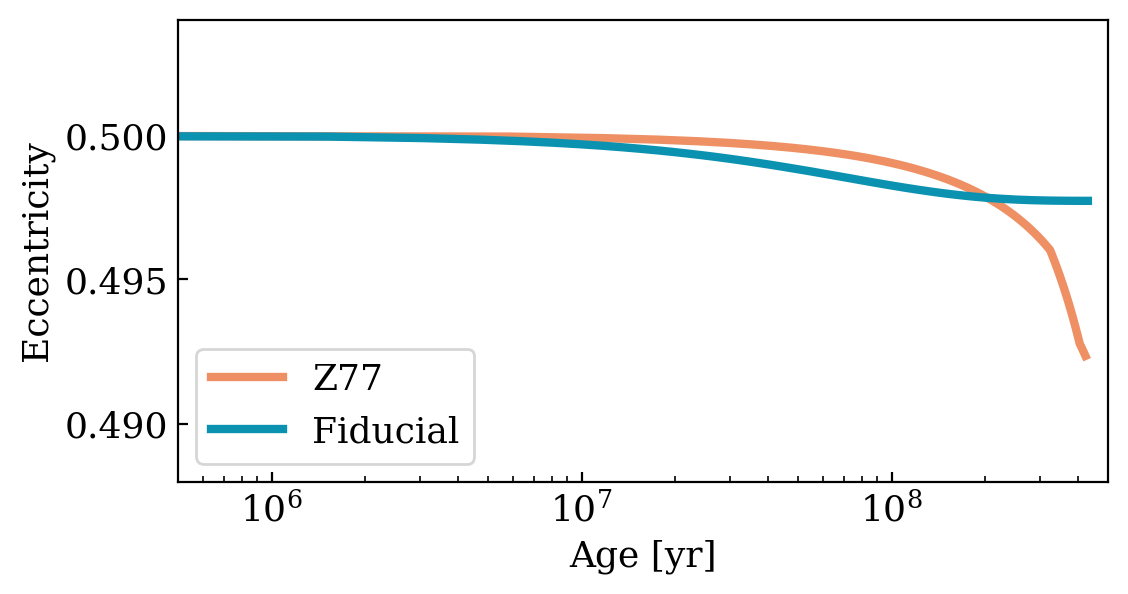

In [129]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

plt.plot(Time_zahn, ecc_zahn, c=colorPalette['orange'], lw=3, label=that_work)
plt.plot(Time, ecc, c=colorPalette['blue'], lw=3, label=this_work)


ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))

ax.set_ylabel("Eccentricity")
ax.set_xlabel("Age [yr]")

ax.set_xlim(5e5, 5e8)
ax.set_ylim(0.488, 0.504)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', direction='in')

plt.legend()

plt.savefig(PlotDir+plot_prefix+'ecc_evolution.pdf',dpi=300, bbox_inches='tight')


plt.show()

### Dynamical Tide with Radiative Damping

#### Fiducial

In [ ]:
# Total Dynamical Tide
dedt1_dyn = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*Imk10_dyn/2) - (Imk12_dyn/4) - Imk22_dyn + (49*Imk32_dyn/4))
tau_circ_inv_dyn = - dedt1_dyn / ecc
1/tau_circ_inv_dyn

<Quantity [2.88538635e+10, 2.88548584e+10, 2.96759322e+10, 3.05380642e+10,
           3.14451637e+10, 3.24011417e+10, 3.34085204e+10, 3.44730375e+10,
           3.56002279e+10, 3.67933687e+10, 3.80598708e+10, 3.94069841e+10,
           4.08420714e+10, 4.23759229e+10, 4.40174297e+10, 4.57787633e+10,
           4.76738411e+10, 4.97179690e+10, 5.19331172e+10, 5.43379377e+10,
           5.69618743e+10, 5.98346956e+10, 6.29952297e+10, 6.64904185e+10,
           7.03789237e+10, 7.47310364e+10, 7.96399975e+10, 8.52229869e+10,
           9.16316239e+10, 9.90766217e+10, 1.07653969e+11, 1.16914145e+11,
           1.26926181e+11, 1.37751734e+11, 1.49476276e+11, 1.62179238e+11,
           1.75962997e+11, 1.90934758e+11, 2.07210057e+11, 2.24916416e+11,
           2.44206213e+11, 2.65243144e+11, 2.88205891e+11, 3.13299786e+11,
           3.40750651e+11, 3.70816279e+11, 4.03786528e+11, 4.39978061e+11,
           4.79742071e+11, 5.23489037e+11, 5.71686960e+11, 6.24835578e+11,
           6.83538458e+11

In [130]:
# (2,2) Dynamical Tide
dedt1_dyn_22 = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- Imk22_dyn)
tau_circ_inv_dyn_22 = - dedt1_dyn_22 / ecc
1/tau_circ_inv_dyn_22

<Quantity [-1.01894246e+12, -1.01898666e+12, -1.05517892e+12,
           -1.09335994e+12, -1.13371205e+12, -1.17642385e+12,
           -1.22164017e+12, -1.26961606e+12, -1.32062593e+12,
           -1.37485509e+12, -1.43265165e+12, -1.49436936e+12,
           -1.56036383e+12, -1.63114541e+12, -1.70716618e+12,
           -1.78900662e+12, -1.87735150e+12, -1.97293262e+12,
           -2.07676618e+12, -2.18977999e+12, -2.31338617e+12,
           -2.44896893e+12, -2.59840761e+12, -2.76389555e+12,
           -2.94817972e+12, -3.15458138e+12, -3.38743123e+12,
           -3.65219814e+12, -3.95591533e+12, -4.30823462e+12,
           -4.71340046e+12, -5.14963550e+12, -5.61974570e+12,
           -6.12635804e+12, -6.67299622e+12, -7.26298150e+12,
           -7.90059898e+12, -8.59031041e+12, -9.33700651e+12,
           -1.01459170e+13, -1.10235081e+13, -1.19765716e+13,
           -1.30125124e+13, -1.41399579e+13, -1.53683047e+13,
           -1.67083318e+13, -1.81719658e+13, -1.97722950e+13,
        

In [131]:
dOmegadt1_dyn = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_dyn + ecc**2 * ((Imk12_dyn/4) - (5*Imk22_dyn) + (49*Imk32_dyn/4)))
tau_sync_inv_dyn = - dOmegadt1_dyn / (omega_spin - omega_orb)
1/tau_sync_inv_dyn

<Quantity [1.51509868e+08, 1.51514004e+08, 1.55157349e+08, 1.58986275e+08,
           1.63021730e+08, 1.67282381e+08, 1.71779070e+08, 1.76542374e+08,
           1.81596655e+08, 1.86959776e+08, 1.92668293e+08, 1.98757304e+08,
           2.05265921e+08, 2.12246620e+08, 2.19744212e+08, 2.27823763e+08,
           2.36554161e+08, 2.46017552e+08, 2.56324415e+08, 2.67576328e+08,
           2.79925411e+08, 2.93535694e+08, 3.08610770e+08, 3.25409937e+08,
           3.44247824e+08, 3.65520347e+08, 3.89743224e+08, 4.17579410e+08,
           4.49891273e+08, 4.87895899e+08, 5.32276728e+08, 5.80880314e+08,
           6.34194103e+08, 6.92679555e+08, 7.56952575e+08, 8.27612726e+08,
           9.05417672e+08, 9.91178724e+08, 1.08578660e+09, 1.19026138e+09,
           1.30576781e+09, 1.43362235e+09, 1.57528488e+09, 1.73243952e+09,
           1.90698487e+09, 2.10106677e+09, 2.31717155e+09, 2.55806611e+09,
           2.82685000e+09, 3.12720646e+09, 3.46336247e+09, 3.83991951e+09,
           4.26253480e+09

In [132]:
dOmegadt1_dyn_22 = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_dyn)
tau_sync_inv_dyn_22 = - dOmegadt1_dyn_22 / (omega_spin - omega_orb)
1/tau_sync_inv_dyn_22

<Quantity [1.33163576e+09, 1.33168375e+09, 1.37261357e+09, 1.41576770e+09,
           1.46136808e+09, 1.50963859e+09, 1.56073515e+09, 1.61497701e+09,
           1.67267733e+09, 1.73405817e+09, 1.79954226e+09, 1.86954693e+09,
           1.94452318e+09, 2.02507067e+09, 2.11175455e+09, 2.20530623e+09,
           2.30656080e+09, 2.41645612e+09, 2.53624976e+09, 2.66715714e+09,
           2.81095888e+09, 2.96949462e+09, 3.14517910e+09, 3.34096168e+09,
           3.56044616e+09, 3.80816067e+09, 4.09000749e+09, 4.41352445e+09,
           4.78852538e+09, 5.22867409e+09, 5.74149126e+09, 6.30147952e+09,
           6.91367709e+09, 7.58312601e+09, 8.31625079e+09, 9.11944713e+09,
           1.00006988e+10, 1.09685406e+10, 1.20323934e+10, 1.32028570e+10,
           1.44923077e+10, 1.59144284e+10, 1.74844087e+10, 1.92199045e+10,
           2.11406012e+10, 2.32689170e+10, 2.56303887e+10, 2.82535598e+10,
           3.11706262e+10, 3.44191236e+10, 3.80425410e+10, 4.20882760e+10,
           4.66136823e+10

##### Core only, IGWs

In [133]:
E2_kushnir = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.)
E2_kushnir

<Quantity [3.20610104e-08, 3.20610104e-08, 3.11823688e-08, 3.03010338e-08,
           2.94156689e-08, 2.85281701e-08, 2.76363448e-08, 2.67411138e-08,
           2.58454179e-08, 2.49457823e-08, 2.40434458e-08, 2.31398656e-08,
           2.22341867e-08, 2.13286117e-08, 2.04218189e-08, 1.95140839e-08,
           1.86068691e-08, 1.76996146e-08, 1.67952572e-08, 1.58913840e-08,
           1.49908719e-08, 1.40928360e-08, 1.31998275e-08, 1.23109685e-08,
           1.14290063e-08, 1.05537716e-08, 9.68743829e-09, 8.83134417e-09,
           7.98646942e-09, 7.15586871e-09, 6.35573544e-09, 5.63951136e-09,
           4.99891527e-09, 4.42624243e-09, 3.91475404e-09, 3.45824185e-09,
           3.05156756e-09, 2.68934656e-09, 2.36724676e-09, 2.08089456e-09,
           1.82676234e-09, 1.60152680e-09, 1.40199789e-09, 1.22561740e-09,
           1.06978631e-09, 9.32364359e-10, 8.11306240e-10, 7.04837872e-10,
           6.11327311e-10, 5.29295393e-10, 4.57507367e-10, 3.94723100e-10,
           3.39950715e-10

In [134]:
l=1
m=0
imk10_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk10_core_gw[np.isnan(imk10_core_gw)] = 0.0

l=1
m=2
imk12_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk12_core_gw[np.isnan(imk12_core_gw)] = 0.0

l=2
m=2
imk22_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk22_core_gw[(rc_AU/R_AU < frac_limit) | (Mc/M < frac_limit)] = 0.0
imk22_core_gw[np.isnan(imk22_core_gw)] = 0.0

l=3
m=2
imk32_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk32_core_gw[np.isnan(imk32_core_gw)] = 0.0

In [135]:
dedt1_dyn_core_gw = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*imk10_core_gw/2) - (imk12_core_gw/4) - imk22_core_gw + (49*imk32_core_gw/4))
tau_circ_inv_dyn_core_gw = - dedt1_dyn_core_gw / ecc
tau_circ_inv_dyn_core_gw

<Quantity [3.46591074e-11, 3.46586660e-11, 3.36987273e-11, 3.27476041e-11,
           3.18025942e-11, 3.08647735e-11, 2.99340460e-11, 2.90090083e-11,
           2.80913866e-11, 2.71806489e-11, 2.62755226e-11, 2.53773687e-11,
           2.44851286e-11, 2.35994809e-11, 2.27195634e-11, 2.18452835e-11,
           2.09768423e-11, 2.01137405e-11, 1.92566868e-11, 1.84043535e-11,
           1.75567958e-11, 1.67134020e-11, 1.58753009e-11, 1.50403311e-11,
           1.42096202e-11, 1.33818909e-11, 1.25569799e-11, 1.17346423e-11,
           1.09136012e-11, 1.00938085e-11, 9.28938983e-12, 8.55369256e-12,
           7.87906395e-12, 7.25994872e-12, 6.69045999e-12, 6.16618801e-12,
           5.68330509e-12, 5.23762589e-12, 4.82639182e-12, 4.44635178e-12,
           4.09507020e-12, 3.77036526e-12, 3.46987216e-12, 3.19203000e-12,
           2.93482334e-12, 2.69691256e-12, 2.47666929e-12, 2.27294179e-12,
           2.08457662e-12, 1.91031284e-12, 1.74931631e-12, 1.60046873e-12,
           1.46307122e-12

In [136]:
dOmegadt1_dyn_core_gw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_core_gw + ecc**2 * ((imk12_core_gw/4) - (5*imk22_core_gw) + (49*imk32_core_gw/4)))
tau_sync_inv_dyn_core_gw = - dOmegadt1_dyn_core_gw / (omega_spin - omega_orb)
tau_sync_inv_dyn_core_gw

<Quantity [6.60055468e-09, 6.60051806e-09, 6.44533536e-09, 6.29015566e-09,
           6.13438329e-09, 5.97823797e-09, 5.82173471e-09, 5.66452479e-09,
           5.50703870e-09, 5.34910577e-09, 5.19049070e-09, 5.03149083e-09,
           4.87184312e-09, 4.71173485e-09, 4.55100397e-09, 4.38957756e-09,
           4.22755884e-09, 4.06480874e-09, 3.90153921e-09, 3.73745558e-09,
           3.57262311e-09, 3.40688155e-09, 3.24054866e-09, 3.07316346e-09,
           2.90505185e-09, 2.73594226e-09, 2.56588897e-09, 2.39490083e-09,
           2.22282814e-09, 2.04974146e-09, 1.87879654e-09, 1.72160702e-09,
           1.57689814e-09, 1.44377082e-09, 1.32117266e-09, 1.20832802e-09,
           1.10451937e-09, 1.00894504e-09, 9.21062135e-10, 8.40199933e-10,
           7.65864773e-10, 6.97578075e-10, 6.34829714e-10, 5.77256708e-10,
           5.24410550e-10, 4.75976829e-10, 4.31580350e-10, 3.90937723e-10,
           3.53771555e-10, 3.19783114e-10, 2.88754454e-10, 2.60429883e-10,
           2.34617540e-10

##### Envelope only, IGWs

In [137]:
dNlnr_cbrt = (G_AU_Msol_yr * Mint / (Rint_AU * (R_AU - Rint_AU)**2))**(1/3)

alpha = Rint_AU/R_AU
beta = Mint/M

# one_minus_beta = 1-beta
one_minus_beta = Menv/M

# gamma = alpha**3 * (1-beta) / (beta * (1 - alpha**3))
rho_conv = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3))
rho_rad = Mint / (4 * np.pi * (Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

Epsilon = alpha**11 * (one_minus_beta) * (1-gamma)**2 * (2*alpha/3 - 1)**2 / (beta**2 * (1-alpha**3) * (1-alpha)**2)

l=1
m=0
imk10_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) *  (2*(2+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk10_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk10_env_gw)
imk10_env_gw[np.isnan(imk10_env_gw)] = 0.0

l=1
m=2
imk12_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) *  (2*(2+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk12_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk12_env_gw)
imk12_env_gw[np.isnan(imk12_env_gw)] = 0.0

l=2
m=2
imk22_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (2*(2+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk22_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk22_env_gw)
imk22_env_gw[(Renv_AU/R_AU < frac_limit) | (Menv/M < frac_limit)] = 0.0
imk22_env_gw[np.isnan(imk22_env_gw)] = 0.0


l=3
m=2
imk32_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (2*(2+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk32_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk32_env_gw)
imk32_env_gw[np.isnan(imk32_env_gw)] = 0.0

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [138]:
dedt1_dyn_env_gw = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*imk10_env_gw/2) - (imk12_env_gw/4) - imk22_env_gw + (49*imk32_env_gw/4))
tau_circ_inv_dyn_env_gw = - dedt1_dyn_env_gw / ecc
tau_circ_inv_dyn_env_gw

<Quantity [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0.] 1 / yr>

In [139]:
dOmegadt1_dyn_env_gw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_env_gw + ecc**2 * ((imk12_env_gw/4) - (5*imk22_env_gw) + (49*imk32_env_gw/4)))
tau_sync_inv_dyn_env_gw = - dOmegadt1_dyn_env_gw / (omega_spin - omega_orb)
tau_sync_inv_dyn_env_gw

<Quantity [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0.] 1 / yr>

##### Envelope only, IWs

In [140]:
alpha = Rint_AU/R_AU
beta = Mint/M
one_minus_beta = Menv/M

rho_conv = Menv / ((R_AU**3 - Rint_AU**3))
rho_rad = Mint / ((Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

eps = omega_spin / np.sqrt(G_AU_Msol_yr * M / R_AU**3)

b1 = (1 + 2*alpha + 3*alpha**2 + (3/2)*alpha**3)
b2 = 1 + ((1-gamma) / gamma) * alpha**3
b3 = 1 + (3*gamma/2) + ((5*alpha**3)/(2*gamma))*(1 + gamma/2 - (3*gamma**2)/2) - (9/4)*(1-gamma)*alpha**5
imk22_inertial = (100 * np.pi / 63) * eps**2 * (alpha**5 / (1 - alpha**5)) * (1-gamma)**2 * (1-alpha)**4 * b1**2 * b2 * b3**(-2)

imk22_inertial[((Renv_AU/R_AU < frac_limit) & (Menv/M < frac_limit)) | (omega_orb > 2*omega_spin)] = 0.0
imk22_inertial[np.isnan(imk22_inertial)] = 0.0
imk22_inertial = np.sign(omega_orb - omega_spin) * np.abs(imk22_inertial)


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [141]:
dedt1_dyn_env_iw_22 = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- imk22_inertial)
tau_circ_inv_dyn_env_iw_22 = - dedt1_dyn_env_iw_22 / ecc
tau_circ_inv_dyn_env_iw_22

<Quantity [-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.] 1 / yr>

In [142]:
dOmegadt1_dyn_env_iw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_inertial + ecc**2 * (-5*imk22_inertial))
tau_sync_inv_dyn_env_iw_22 = - dOmegadt1_dyn_env_iw / (omega_spin - omega_orb)
tau_sync_inv_dyn_env_iw_22

<Quantity [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0.] 1 / yr>

#### Z77

In [143]:
dedt1_dyn_22 = -(3/4) * (ecc_zahn/omega_orb_zahn) * ((M_zahn + M2_zahn)/M_zahn) * (G_AU_Msol_yr*M2_zahn / R_AU_zahn**3) * (R_AU_zahn/sma_zahn)**8 * (- Imk22_dyn_zahn)
tau_circ_inv_zahn_dyn = - dedt1_dyn_22 / ecc_zahn
1/tau_circ_inv_zahn_dyn

<Quantity [-1.52067001e+12, -1.52070847e+12, -1.49499772e+12,
           -1.46964605e+12, -1.44467723e+12, -1.41999543e+12,
           -1.39564181e+12, -1.37151738e+12, -1.34761664e+12,
           -1.32392440e+12, -1.30035784e+12, -1.27692976e+12,
           -1.25363533e+12, -1.23046063e+12, -1.20729332e+12,
           -1.18420880e+12, -1.16114063e+12, -1.13808979e+12,
           -1.11502782e+12, -1.09191950e+12, -1.06881105e+12,
           -1.04566914e+12, -1.02245915e+12, -9.99224700e+11,
           -9.75904096e+11, -9.52529834e+11, -9.29105455e+11,
           -9.05610372e+11, -8.82056841e+11, -8.58454126e+11,
           -8.34819443e+11, -8.11146598e+11, -7.87430332e+11,
           -7.63726262e+11, -7.40017884e+11, -7.16319170e+11,
           -6.92683917e+11, -6.69095756e+11, -6.45589001e+11,
           -6.22185116e+11, -5.98911643e+11, -5.75792271e+11,
           -5.52867290e+11, -5.30134019e+11, -5.07641215e+11,
           -4.85410026e+11, -4.63479634e+11, -4.41874126e+11,
        

In [144]:
dOmegadt1_dyn_22 = (3/2) * (1/I1_zahn) * (G_AU_Msol_yr*M2_zahn*M2_zahn / R_AU_zahn) * (R_AU_zahn/sma_zahn)**6 * (Imk22_dyn_zahn)
tau_sync_inv_zahn_dyn = - dOmegadt1_dyn_22 / (omega_spin_zahn - omega_orb_zahn)
1/tau_sync_inv_zahn_dyn

<Quantity [1.98733358e+09, 1.98734455e+09, 1.95312981e+09, 1.91940503e+09,
           1.88622295e+09, 1.85347397e+09, 1.82119907e+09, 1.78928469e+09,
           1.75773978e+09, 1.72653085e+09, 1.69557503e+09, 1.66489816e+09,
           1.63447890e+09, 1.60432091e+09, 1.57429965e+09, 1.54448008e+09,
           1.51479876e+09, 1.48526101e+09, 1.45582183e+09, 1.42646021e+09,
           1.39721765e+09, 1.36806047e+09, 1.33893951e+09, 1.30992064e+09,
           1.28090907e+09, 1.25195328e+09, 1.22304839e+09, 1.19417496e+09,
           1.16533312e+09, 1.13653400e+09, 1.10779588e+09, 1.07910142e+09,
           1.05043389e+09, 1.02185311e+09, 9.93338099e+08, 9.64886107e+08,
           9.36566270e+08, 9.08337332e+08, 8.80231116e+08, 8.52267081e+08,
           8.24461838e+08, 7.96834333e+08, 7.69421675e+08, 7.42208952e+08,
           7.15245502e+08, 6.88536816e+08, 6.62126676e+08, 6.36026826e+08,
           6.10247801e+08, 5.84828683e+08, 5.59792753e+08, 5.35165667e+08,
           5.10966480e+08

#### Plots

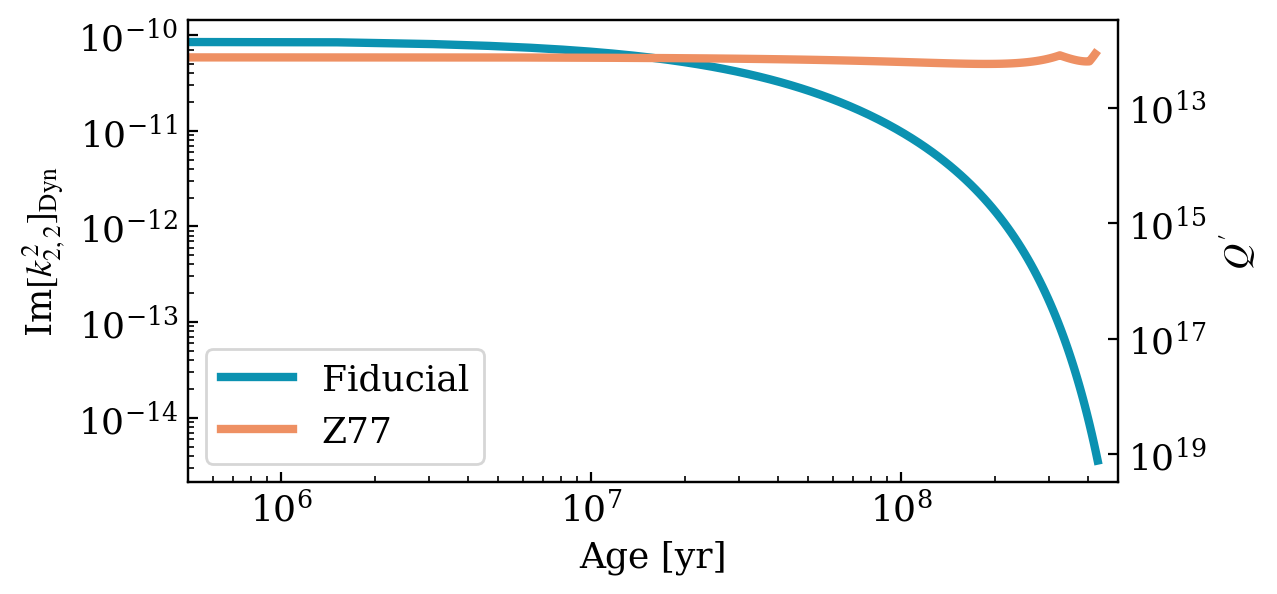

In [145]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

plt.plot(Time, np.abs(Imk22_dyn), c=colorPalette['blue'], lw=3, label=this_work)
plt.plot(Time_zahn, np.abs(Imk22_dyn_zahn), c=colorPalette['orange'], lw=3, label=that_work)


ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))

ax.tick_params(axis='both', which='both', direction='in')


imk_min = 5e-20 # High Mass
imk_max = 5e-12 # High Mass

ax.set_xlim(5e5, 5e8)

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylabel("Im$[k_{2,2}^2 ]_{\\rm Dyn}$")
ax.set_xlabel("Age [yr]")

ax2 = ax.twinx() 
ax2.set_ylim(3/(2*imk_min), 3/(2*imk_max))
ax2.set_yscale('log')
ax2.set_ylabel("$Q'$")
ax2.tick_params(axis='both', which='both', direction='in')


ax.legend(loc='lower left')

plt.savefig(PlotDir+plot_prefix+'imk22_dyn.pdf',dpi=300, bbox_inches='tight')

plt.show()

In [146]:
circ_nan_mask = np.where(np.isnan(tau_circ_inv_dyn) +  + (tau_circ_inv_dyn==0))
tau_circ_inv_dyn[circ_nan_mask] = 0

circ_nan_mask = np.where(np.isnan(tau_circ_inv_zahn_dyn) +  + (tau_circ_inv_zahn_dyn==0))
tau_circ_inv_zahn_dyn[circ_nan_mask] = 0

/var/folders/wj/l7fs8hg555n8nzz7myk9cysw0000gn/T/ipykernel_67353/3454127401.py:1: DeprecationWarning: Applying '+' to a non-numerical array is ill-defined. Returning a copy, but in the future this will error.
  circ_nan_mask = np.where(np.isnan(tau_circ_inv_dyn) +  + (tau_circ_inv_dyn==0))
/var/folders/wj/l7fs8hg555n8nzz7myk9cysw0000gn/T/ipykernel_67353/3454127401.py:4: DeprecationWarning: Applying '+' to a non-numerical array is ill-defined. Returning a copy, but in the future this will error.
  circ_nan_mask = np.where(np.isnan(tau_circ_inv_zahn_dyn) +  + (tau_circ_inv_zahn_dyn==0))


In [147]:
sync_nan_mask = np.where(np.isnan(tau_sync_inv_dyn) + (tau_sync_inv_dyn==0))
tau_sync_inv_dyn[sync_nan_mask] = 0

sync_nan_mask = np.where(np.isnan(tau_sync_inv_zahn_dyn) + (tau_sync_inv_zahn_dyn==0))
tau_sync_inv_zahn_dyn[sync_nan_mask] = 0

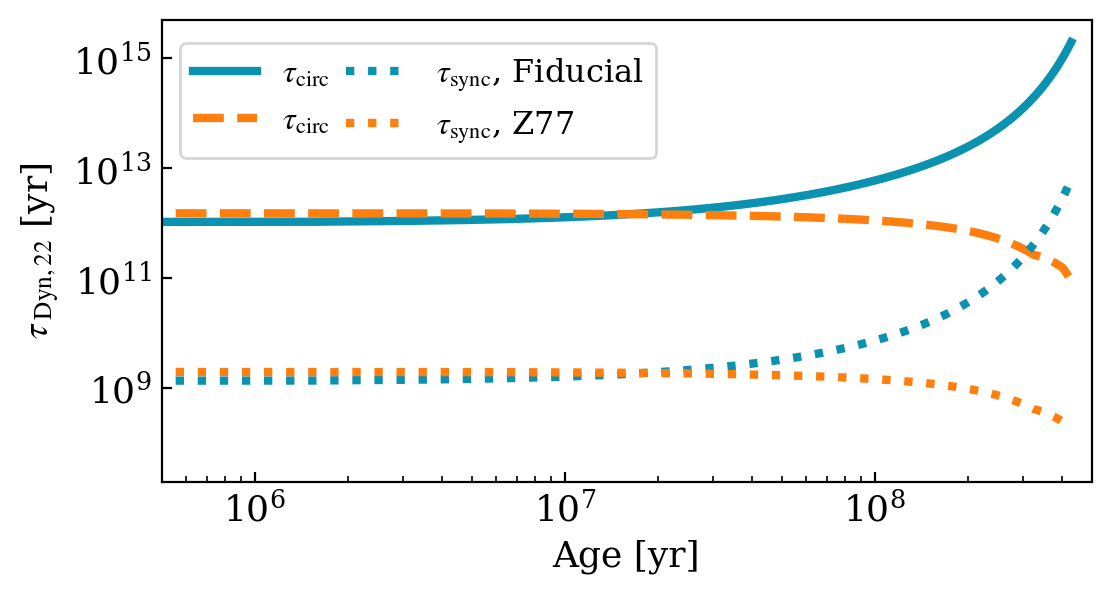

In [149]:
fig, (ax) = plt.subplots(nrows=1, ncols=1, figsize=(6,3))

ax.plot(Time, np.abs(1/tau_circ_inv_dyn_22), c=colorPalette['blue'], lw=3, label="$\\tau_{\\rm circ} \;$")
ax.plot(Time_zahn, np.abs(1/tau_circ_inv_zahn_dyn), c='C1', ls='--', lw=3, label="$\\tau_{\\rm circ} \;$")

ax.plot(Time, np.abs(1/tau_sync_inv_dyn_22), c=colorPalette['blue'], ls=':', lw=3, label="$\\tau_{\\rm sync}$, "+this_work)
ax.plot(Time_zahn, np.abs(1/tau_sync_inv_zahn_dyn), c='C1', ls=':', lw=3, label="$\\tau_{\\rm sync}$, "+that_work)

ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.tick_params(axis='both', which='both', direction='in')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(5e5, 5e8)

ax.set_ylim(2e7, 5e15)


ax.legend(loc=(0.02, 0.7), ncol=2, fancybox=True, fontsize=11.5, columnspacing=0.5)
ax.set_ylabel("$\\tau_{\\rm \; Dyn, 22}$ [yr]")
ax.set_xlabel("Age [yr]")

plt.savefig(PlotDir+plot_prefix+'tau_circ_sync_dyn.pdf',dpi=300, bbox_inches='tight')

plt.show()

### Compare tidal dissipation mechanisms

In [150]:
compare_tides(df_sanity, imk22_core_gw, imk22_env_gw, imk22_inertial, Imk22_eq)


Convective core, NO radiative intershell, convective envelope:
No timesteps found

Convective core, radiative intershell, convective envelope:
No timesteps found

Convective core, radiative envelope:
Timesteps found: 103
Stellar Types found: ['MS_GT_0.7']
*Dynamical tides from convective core - radiative shell boundary: 1.5641540706615935e-09
Dynamical tides from radiative shell - convective envelope boundary: 0.0
Dynamical tides from convective envelope IW dissipation: 0.0
Equilibrium tides from convective envelope: 0

Radiative core, convective envelope:
No timesteps found


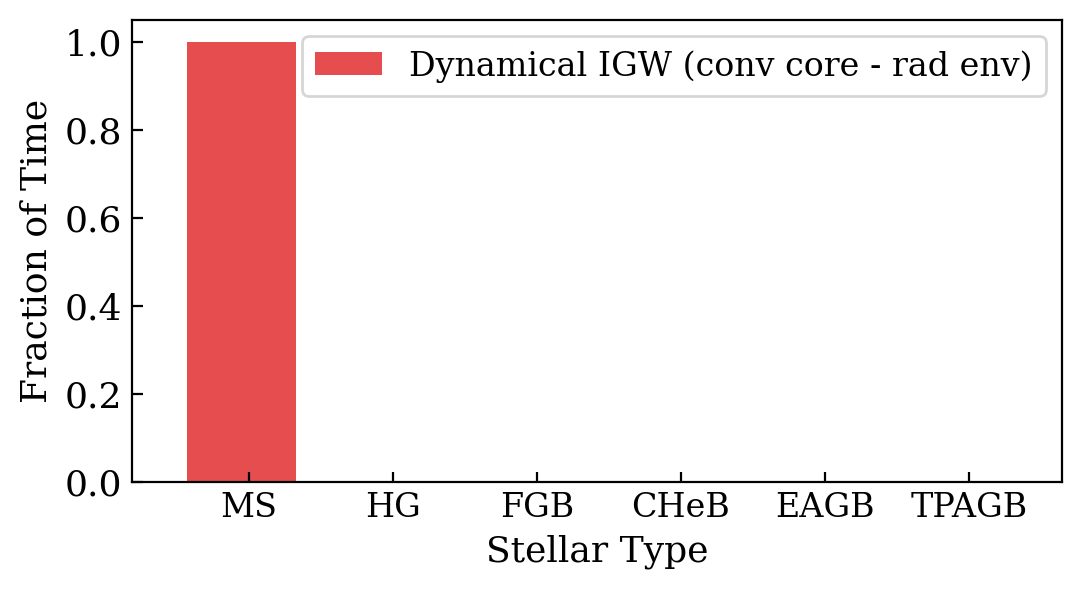

In [151]:
bins = np.linspace(-0.5, len(st_labels_plot)-0.5, len(st_labels_plot))


# Compute the fraction of the final time
total_time = df_sanity["Time"].values[-1] + df_sanity["Dt"].values[-1]

# Compute the sum of Dt for each stellar type
frac_dt_eq = df_sanity.loc[(df_sanity["ImK22_1_eq"] > 0) * (df_sanity["Time"]<800)].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_core = df_sanity.loc[(imk22_core_gw > 0)  * (df_sanity["Time"]<800)].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_env = df_sanity.loc[(imk22_env_gw > 0)  * (df_sanity["Time"]<800)].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_iw = df_sanity.loc[(imk22_inertial > 0 ) * (df_sanity["Time"]<800)].groupby("StellarType_1")["Dt"].sum() / total_time


# Generally group together MS types to make labels smaller
frac_dt_eq.index = frac_dt_eq.index.where(frac_dt_eq.index != 0, 1)
frac_dt_dyn_core.index = frac_dt_dyn_core.index.where(frac_dt_dyn_core.index != 0, 1)
frac_dt_dyn_env.index = frac_dt_dyn_env.index.where(frac_dt_dyn_env.index != 0, 1)
frac_dt_dyn_iw.index = frac_dt_dyn_iw.index.where(frac_dt_dyn_iw.index != 0, 1)

unique_idxs = np.unique(np.concatenate([frac_dt_eq.index.values, frac_dt_dyn_core.index.values, frac_dt_dyn_env.index.values, frac_dt_dyn_iw.index.values]))

# Plot bar chart
fig, ax = plt.subplots(nrows=1, figsize=(6, 3))

for idx in unique_idxs:
    n_bars = ((idx in frac_dt_eq.index) + (idx in frac_dt_dyn_core.index) + (idx in frac_dt_dyn_env.index) + (idx in frac_dt_dyn_iw.index))

    bar_width = 0.8 / n_bars
    offset = -0.05 * (n_bars-1)

    if idx in frac_dt_eq.index:
        ax.bar(idx + offset, frac_dt_eq[idx], alpha=1.0, label="Equilibrium" if idx == frac_dt_eq.index[0] else "", width=bar_width, color=colorPalette['blue'])
        offset += bar_width

    if idx in frac_dt_dyn_core.index:
        ax.bar(idx + offset, frac_dt_dyn_core[idx], alpha=1.0, label="Dynamical IGW (conv core - rad env)" if idx == frac_dt_dyn_core.index[0] else "", width=bar_width, color=colorPalette['red'])
        offset += bar_width

    if idx in frac_dt_dyn_env.index:
        ax.bar(idx + offset, frac_dt_dyn_env[idx], alpha=1.0, label="Dynamical IGW (rad core - conv env)" if idx == frac_dt_dyn_env.index[0] else "", width=bar_width, color=colorPalette['orange'])
        offset += bar_width

    if idx in frac_dt_dyn_iw.index:
        ax.bar(idx + offset, frac_dt_dyn_iw[idx], alpha=1.0, label="Dynamical IW" if idx == frac_dt_dyn_iw.index[0] else "", width=bar_width, color=colorPalette['violet'])

# Set x-axis labels to the stellar types
ax.set_xticks(bins+0.5, labels=st_labels_plot, rotation=0, fontsize=12)
ax.tick_params(axis='y', size=10)

ax.set_xlabel('Stellar Type')

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='y', length=4)

ax.set_xlim(0.2, len(st_labels_plot)-13)
ax.set_ylabel("Fraction of Time")
# ax.set_yscale('log')


ax.legend(fontsize=12)

plt.savefig(PlotDir+plot_prefix+'tides_type.pdf',dpi=300, bbox_inches='tight')
plt.show()

## High Mass AGB (Figure 9)

For the Fiducial simulation, change `TIDES_MAXIMUM_ORBITAL_CHANGE_FRAC` to the following value in COMPAS/src/constants.h:

`constexpr double TIDES_MAXIMUM_ORBITAL_CHANGE_FRAC      = 0.0001;  `

This is only required to avoid numerical artifacts Figure 9(c) and 9(d), particularly in the synchronized region. The outcomes remain the same.

COMPAS --number-of-systems 1 --random-seed 1 --output-path sim_data --output-container high_mass_agb --initial-mass-1 3 --initial-mass-2 3 --orbital-period 5000 --eccentricity 0.5 --chemically-homogeneous-evolution-mode NONE --tides-prescription KAPIL2026 --maximum-number-timestep-iterations 1999999

COMPAS --number-of-systems 1 --random-seed 1 --output-path sim_data --output-container high_mass_agb_z77 --initial-mass-1 3 --initial-mass-2 3 --orbital-period 5000 --eccentricity 0.5 --chemically-homogeneous-evolution-mode NONE --tides-prescription ZAHN1977 

In [9]:
plot_prefix = 'high_mass_agb_'

In [10]:
DataPath = 'sim_data/high_mass_agb'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())
pd.options.display.max_columns = None

df_sanity

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1,0.000000,0.003627,1,1,64.4707,64.4707,64.4707,64.4707,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.458987,0.458987,0.0000,0.0000,0.0000,0.0000,5.000000e-01,5.000000e-01,3.000000,1.886670,2.309440e-05,2.309440e-05,3.000000,1.886670,2.309440e-05,2.309440e-05,10.3985,10.3985,7.505620e-20,7.505620e-20,7.505620e-20,7.505620e-20,4.765770e-19,4.765770e-19,1.405110e-18,1.405110e-18,7.505620e-20,7.505620e-20,7.505620e-20,7.505620e-20,4.765770e-19,4.765770e-19,1.405110e-18,1.405110e-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.696895,0.322866,0.696895,0.322866,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,86.4071,86.4071,2.21968,2.21968,-3.889660e-32,-3.889660e-32,3.975630e-27,3.975630e-27,-1.238860e-33,-1.238860e-33,2.673370e+22,4.035980e+22,1.154500e+16,1.154500e+16,-2.665960e-09,-2.665960e-09,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.604990e-20,4.604990e-20,4.604990e-20,4.604990e-20,2.923990e-19,2.923990e-19,8.620900e-19,8.620900e-19,-2.386460e-32,-2.386460e-32,-7.600880e-34,-7.600880e-34,2.439210e-27,2.439210e-27
1,1,0.003627,3.626770,1,1,64.4707,64.4707,64.4707,64.4707,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.458986,0.458986,0.0000,0.0000,0.0000,0.0000,5.000000e-01,5.000000e-01,3.000000,1.886680,2.309450e-05,2.309450e-05,3.000000,1.886680,2.309450e-05,2.309450e-05,10.3985,10.3985,7.504920e-20,7.504920e-20,7.504920e-20,7.504920e-20,4.765330e-19,4.765330e-19,1.404980e-18,1.404980e-18,7.504920e-20,7.504920e-20,7.504920e-20,7.504920e-20,4.765330e-19,4.765330e-19,1.404980e-18,1.404980e-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.696892,0.322864,0.696892,0.322864,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,86.4072,86.4072,2.21967,2.21967,-3.889370e-32,-3.889370e-32,3.975290e-27,3.975290e-27,-1.238760e-33,-1.238760e-33,2.673570e+22,4.036290e+22,1.154600e+16,1.154600e+16,-2.665980e-06,-2.665980e-06,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.605050e-20,4.605050e-20,4.605050e-20,4.605050e-20,2.924020e-19,2.924020e-19,8.621000e-19,8.621000e-19,-2.386530e-32,-2.386530e-32,-7.601090e-34,-7.601090e-34,2.439250e-27,2.439250e-27
2,1,3.630390,3.626780,1,1,64.4706,64.4706,64.4706,64.4706,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.458985,0.458985,0.0000,0.0000,0.0000,0.0000,5.000000e-01,5.000000e-01,2.999990,1.896060,2.332480e-05,2.332480e-05,2.999990,1.896060,2.332480e-05,2.332480e-05,10.3985,10.3985,6.893230e-20,6.893230e-20,6.893230e-20,6.893230e-20,4.376930e-19,4.376930e-19,1.290460e-18,1.290460e-18,6.893230e-20,6.893230e-20,6.893230e-20,6.893230e-20,4.376930e-19,4.376930e-19,1.290460e-18,1.290460e-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.694103,0.320520,0.694103,0.320520,0.000000,0.000000,0

In [11]:
DataPath_Zahn = 'sim_data/high_mass_agb_z77'
df_sanity_zahn = pd.read_csv(DataPath_Zahn+'/sanity_checks.csv')
df_sanity_zahn = df_sanity_zahn.rename(columns=lambda x: x.strip())
df_sanity_zahn

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1,0.000000,0.003627,1,1,64.4707,64.4707,64.4707,64.4707,0.000000e+00,2.043030e-28,0.000000e+00,2.043030e-28,0.458987,0.458987,0.000000e+00,8.846430e-24,0.000000e+00,8.846430e-24,0.500000,0.500000,3.000000,1.886670,2.309440e-05,2.309440e-05,3.000000,1.886670,2.309440e-05,2.309440e-05,10.3985,10.3985,7.505620e-20,7.505620e-20,7.505620e-20,7.505620e-20,4.765770e-19,4.765770e-19,1.405110e-18,1.405110e-18,7.505620e-20,7.505620e-20,7.505620e-20,7.505620e-20,4.765770e-19,4.765770e-19,1.405110e-18,1.405110e-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.696895,0.322866,0.696895,0.322866,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,86.4071,86.4071,2.21968,2.21968,-3.889660e-32,-3.889660e-32,3.975630e-27,3.975630e-27,-1.238860e-33,-1.238860e-33,2.673370e+22,4.035980e+22,1.154500e+16,1.154500e+16,-2.665960e-09,-2.665960e-09,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.604990e-20,4.604990e-20,4.604990e-20,4.604990e-20,2.923990e-19,2.923990e-19,8.620900e-19,8.620900e-19,-2.386460e-32,-2.386460e-32,-7.600880e-34,-7.600880e-34,2.439210e-27,2.439210e-27
1,1,0.003627,3.626770,1,1,64.4707,64.4707,64.4707,64.4707,2.043020e-28,2.045130e-25,2.043020e-28,2.045130e-25,0.458986,0.458986,8.846310e-24,8.855450e-21,8.846310e-24,8.855450e-21,0.500000,0.500000,3.000000,1.886680,2.309450e-05,2.309450e-05,3.000000,1.886680,2.309450e-05,2.309450e-05,10.3985,10.3985,7.504920e-20,7.504920e-20,7.504920e-20,7.504920e-20,4.765330e-19,4.765330e-19,1.404980e-18,1.404980e-18,7.504920e-20,7.504920e-20,7.504920e-20,7.504920e-20,4.765330e-19,4.765330e-19,1.404980e-18,1.404980e-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.696892,0.322864,0.696892,0.322864,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,86.4072,86.4072,2.21967,2.21967,-3.889370e-32,-3.889370e-32,3.975290e-27,3.975290e-27,-1.238760e-33,-1.238760e-33,2.673570e+22,4.036290e+22,1.154600e+16,1.154600e+16,-2.665980e-06,-2.665980e-06,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.605050e-20,4.605050e-20,4.605050e-20,4.605050e-20,2.924020e-19,2.924020e-19,8.621000e-19,8.621000e-19,-2.386530e-32,-2.386530e-32,-7.601090e-34,-7.601090e-34,2.439250e-27,2.439250e-27
2,1,3.630390,3.626780,1,1,64.4706,64.4706,64.4706,64.4706,2.045110e-25,4.181440e-25,2.045110e-25,4.181440e-25,0.458985,0.458985,8.767990e-21,1.792710e-20,8.767990e-21,1.792710e-20,0.500000,0.500000,2.999990,1.896060,2.332480e-05,2.332480e-05,2.999990,1.896060,2.332480e-05,2.332480e-05,10.3985,10.3985,6.893230e-20,6.893230e-20,6.893230e-20,6.893230e-20,4.376930e-19,4.376930e-19,1.290460e-18,1.290460e-18,6.893230e-20,6.893230e-20,6.893230e-20,6.893230e-20,4.376930e-19,4.376930e-19,1.290460e-18,1.290460e-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.69410

In [12]:
rc = df_sanity["R1_core"].values * u.R_sun              # Rsol
R = df_sanity["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

rc2 = df_sanity["R2_core"].values * u.R_sun              # Rsol
R2 = df_sanity["R2"].values * u.R_sun                    # Rsol
Renv2 = df_sanity["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2 = R2 - Renv2

L = df_sanity["Lum_1"].values * u.L_sun                 # Lsol
L2 = df_sanity["Lum_2"].values * u.L_sun                 # Lsol

M = df_sanity["M1"].values * u.M_sun                    # Msol
Mc = df_sanity["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity["M2"].values * u.M_sun                   # Msol
Mc2 = df_sanity["M2_core"].values * u.M_sun              # Msol
Menv2 = df_sanity["M2_conv_env"].values * u.M_sun        # Msol


I1 = df_sanity["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity["tau_conv1"].values * u.yr                # yr
tau_conv2 = df_sanity["tau_conv2"].values * u.yr                # yr


omega_orb = df_sanity["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity["Omega1_before"].values / u.yr   # 1/yr
omega_spin2 = df_sanity["Omega2_before"].values / u.yr   # 1/yr

sma = df_sanity["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity["ecc_before"].values                           # 1
period_orb = 2 * np.pi / df_sanity["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk10 = df_sanity["ImK10_1"].values
Imk12 = df_sanity["ImK12_1"].values
Imk22 = df_sanity["ImK22_1"].values
Imk32 = df_sanity["ImK32_1"].values

Imk10_dyn = df_sanity["ImK10_1_dyn"].values
Imk12_dyn = df_sanity["ImK12_1_dyn"].values
Imk22_dyn = df_sanity["ImK22_1_dyn"].values
Imk32_dyn = df_sanity["ImK32_1_dyn"].values

Imk10_eq = df_sanity["ImK10_1_eq"].values
Imk12_eq = df_sanity["ImK12_1_eq"].values
Imk22_eq = df_sanity["ImK22_1_eq"].values
Imk32_eq = df_sanity["ImK32_1_eq"].values

Imk10_2 = df_sanity["ImK10_2"].values
Imk12_2 = df_sanity["ImK12_2"].values
Imk22_2 = df_sanity["ImK22_2"].values
Imk32_2 = df_sanity["ImK32_2"].values

Imk10_2_dyn = df_sanity["ImK10_2_dyn"].values
Imk12_2_dyn = df_sanity["ImK12_2_dyn"].values
Imk22_2_dyn = df_sanity["ImK22_2_dyn"].values
Imk32_2_dyn = df_sanity["ImK32_2_dyn"].values

Imk10_2_eq = df_sanity["ImK10_2_eq"].values
Imk12_2_eq = df_sanity["ImK12_2_eq"].values
Imk22_2_eq = df_sanity["ImK22_2_eq"].values
Imk32_2_eq = df_sanity["ImK32_2_eq"].values

dadt = df_sanity["dadt1"].values * u.AU / u.yr
dOmegadt = df_sanity["dOmegadt1"].values / u.yr**2
dedt1 = df_sanity["dedt1"].values / u.yr


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity["StellarType_1"].values
st2 = df_sanity["StellarType_2"].values

rc_AU = df_sanity["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     


rc_AU2 = df_sanity["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2 = df_sanity["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2 = df_sanity["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2 = R_AU2 - Renv_AU2                 
Mint2 = M2 - Mc2 - Menv2    

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [13]:
rc_zahn = df_sanity_zahn["R1_core"].values * u.R_sun              # Rsol
R_zahn = df_sanity_zahn["R1"].values * u.R_sun                    # Rsol
Renv_zahn = df_sanity_zahn["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint_zahn = R_zahn - Renv_zahn

rc2_zahn = df_sanity_zahn["R2_core"].values * u.R_sun              # Rsol
R2_zahn = df_sanity_zahn["R2"].values * u.R_sun                    # Rsol
Renv2_zahn = df_sanity_zahn["R2_conv_env_extent"].values * u.R_sun # Rsol
Rint2_zahn = R2_zahn - Renv2_zahn

L_zahn = df_sanity_zahn["Lum_1"].values * u.L_sun                 # Lsol
L2_zahn = df_sanity_zahn["Lum_2"].values * u.L_sun                 # Lsol

M_zahn = df_sanity_zahn["M1"].values * u.M_sun                    # Msol
Mc_zahn = df_sanity_zahn["M1_core"].values * u.M_sun              # Msol
Menv_zahn = df_sanity_zahn["M1_conv_env"].values * u.M_sun        # Msol

M2_zahn = df_sanity_zahn["M2"].values * u.M_sun                   # Msol
Mc2_zahn = df_sanity_zahn["M2_core"].values * u.M_sun              # Msol
Menv2_zahn = df_sanity_zahn["M2_conv_env"].values * u.M_sun        # Msol


I1_zahn = df_sanity_zahn["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv_zahn = df_sanity_zahn["tau_conv1"].values * u.yr                # yr
tau_conv2_zahn = df_sanity_zahn["tau_conv2"].values * u.yr                # yr


omega_orb_zahn = df_sanity_zahn["Omega_before"].values / u.yr     # 1/yr
omega_spin_zahn = df_sanity_zahn["Omega1_before"].values / u.yr   # 1/yr
omega_spin2_zahn = df_sanity_zahn["Omega2_before"].values / u.yr   # 1/yr

sma_zahn = df_sanity_zahn["SemiMajorAxis_before"].values * u.AU   # AU
ecc_zahn = df_sanity_zahn["ecc_before"].values                           # 1
period_orb_zahn = 2 * np.pi / df_sanity_zahn["Omega_before"].values * u.yr.to(u.day) * u.day     # days

Imk22_dyn_zahn = df_sanity_zahn["ImK22_Zahn_Dynamical1"].values
Imk22_eq_zahn = df_sanity_zahn["ImK22_Zahn_Equilibrium1"].values
Imk22_zahn = Imk22_dyn_zahn + Imk22_eq_zahn

Imk22_2_dyn_zahn = df_sanity_zahn["ImK22_Zahn_Dynamical2"].values
Imk22_2_eq_zahn = df_sanity_zahn["ImK22_Zahn_Equilibrium2"].values
Imk22_2_zahn = Imk22_2_dyn_zahn + Imk22_2_eq_zahn


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time_zahn = df_sanity_zahn["Time"].values * 1e6 * u.yr          # yr
st1_zahn = df_sanity_zahn["StellarType_1"].values
st2_zahn = df_sanity_zahn["StellarType_2"].values

rc_AU_zahn = df_sanity_zahn["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU_zahn = df_sanity_zahn["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU_zahn = df_sanity_zahn["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU_zahn = R_AU_zahn - Renv_AU_zahn
Mint_zahn = M_zahn - Mc_zahn - Menv_zahn


rc_AU2_zahn = df_sanity_zahn["R2_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU2_zahn = df_sanity_zahn["R2_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU2_zahn = df_sanity_zahn["R2"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU2_zahn = R_AU2_zahn - Renv_AU2_zahn
Mint2_zahn = M2_zahn - Mc2_zahn - Menv2_zahn

st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

In [14]:
print([st_labels[st1_idx] for st1_idx in np.unique(st1)])

hg_idx = np.where(st1==2)[0][0]
hg_time = Time[hg_idx].value
print(hg_time)

gb_idx = np.where(st1>=3)[0][0]
gb_time = Time[gb_idx].value
print(gb_time)

cheb_idx = np.where(st1>=4)[0][0]
cheb_time = Time[cheb_idx].value
print(cheb_time)

eagb_idx = np.where(st1>=5)[0][0]
eagb_time = Time[eagb_idx].value
print(eagb_time)

tpagb_idx = np.where(st1==6)[0][0]
tpagb_time = Time[tpagb_idx].value
print(tpagb_time)

wd_idx = np.where(st1==11)[0][0]
wd_time = Time[wd_idx].value
print(wd_time)

['MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'COWD']
362755000.0
364980000.0
367143000.0
453234000.0
456263000.0
457359000.0


In [15]:
print([st_labels[st1_idx_zahn] for st1_idx_zahn in np.unique(st1_zahn)])
hg_idx_zahn = np.where(st1_zahn==2)[0][0]
hg_time_zahn = Time_zahn[hg_idx_zahn].value
print(hg_time_zahn)

gb_idx_zahn = np.where(st1_zahn==3)[0][0]
gb_time_zahn = Time_zahn[gb_idx_zahn].value
print(gb_time_zahn)

cheb_idx_zahn = np.where(st1_zahn==4)[0][0]
cheb_time_zahn = Time_zahn[cheb_idx_zahn].value
print(cheb_time_zahn)

eagb_idx_zahn = np.where(st1_zahn==5)[0][0]
eagb_time_zahn = Time_zahn[eagb_idx_zahn].value
print(eagb_time_zahn)

tpagb_idx_zahn = np.where(st1_zahn==6)[0][0]
tpagb_time_zahn = Time_zahn[tpagb_idx_zahn].value
print(tpagb_time_zahn)

wd_idx_zahn = np.where(st1_zahn==11)[0][0]
wd_time_zahn = Time_zahn[wd_idx_zahn].value
print(wd_time_zahn)

['MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'COWD']
362755000.0
364980000.0
367143000.0
453234000.0
456269000.0
457369000.0


### Stellar Evolution

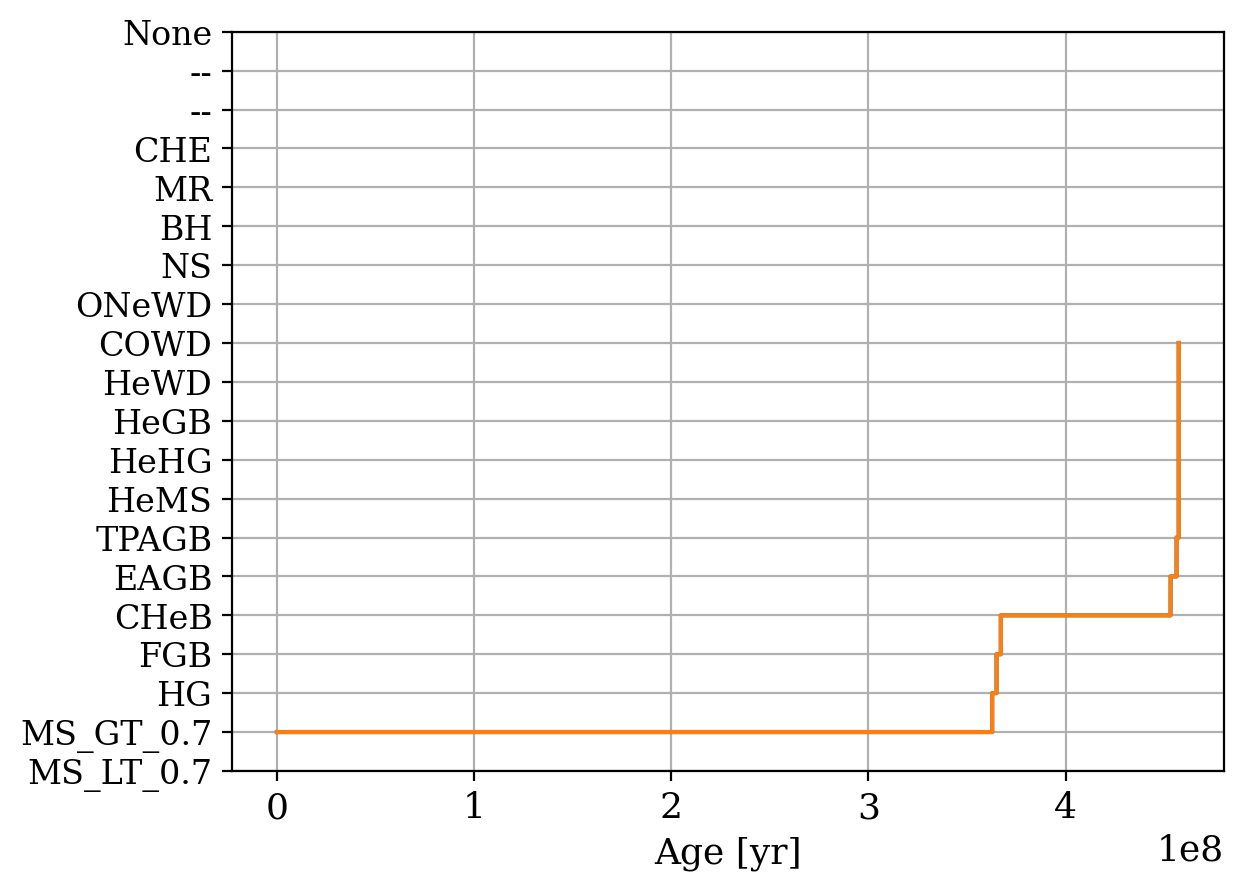

In [16]:
plt.plot(Time, st1)
plt.plot(Time_zahn, st1_zahn)
y_ticks=np.linspace(0, 19, 20)
plt.yticks(y_ticks, st_labels, fontsize=12)

plt.xlabel("Age [yr]")
plt.grid()
plt.show()

### Stellar Structure

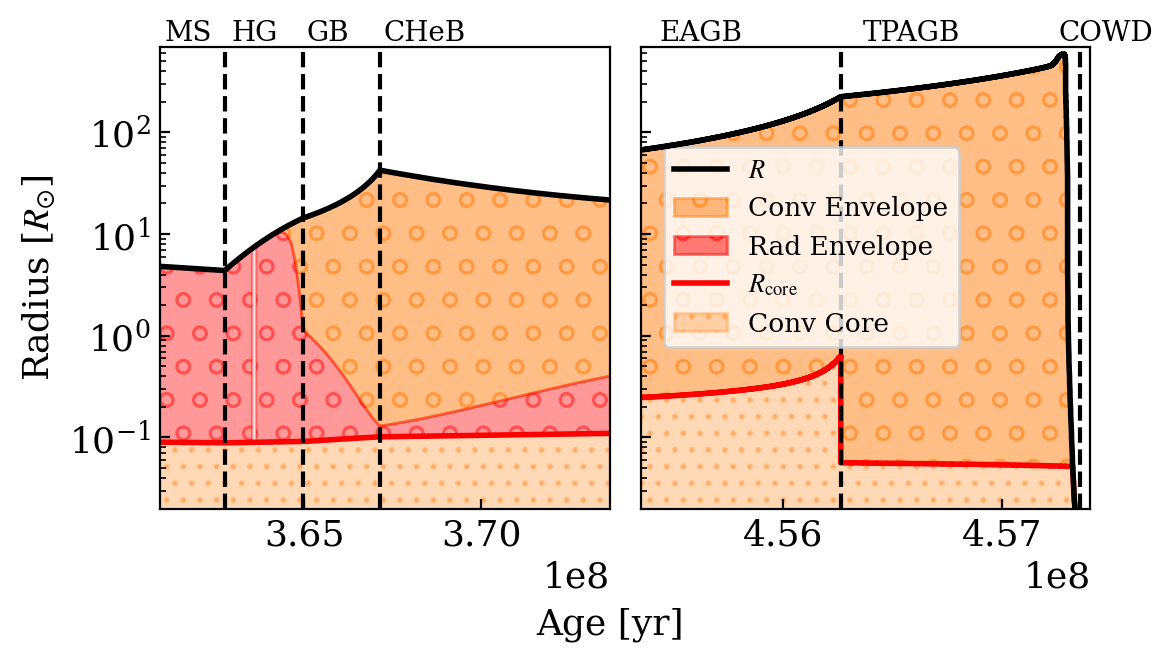

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6,3), sharey=True)

for ax in axes:
    ax.plot(Time, R, c='k', zorder=10, lw=2, label="$R$")


    if any(Renv/R > frac_limit):
        mask = (Renv/R > frac_limit)
        ax.fill_between(Time.value[mask], R.value[mask], (R-Renv).value[mask], color='C1', alpha=0.5, hatch="o", label="Conv Envelope")

    if any((R-rc)/R > frac_limit) and any(Renv/R < frac_limit):
        mask = ((R-rc)/R > frac_limit) & (Renv/R < frac_limit) & (st1>=8)
        ax.fill_between(Time.value[mask], rc.value[mask], R.value[mask], color='r', alpha=0.5, hatch="o", label="Rad Envelope")


    if any(Rint<R) and any(Rint>rc):
        mask = (Renv/R > frac_limit) 
        ax.fill_between(Time.value[mask], rc.value[mask], Rint.value[mask], color='r', alpha=0.4, hatch="o")

        # Patch the empty whitespace in the plot right after MS
        idx = np.where(st1<=1)[0][-1]+9
        ax.fill_between(Time.value[:idx], rc.value[:idx], R.value[:idx], color='r', alpha=0.4, hatch="o")

    if any(rc/R > frac_limit):
        ax.plot(Time.value, rc.value, lw=2, c='r', label='$R_{\\rm core}$') 
        ax.fill_between(Time.value, 0, rc.value, color='C1', alpha=0.3, hatch="..", label="Conv Core")


    elif any((R-Renv)/R > frac_limit):
        ax.fill_between(Time.value, 0, (R-Renv).value, color='r', alpha=0.3, hatch="..", label="Rad Core")
        ax.plot(Time.value, (R-Renv).value, lw=2, c='r', label='$R_{\\rm core}$') 

    ax.plot(Time.value, np.zeros(len(Time)), lw=2, c='k')

    ax.set_yscale('log')

    ax.set_ylim(2e-2, 7e2)
    ax.tick_params(axis='both', which='both', direction='in')

ax = axes[0]
ax.set_xlim(0.995*hg_time, 1.03*hg_time) # HG Mass
ax.text(Time[hg_idx].value-1.7e6, 8e2, s="MS", fontsize=10) # HG Mass
ax.axvline(Time[hg_idx].value, c='k', ls='--')
ax.text(Time[hg_idx].value+2e5, 8e2, s="HG", fontsize=10) # HG Mass
ax.axvline(Time[gb_idx].value, c='k', ls='--')
ax.text(Time[gb_idx].value+9e4, 8e2, s="GB", fontsize=10)# HG Mass
ax.axvline(Time[cheb_idx].value, c='k', ls='--')
ax.text(Time[cheb_idx].value+1e5, 8e2, s="CHeB", fontsize=10)# HG Mass

ax.set_ylabel("Radius [$R_{\odot}$]")

# Stellar Type (box 2)
ax = axes[1]
ax.set_xlim(0.998*tpagb_time, 1.0001*Time[-1].value) # HG Mass
ax.text(Time[eagb_idx].value+2.2e6, 8e2, s="EAGB", fontsize=10)# HG Mass
# ax.axvline(Time[eagb_idx].value, c='k', ls='--')
ax.text(Time[tpagb_idx].value+1e5, 8e2, s="TPAGB", fontsize=10)# HG Mass
ax.axvline(Time[tpagb_idx].value, c='k', ls='--')
ax.text(Time[wd_idx].value-1e5, 8e2, s="COWD", fontsize=10)# HG Mass
ax.axvline(Time[wd_idx].value, c='k', ls='--')

ax.legend(loc=(0.05, 0.35), fontsize=9.5)

fig.text(0.5, -0.1, 'Age [yr]', ha='center')
plt.subplots_adjust(wspace=0.07, hspace=0)

plt.savefig(PlotDir+plot_prefix+'stellar_structure.png',dpi=300, bbox_inches='tight')

plt.show()

### Orbital Properties

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


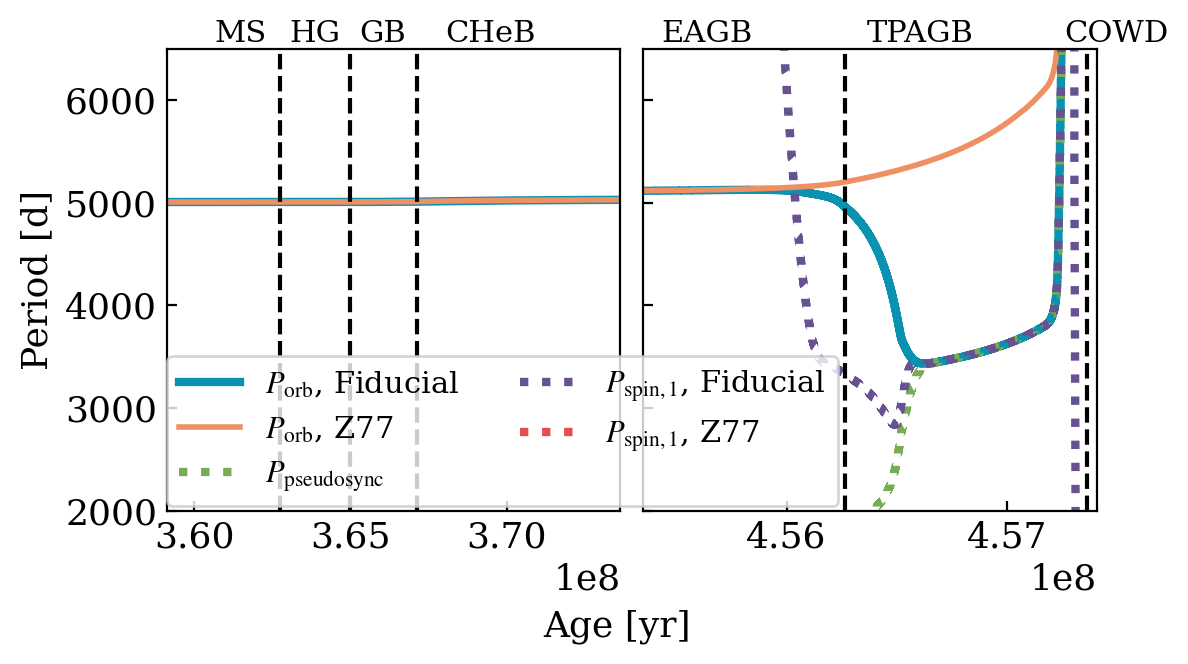

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6,3), sharey=True)

for ax in axes:
    ax.plot(Time, period_orb, c=colorPalette['blue'], lw=3, label='$P_{\\rm orb}$, '+this_work)
    ax.plot(Time_zahn, period_orb_zahn, lw=2, c=colorPalette['orange'], ls='-', label='$P_{\\rm orb}$, '+that_work)
    

    omega_pseudosync = (1 + (15/2)*ecc**2 + (45/8)*ecc**4 + (5/16)*ecc**6)/ ((1 + 3*ecc**2 + (3/8)*ecc**4)*(1-ecc**2)**(3/2)) * omega_orb
    period_pseudosync = 2 * np.pi / omega_pseudosync.to(1/u.day)     # days
    ax.plot(Time, period_pseudosync, lw=3, c=colorPalette['green'], ls=':', label="$P_{\\rm pseudosync}$")
        

    period_spin = 2 * np.pi / omega_spin.to(1/u.day)     # days
    period_spin_zahn = 2 * np.pi / omega_spin_zahn.to(1/u.day)     # days

    ax.plot(Time[::10], period_spin[::10], lw=3, c=colorPalette['violet'], ls=':', label='$P_{\\rm spin, 1}$, '+this_work)
    ax.plot(Time_zahn[::10], period_spin_zahn[::10], lw=3, c=colorPalette['red'], ls=':', label='$P_{\\rm spin, 1}$, '+that_work)

    ymax = 6500
    ax.set_ylim(2000, ymax)


ax = axes[0]
# # Stellar Type
ax.text(Time[hg_idx].value-2.1e6, 1.01*ymax, s="MS", fontsize=11) # HG Mass
ax.axvline(Time[hg_idx].value, c='k', ls='--')
ax.text(Time[hg_idx].value+3e5, 1.01*ymax, s="HG", fontsize=11) # HG Mass
ax.axvline(Time[gb_idx].value, c='k', ls='--')
ax.text(Time[gb_idx].value+3e5, 1.01*ymax, s="GB", fontsize=11) # HG Mass
ax.axvline(Time[cheb_idx].value, c='k', ls='--')
ax.text(Time[cheb_idx].value+9e5, 1.01*ymax, s="CHeB", fontsize=11)# HG Mass

ax.set_xlim(0.99*hg_time, 1.03*hg_time) # HG Mass
ax.tick_params(axis='both', which='both', direction='in')
ax.set_ylabel("Period [d]")


ax = axes[1]
ax.text(Time[eagb_idx].value+2.2e6, 1.01*ymax, s="EAGB", fontsize=11)# HG Mass
# ax.axvline(Time[eagb_idx].value, c='k', ls='--')
ax.text(Time[tpagb_idx].value+1e5, 1.01*ymax, s="TPAGB", fontsize=11)# HG Mass
ax.axvline(Time[tpagb_idx].value, c='k', ls='--')
ax.text(Time[wd_idx].value-1e5, 1.01*ymax, s="COWD", fontsize=11)# HG Mass
ax.axvline(Time[wd_idx].value, c='k', ls='--')


ax.set_xlim(0.998*tpagb_time, 1.0001*Time[-1].value) # HG Mass
ax.legend(fontsize=11, loc=(-1.05, 0.01), ncols=2)
ax.tick_params(axis='both', which='both', direction='in')

fig.text(0.5, -0.1, 'Age [yr]', ha='center')
plt.subplots_adjust(wspace=0.05, hspace=0)
plt.savefig(PlotDir+plot_prefix+'period_evolution.pdf',dpi=300, bbox_inches='tight')

plt.show()

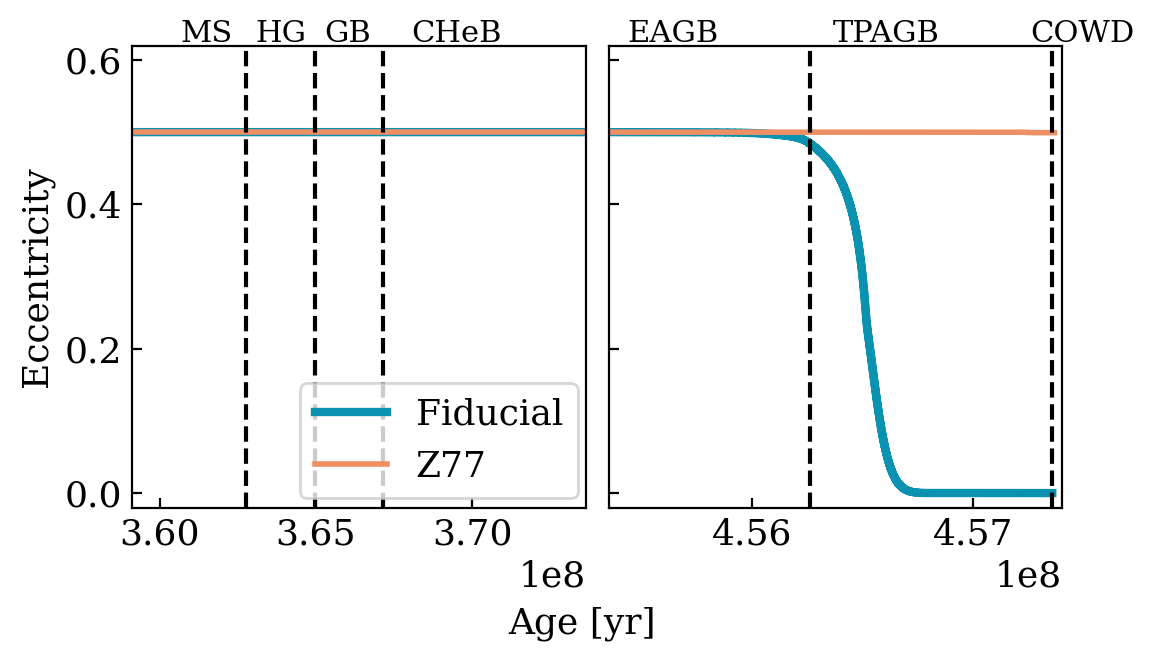

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6,3), sharey=True)


for ax in axes:
    ax.plot(Time, ecc, c=colorPalette['blue'], lw=3, label=this_work)
    ax.plot(Time_zahn, ecc_zahn, lw=2, c=colorPalette['orange'], label=that_work)
    ax.set_ylim(-0.02, 0.62)
    ax.tick_params(axis='both', which='both', direction='in')



ax = axes[0]
# # Stellar Type
ax.text(Time[hg_idx].value-2.1e6, 0.625, s="MS", fontsize=11) # HG Mass
ax.axvline(Time[hg_idx].value, c='k', ls='--')
ax.text(Time[hg_idx].value+3e5, 0.625, s="HG", fontsize=11) # HG Mass
ax.axvline(Time[gb_idx].value, c='k', ls='--')
ax.text(Time[gb_idx].value+3e5, 0.625, s="GB", fontsize=11) # HG Mass
ax.axvline(Time[cheb_idx].value, c='k', ls='--')
ax.text(Time[cheb_idx].value+9e5, 0.625, s="CHeB", fontsize=11)# HG Mass

ax.set_xlim(0.99*hg_time, 1.03*hg_time) # HG Mass
# ax.set_xlabel("Age [yr]")
ax.set_ylabel("Eccentricity")
ax.legend(loc=(0.37, 0.02))


ax = axes[1]
ax.text(Time[eagb_idx].value+2.2e6, 0.625, s="EAGB", fontsize=11)# HG Mass
# ax.axvline(Time[eagb_idx].value, c='k', ls='--')
ax.text(Time[tpagb_idx].value+1e5, 0.625, s="TPAGB", fontsize=11)# HG Mass
ax.axvline(Time[tpagb_idx].value, c='k', ls='--')
ax.text(Time[wd_idx].value-1e5, 0.625, s="COWD", fontsize=11)# HG Mass
ax.axvline(Time[wd_idx].value, c='k', ls='--')

ax.set_xlim(0.998*tpagb_time, 1.0001*Time[-1].value) # HG Mass

fig.text(0.5, -0.1, 'Age [yr]', ha='center')
plt.subplots_adjust(wspace=0.05, hspace=0)
plt.savefig(PlotDir+plot_prefix+'ecc_evolution.pdf',dpi=300, bbox_inches='tight')

plt.show()

### Equilibrium Tides

#### Fiducial

In [23]:
dedt1_eq = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*Imk10_eq/2) - (Imk12_eq/4) - Imk22_eq + (49*Imk32_eq/4))
tau_circ_inv_eq = - dedt1_eq / ecc
1/tau_circ_inv_eq

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [inf, inf, inf, ..., inf, inf, inf] yr>

In [24]:
dedt1_eq_22 = -(3/4) * (1/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- Imk22_eq)
tau_circ_inv_eq_22 = -dedt1_eq_22
(1/tau_circ_inv_eq_22[cheb_idx-1:])

<Quantity [-5.22661036e+12, -5.19893483e+12, -5.22611706e+12, ...,
                      -inf,            -inf,            -inf] yr>

In [25]:
dOmegadt1_eq = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_eq + ecc**2 * ((Imk12_eq/4) - (5*Imk22_eq) + (49*Imk32_eq/4)))
tau_sync_inv_eq = - dOmegadt1_eq / (omega_spin - omega_orb)
(1/tau_sync_inv_eq)[cheb_idx-1:]

<Quantity [44779789.31456441, 44603171.52978756, 44772082.4382859 , ...,
                        -inf,              -inf,              -inf] yr>

In [26]:
dOmegadt1_eq_22 = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_eq)
tau_sync_inv_eq_22 = - dOmegadt1_eq_22 / (omega_spin - omega_orb)
1/tau_sync_inv_eq_22

<Quantity [ inf,  inf,  inf, ..., -inf, -inf, -inf] yr>

#### Z77

In [27]:
dedt1_eq_22 = -(3/4) * (1/omega_orb_zahn) * ((M_zahn + M2_zahn)/M_zahn) * (G_AU_Msol_yr*M2_zahn / R_AU_zahn**3) * (R_AU_zahn/sma_zahn)**8 * (- Imk22_eq_zahn)
tau_circ_inv_zahn_eq = -dedt1_eq_22
1/tau_circ_inv_zahn_eq

<Quantity [-inf, -inf, -inf, ...,   0.,   0., -inf] yr>

In [28]:
dOmegadt1_eq_22 = (3/2) * (1/I1_zahn) * (G_AU_Msol_yr*M2_zahn*M2_zahn / R_AU_zahn) * (R_AU_zahn/sma_zahn)**6 * (Imk22_eq_zahn)
tau_sync_inv_zahn_eq = - dOmegadt1_eq_22 / (omega_spin_zahn - omega_orb_zahn)
1/tau_sync_inv_zahn_eq

<Quantity [ inf,  inf,  inf, ...,   0.,   0., -inf] yr>

#### Plots

In [29]:
Imk22_eq[0] = Imk22_eq[1]
Imk22_eq_zahn[0] = Imk22_eq_zahn[1]

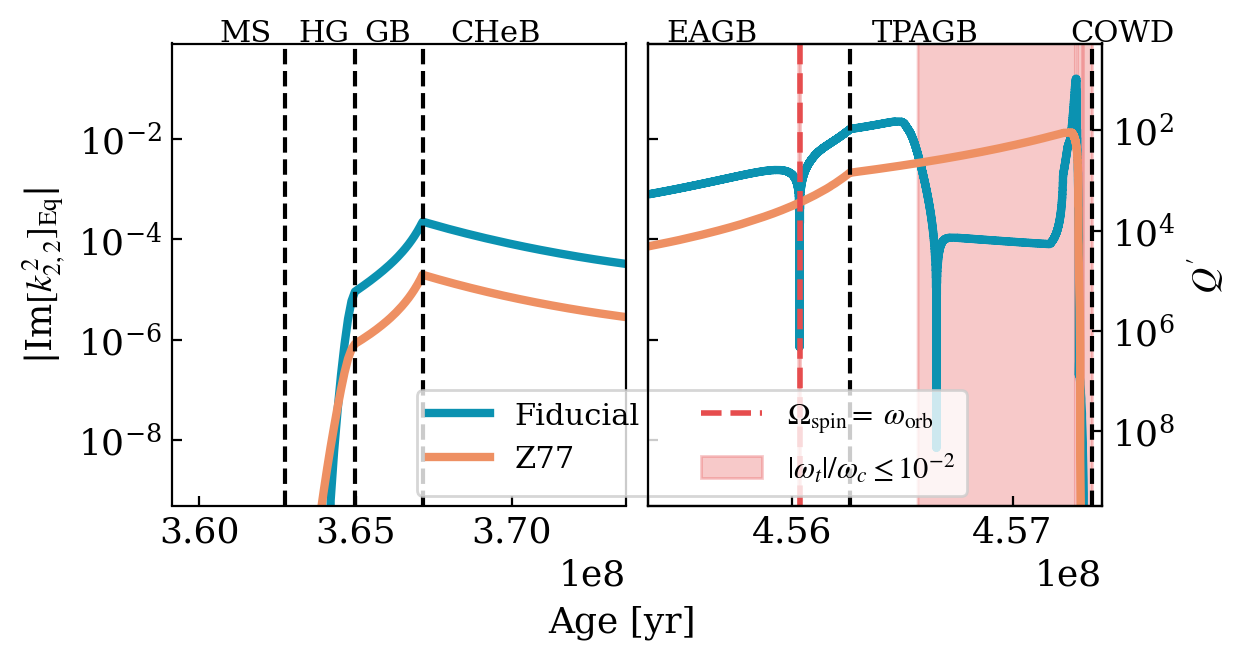

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6,3), sharey=True)
    
imk_min = 5e-10 # HG Mass 
imk_max = 8e-1 # HG Mass

tidal_frequency_22 = np.abs(2*omega_orb - 2*omega_spin)
omega_c = 1/tau_conv

omega_pseudosync = (1 + (15/2)*ecc**2 + (45/8)*ecc**4 + (5/16)*ecc**6)/ ((1 + 3*ecc**2 + (3/8)*ecc**4)*(1-ecc**2)**(3/2)) * omega_orb

omega_pseudosync_zahn = (1 + (15/2)*ecc_zahn**2 + (45/8)*ecc_zahn**4 + (5/16)*ecc_zahn**6)/ ((1 + 3*ecc_zahn**2 + (3/8)*ecc_zahn**4)*(1-ecc_zahn**2)**(3/2)) * omega_orb_zahn

for ax in axes:
    ax.plot(Time, np.abs(Imk22_eq), lw=3, c=colorPalette['blue'], label=this_work)
    ax.plot(Time_zahn, np.abs(Imk22_eq_zahn), lw=3, c=colorPalette['orange'], label=that_work)

    sync_idx = np.where(np.abs(df_sanity["Omega1"]) >  df_sanity["Omega"])[0][0]
    ax.axvline(Time[sync_idx].value, color=colorPalette['red'], lw=2, ls='--', label='$\Omega_{\\rm spin} = \; \omega_{\\rm orb}$')
    ax.fill_between(Time.value, 1e2, where=((np.abs((tidal_frequency_22/omega_c).value) <= 1e-2) & (Time.value > 4e8)), color=colorPalette['red'], alpha=0.3, label='$|\\omega_{t}| / \omega_c \leq 10^{-2}$')

    ax.set_ylim(imk_min, imk_max)

ax = axes[0]
ax.set_xlim(0.99*hg_time, 1.03*hg_time) # HG Mass

ax.set_yscale('log')
ax.tick_params(axis='both', which='both', direction='in')

ax.set_ylabel("|Im$[k_{2,2}^2 ]_{\\rm Eq}$|")

ax.text(Time[hg_idx].value-2.1e6, 1.1*imk_max, s="MS", fontsize=11) # HG Mass

ax.axvline(Time[hg_idx].value, c='k', ls='--')
ax.text(Time[hg_idx].value+4e5, 1.1*imk_max, s="HG", fontsize=11) # HG Mass

ax.axvline(Time[gb_idx].value, c='k', ls='--')
ax.text(Time[gb_idx].value+3e5, 1.1*imk_max, s="GB", fontsize=11) # HG Mass

ax.axvline(Time[cheb_idx].value, c='k', ls='--')
ax.text(Time[cheb_idx].value+9e5, 1.1*imk_max, s="CHeB", fontsize=11)# HG Mass




ax = axes[1]
ax.set_xlim(0.998*tpagb_time, 1.0001*Time[-1].value) # HG Mass

ax.set_yscale('log')
ax.tick_params(axis='both', which='both', direction='in')


ax2 = ax.twinx() 
ax2.set_ylim(3/(2*imk_min), 3/(2*imk_max))
ax2.set_yscale('log')
ax2.set_ylabel("$Q'$")
ax2.tick_params(axis='both', which='both', direction='in', bottom=False)


ax.text(Time[eagb_idx].value+2.2e6, 1.1*imk_max, s="EAGB", fontsize=11)# HG Mass
# ax.axvline(Time[eagb_idx].value, c='k', ls='--')
ax.text(Time[tpagb_idx].value+1e5, 1.1*imk_max, s="TPAGB", fontsize=11)# HG Mass
ax.axvline(Time[tpagb_idx].value, c='k', ls='--')
ax.text(Time[wd_idx].value-1e5, 1.1*imk_max, s="COWD", fontsize=11)# HG Mass
ax.axvline(Time[wd_idx].value, c='k', ls='--')


ax.legend(fontsize=11, loc=(-.51, 0.02), ncols=2) # HG Mass

fig.text(0.5, -0.1, 'Age [yr]', ha='center')
plt.subplots_adjust(wspace=0.05, hspace=0)

plt.savefig(PlotDir+plot_prefix+'imk22_eq.pdf',dpi=300, bbox_inches='tight')

plt.show()

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


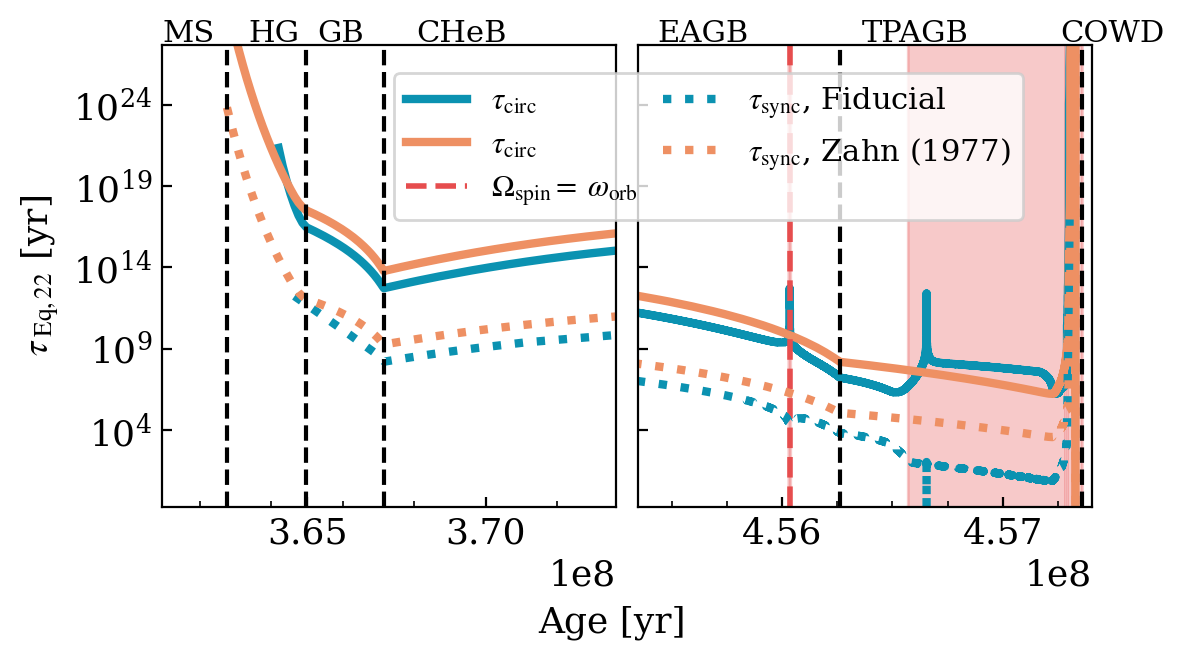

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6,3), sharey=True)

for ax in axes:

    ax.plot(Time, np.abs(1/tau_circ_inv_eq_22), c=colorPalette['blue'], lw=3, label="$\\tau_{\\rm circ}$")
    ax.plot(Time_zahn, np.abs(1/tau_circ_inv_zahn_eq), c=colorPalette['orange'],  lw=3, label="$\\tau_{\\rm circ} \;$")

    sync_idx = np.where(np.abs(df_sanity["Omega1"]) >  df_sanity["Omega"])[0][0]
    ax.axvline(Time[sync_idx].value, color=colorPalette['red'], lw=2, ls='--', label='$\Omega_{\\rm spin} = \; \omega_{\\rm orb}$')

    ax.plot(Time[::30], np.abs(1/tau_sync_inv_eq_22)[::30], c=colorPalette['blue'], ls=':', lw=3, label="$\\tau_{\\rm sync}$, "+this_work)
    ax.plot(Time_zahn, np.abs(1/tau_sync_inv_zahn_eq), c=colorPalette['orange'],  ls=':', lw=3, label="$\\tau_{\\rm sync}$, Zahn (1977)")

    

    ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
    ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_yscale('log')

    tau_min = 2e-1
    tau_max = 5e27
    ax.set_ylim(tau_min, tau_max)

ax = axes[0]
ax.set_xlim(0.995*hg_time, 1.03*hg_time) # HG Mass

ax.text(Time[hg_idx].value-1.8e6, 1.5*tau_max, s="MS", fontsize=11) # HG Mass
ax.axvline(Time[hg_idx].value, c='k', ls='--')
ax.text(Time[hg_idx].value+6e5, 1.5*tau_max, s="HG", fontsize=11) # HG Mass
ax.axvline(Time[gb_idx].value, c='k', ls='--')
ax.text(Time[gb_idx].value+3e5, 1.5*tau_max, s="GB", fontsize=11) # HG Mass
ax.axvline(Time[cheb_idx].value, c='k', ls='--')
ax.text(Time[cheb_idx].value+9e5, 1.5*tau_max, s="CHeB", fontsize=11)# HG Mass

ax.set_ylabel("$\\tau_{\\rm \; Eq, 22}$ [yr]")

ax = axes[1]
ax.set_xlim(0.998*tpagb_time, 1.0001*Time[-1].value) # HG Mass

ax.text(Time[eagb_idx].value+2.2e6, 1.5*tau_max, s="EAGB", fontsize=11)# HG Mass
# ax.axvline(Time[eagb_idx].value, c='k', ls='--')
ax.text(Time[tpagb_idx].value+1e5, 1.5*tau_max, s="TPAGB", fontsize=11)# HG Mass
ax.axvline(Time[tpagb_idx].value, c='k', ls='--')
ax.text(Time[wd_idx].value-1e5, 1.5*tau_max, s="COWD", fontsize=11)# HG Mass
ax.axvline(Time[wd_idx].value, c='k', ls='--')

ax.fill_between(Time.value, tau_max, where=((np.abs((tidal_frequency_22/omega_c).value) <= 1e-2) & (Time.value > 4.56e8)), color=colorPalette['red'], alpha=0.3)



ax.legend(loc=(-0.54, 0.62), ncol=2, fancybox=True, fontsize=11, columnspacing=.8)

fig.text(0.5, -0.1, 'Age [yr]', ha='center')
plt.subplots_adjust(wspace=0.05, hspace=0)

plt.savefig(PlotDir+plot_prefix+'tau_circ_sync_eq.pdf',dpi=300, bbox_inches='tight')

plt.show()

### Dynamical Tide with Radiative Damping

#### Fiducial

In [32]:
# Total Dynamical Tide
dedt1_dyn = -(3/4) * (1/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*Imk10_dyn/2) - (Imk12_dyn/4) - Imk22_dyn + (49*Imk32_dyn/4))
tau_circ_inv_dyn = - dedt1_dyn
(1/tau_circ_inv_dyn)[cheb_idx-1:]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [inf, inf, inf, ..., inf, inf, inf] yr>

In [33]:
# (2,2) Dynamical Tide
dedt1_dyn_22 = -(3/4) * (1/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- Imk22_dyn)
tau_circ_inv_dyn_22 = - dedt1_dyn_22
(1/tau_circ_inv_dyn_22)[cheb_idx-1:]

<Quantity [-inf, -inf, -inf, ..., -inf, -inf, -inf] yr>

In [34]:
dOmegadt1_dyn = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_dyn + ecc**2 * ((Imk12_dyn/4) - (5*Imk22_dyn) + (49*Imk32_dyn/4)))
tau_sync_inv_dyn = - dOmegadt1_dyn / (omega_spin - omega_orb)
(1/tau_sync_inv_dyn)[cheb_idx-1:]

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [ inf,  inf,  inf, ..., -inf, -inf, -inf] yr>

In [35]:
dOmegadt1_dyn_22 = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (Imk22_dyn)
tau_sync_inv_dyn_22 = - dOmegadt1_dyn_22 / (omega_spin - omega_orb)
1/tau_sync_inv_dyn_22

<Quantity [1.01474844e+27, 1.01481742e+27, 1.08856271e+27, ...,
                     -inf,           -inf,           -inf] yr>

##### Core only, IGWs

In [36]:
E2_kushnir = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.)
E2_kushnir

<Quantity [5.87648918e-08, 5.87591499e-08, 5.29091489e-08, ...,
           6.68186631e-02, 6.67395401e-02, 6.66666667e-02]>

In [37]:
l=1
m=0
imk10_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk10_core_gw[np.isnan(imk10_core_gw)] = 0.0

l=1
m=2
imk12_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk12_core_gw[np.isnan(imk12_core_gw)] = 0.0

l=2
m=2
imk22_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk22_core_gw[(rc_AU/R_AU < frac_limit) | (Mc/M < frac_limit) | (Menv/M > frac_limit) | (Renv/R_AU > frac_limit)] = 0.0
imk22_core_gw[np.isnan(imk22_core_gw)] = 0.0

l=3
m=2
imk32_core_gw = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (((l*omega_orb)- (m*omega_spin)) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)
imk32_core_gw[np.isnan(imk32_core_gw)] = 0.0

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [38]:
dedt1_dyn_core_gw = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*imk10_core_gw/2) - (imk12_core_gw/4) - imk22_core_gw + (49*imk32_core_gw/4))
tau_circ_inv_dyn_core_gw = - dedt1_dyn_core_gw / ecc
tau_circ_inv_dyn_core_gw

<Quantity [2.47769916e-33, 2.47756626e-33, 2.33272707e-33, ...,
           6.73221780e-55, 4.96687453e-55, 4.75559932e-55] 1 / yr>

In [39]:
dOmegadt1_dyn_core_gw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_core_gw + ecc**2 * ((imk12_core_gw/4) - (5*imk22_core_gw) + (49*imk32_core_gw/4)))
tau_sync_inv_dyn_core_gw = - dOmegadt1_dyn_core_gw / (omega_spin - omega_orb)
tau_sync_inv_dyn_core_gw

<Quantity [ 8.66170493e-27,  8.66120281e-27,  8.07432168e-27, ...,
           -0.00000000e+00, -0.00000000e+00, -0.00000000e+00] 1 / yr>

##### Envelope only, IGWs

In [40]:
dNlnr_cbrt = (G_AU_Msol_yr * Mint / (Rint_AU * (R_AU - Rint_AU)**2))**(1/3)

alpha = Rint_AU/R_AU
beta = Mint/M

one_minus_beta = Menv/M

rho_conv = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3))
rho_rad = Mint / (4 * np.pi * (Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

Epsilon = alpha**11 * (one_minus_beta) * (1-gamma)**2 * (2*alpha/3 - 1)**2 / (beta**2 * (1-alpha**3) * (1-alpha)**2)

n=2
l=1
m=0
imk10_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (n*(n+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk10_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk10_env_gw)
imk10_env_gw[np.isnan(imk10_env_gw)] = 0.0

l=1
m=2
imk12_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (n*(n+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk12_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk12_env_gw)
imk12_env_gw[np.isnan(imk12_env_gw)] = 0.0

l=2
m=2
imk22_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (n*(n+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk22_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk22_env_gw)
imk22_env_gw[(Renv_AU/R_AU < frac_limit) | (Menv/M < frac_limit) | (Mc/M > frac_limit)] = 0.0
imk22_env_gw[np.isnan(imk22_env_gw)] = 0.0


l=3
m=2
imk32_env_gw = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (n*(n+1))**(-4/3) * np.abs((l*omega_orb)- (m*omega_spin))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk32_env_gw = np.sign(l*omega_orb - m*omega_spin) * np.abs(imk32_env_gw)
imk32_env_gw[np.isnan(imk32_env_gw)] = 0.0

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [41]:
dedt1_dyn_env_gw = -(3/4) * (ecc/omega_orb) * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * ((3*imk10_env_gw/2) - (imk12_env_gw/4) - imk22_env_gw + (49*imk32_env_gw/4))
tau_circ_inv_dyn_env_gw = - dedt1_dyn_env_gw / ecc
tau_circ_inv_dyn_env_gw

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in subtract
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [0., 0., 0., ..., 0., 0., 0.] 1 / yr>

In [42]:
dOmegadt1_dyn_env_gw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_env_gw + ecc**2 * ((imk12_env_gw/4) - (5*imk22_env_gw) + (49*imk32_env_gw/4)))
tau_sync_inv_dyn_env_gw = - dOmegadt1_dyn_env_gw / (omega_spin - omega_orb)
tau_sync_inv_dyn_env_gw

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in add
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [ 0.,  0.,  0., ..., -0., -0., -0.] 1 / yr>

##### Envelope only, IWs

In [43]:
alpha = Rint_AU/R_AU
beta = Mint/M
one_minus_beta = Menv/M

rho_conv = Menv / ((R_AU**3 - Rint_AU**3))
rho_rad = Mint / ((Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad

eps = omega_spin / np.sqrt(G_AU_Msol_yr * M / R_AU**3)

b1 = (1 + 2*alpha + 3*alpha**2 + (3/2)*alpha**3)
b2 = 1 + ((1-gamma) / gamma) * alpha**3
b3 = 1 + (3*gamma/2) + ((5*alpha**3)/(2*gamma))*(1 + gamma/2 - (3*gamma**2)/2) - (9/4)*(1-gamma)*alpha**5
imk22_inertial = (100 * np.pi / 63) * eps**2 * (alpha**5 / (1 - alpha**5)) * (1-gamma)**2 * (1-alpha)**4 * b1**2 * b2 * b3**(-2)

imk22_inertial[((Renv_AU/R_AU < frac_limit) & (Menv/M < frac_limit)) | (omega_orb > 2*omega_spin) | (Mint/M < frac_limit)] = 0.0
imk22_inertial = np.sign(omega_orb - omega_spin) * np.abs(imk22_inertial)
imk22_inertial[np.isnan(imk22_inertial)] = 0.0

In [44]:
dedt1_dyn_env_iw_22 = -(3/4)  * ((M + M2)/M) * (G_AU_Msol_yr*M2 / R_AU**3) * (R_AU/sma)**8 * (- imk22_inertial)
tau_circ_inv_dyn_env_iw_22 = - dedt1_dyn_env_iw_22
tau_circ_inv_dyn_env_iw_22[cheb_idx-80:cheb_idx]

<Quantity [-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0.] 1 / yr2>

In [45]:
dOmegadt1_dyn_env_iw = (3/2) * (1/I1) * (G_AU_Msol_yr*M2*M2 / R_AU) * (R_AU/sma)**6 * (imk22_inertial + ecc**2 * (-5*imk22_inertial))
tau_sync_inv_dyn_env_iw_22 = - dOmegadt1_dyn_env_iw 
tau_sync_inv_dyn_env_iw_22[cheb_idx-80:cheb_idx]

<Quantity [-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
           -0., -0.] 1 / yr2>

#### Z77

In [46]:
dedt1_dyn_22 = -(3/4) * (1/omega_orb_zahn) * ((M_zahn + M2_zahn)/M_zahn) * (G_AU_Msol_yr*M2_zahn / R_AU_zahn**3) * (R_AU_zahn/sma_zahn)**8 * (- Imk22_dyn_zahn)
tau_circ_inv_zahn_dyn = - dedt1_dyn_22
1/tau_circ_inv_zahn_dyn

<Quantity [-2.32311950e+34, -2.32302904e+34, -2.22162786e+34, ...,
            1.48126661e+62,  1.59268909e+62,  1.59340587e+62] yr>

In [47]:
dOmegadt1_dyn_22 = (3/2) * (1/I1_zahn) * (G_AU_Msol_yr*M2_zahn*M2_zahn / R_AU_zahn) * (R_AU_zahn/sma_zahn)**6 * (Imk22_dyn_zahn)
tau_sync_inv_zahn_dyn = - dOmegadt1_dyn_22 / (omega_spin_zahn - omega_orb_zahn)
1/tau_sync_inv_zahn_dyn

<Quantity [1.65392414e+27, 1.65386690e+27, 1.59745282e+27, ...,
           7.81951285e+49, 8.41264622e+49, 8.41712140e+49] yr>

#### Plots

In [48]:
Imk22_dyn_zahn[st1_zahn>=10] = 0

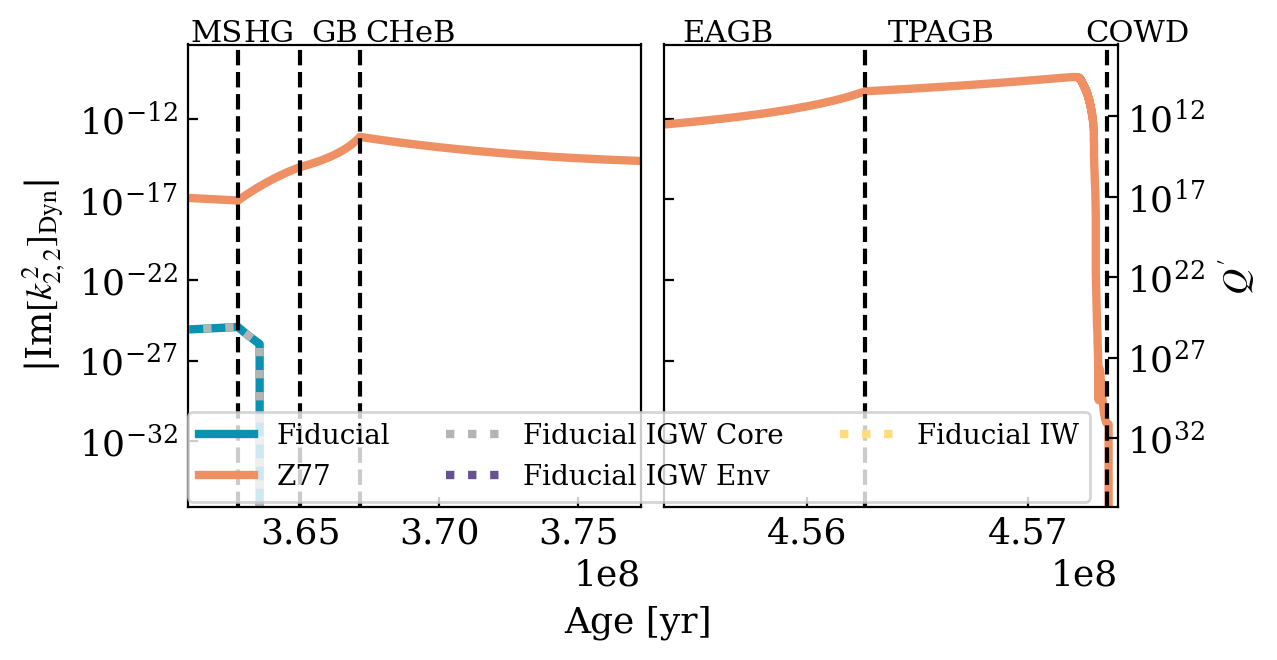

In [49]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6,3), width_ratios=[2, 2], sharey=True)

# Plot lines

for ax in axes:
    ax.plot(Time, np.abs(Imk22_dyn), lw=3, c=colorPalette['blue'], label=this_work)
    ax.plot(Time_zahn, np.abs(Imk22_dyn_zahn), lw=3, c=colorPalette['orange'], label=that_work)

    ax.plot(Time, np.abs(imk22_core_gw), c=colorPalette['gray'], lw=3, ls=':', label=this_work+" IGW Core")
    ax.plot(Time, np.abs(imk22_env_gw), c=colorPalette['violet'], lw=3, ls=':', label=this_work+" IGW Env")
    ax.plot(Time, np.abs(imk22_inertial), c=colorPalette['yellow'], lw=3, ls=':', label=this_work+" IW")    

    
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_yscale('log')
    imk_min = 9e-37 # HG Mass
    imk_max = 4e-8 # HG Mass
    ax.set_ylim(imk_min, imk_max)

# Left Plot
ax = axes[0]
ax.set_xlim(0.995*hg_time, 1.04*hg_time) # HG Mass

ax.text(Time[hg_idx].value-1.7e6, 1.5*imk_max, s="MS", fontsize=11, zorder=100) # HG Mass
ax.axvline(Time[hg_idx].value, c='k', ls='--')
ax.text(Time[hg_idx].value+2e5, 1.5*imk_max, s="HG", fontsize=11) # HG Mass
ax.axvline(Time[gb_idx].value, c='k', ls='--')
ax.text(Time[gb_idx].value+4e5, 1.5*imk_max, s="GB", fontsize=11) # HG Mass
ax.axvline(Time[cheb_idx].value, c='k', ls='--')
ax.text(Time[cheb_idx].value+2e5, 1.5*imk_max, s="CHeB", fontsize=11) # HG Mass

ax.set_ylabel("|Im$[k_{2,2}^2 ]_{\\rm Dyn}$|")



ax = axes[1]
ax.set_xlim(0.998*tpagb_time, 1.0001*Time[-1].value) # HG Mass

ax.text(Time[eagb_idx].value+2.2e6, 1.5*imk_max, s="EAGB", fontsize=11)# HG Mass
ax.axvline(Time[eagb_idx].value, c='k', ls='--')
ax.text(Time[tpagb_idx].value+1e5, 1.5*imk_max, s="TPAGB", fontsize=11)# HG Mass
ax.axvline(Time[tpagb_idx].value, c='k', ls='--')
ax.text(Time[wd_idx].value-1e5, 1.5*imk_max, s="COWD", fontsize=11)# HG Mass
ax.axvline(Time[wd_idx].value, c='k', ls='--')

sync_idx = np.where(np.abs(df_sanity["Omega1"]) >  df_sanity["Omega"])[0][0]


ax.legend(loc=(-1.05, 0.01), fontsize=10, ncols=3)


# Twin Axis
ax2 = ax.twinx() 
ax2.tick_params(left = False, bottom=False) 
ax2.set_ylim(3/(2*imk_min), 3/(2*imk_max))
ax2.set_yscale('log')
ax2.set_ylabel("$Q'$")
for spine in ax2.spines:
    ax2.spines[spine].set_visible(False)
ax2.tick_params(axis='both', which='both', direction='in')


fig.text(0.5, -0.1, 'Age [yr]', ha='center')
plt.subplots_adjust(wspace=0.05, hspace=0)

plt.savefig(PlotDir+plot_prefix+'imk22_dyn.pdf',dpi=300, bbox_inches='tight')

plt.show()

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


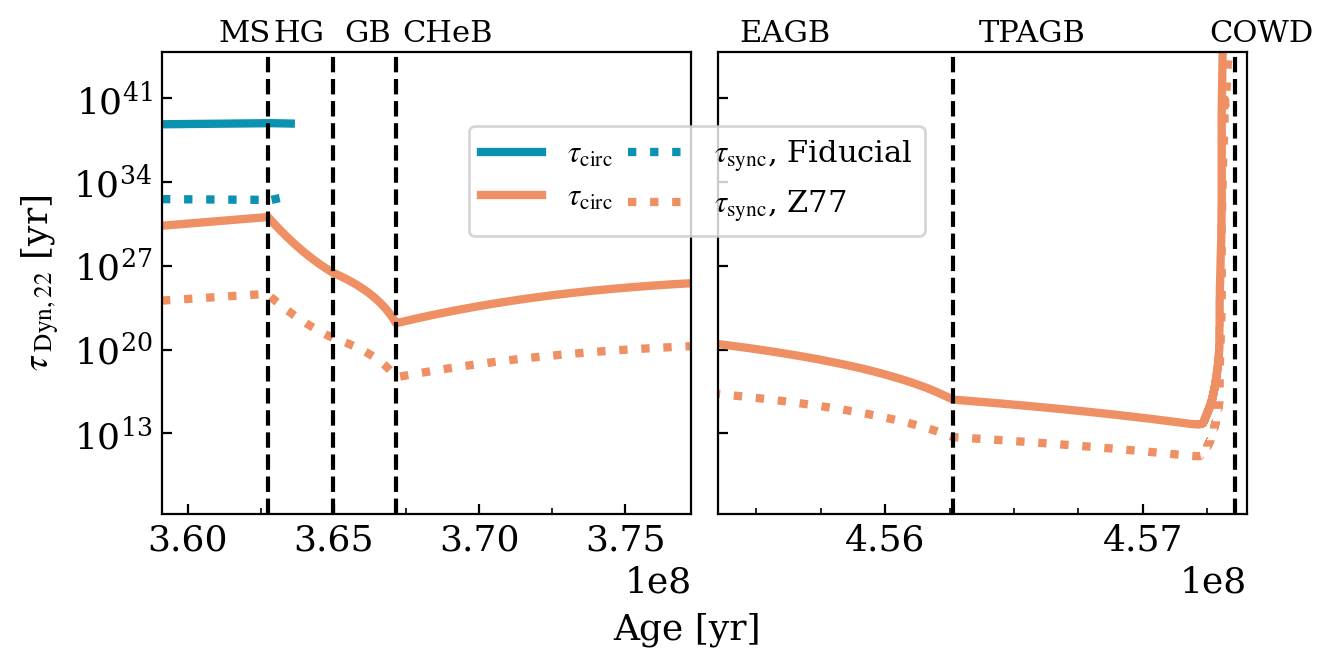

In [50]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7,3), width_ratios=[2, 2], sharey=True)

for ax in axes:
    ax.plot(Time, np.abs(1/tau_circ_inv_dyn_22), c=colorPalette['blue'], lw=3, label="$\\tau_{\\rm circ} \;$")
    ax.plot(Time_zahn, np.abs(1/tau_circ_inv_zahn_dyn),c=colorPalette['orange'], lw=3, label="$\\tau_{\\rm circ} \;$")

    sync_idx = np.where(np.abs(df_sanity["Omega1"]) >  df_sanity["Omega"])[0][0]

    ax.plot(Time, np.abs(1/tau_sync_inv_dyn_22), c=colorPalette['blue'], lw=3, ls=':', label="$\\tau_{\\rm sync}$, "+this_work)
    ax.plot(Time_zahn, np.abs(1/tau_sync_inv_zahn_dyn),c=colorPalette['orange'], lw=3, ls=':', label="$\\tau_{\\rm sync}$, "+that_work)

    ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
    ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
    ax.tick_params(axis='both', which='both', direction='in')

    ax.set_yscale('log')
    ax.set_ylim(2e6, 8e44)

# Left Plot
ax = axes[0]
ax.set_xlim(0.99*hg_time, 1.04*hg_time) # HG Mass

ax.text(Time[hg_idx].value-1.7e6, 5e45, s="MS", fontsize=11, zorder=100) # HG Mass
ax.axvline(Time[hg_idx].value, c='k', ls='--')
ax.text(Time[hg_idx].value+2e5, 5e45, s="HG", fontsize=11) # HG Mass
ax.axvline(Time[gb_idx].value, c='k', ls='--')
ax.text(Time[gb_idx].value+4e5, 5e45, s="GB", fontsize=11) # HG Mass
ax.axvline(Time[cheb_idx].value, c='k', ls='--')
ax.text(Time[cheb_idx].value+2e5, 5e45, s="CHeB", fontsize=11) # HG Mass

ax.set_ylabel("$\\tau_{\\rm \; Dyn, 22}$ [yr]")


ax = axes[1]
ax.set_xlim(0.998*tpagb_time, 1.0001*Time[-1].value) # HG Mass

ax.text(Time[eagb_idx].value+2.2e6, 5e45, s="EAGB", fontsize=11)# HG Mass
# ax.axvline(Time[eagb_idx].value, c='k', ls='--')
ax.text(Time[tpagb_idx].value+1e5, 5e45, s="TPAGB", fontsize=11)# HG Mass
ax.axvline(Time[tpagb_idx].value, c='k', ls='--')
ax.text(Time[wd_idx].value-1e5, 5e45, s="COWD", fontsize=11)# HG Mass
ax.axvline(Time[wd_idx].value, c='k', ls='--')

ax.legend(loc=(-0.47, 0.6), ncol=2, fancybox=True, fontsize=11, columnspacing=0.5)

fig.text(0.5, -0.1, 'Age [yr]', ha='center')
plt.subplots_adjust(wspace=0.05, hspace=0)
plt.savefig(PlotDir+plot_prefix+'tau_circ_sync_dyn.pdf',dpi=300, bbox_inches='tight')

plt.show()

### Compare Tidal Dissipation Mechanisms

In [207]:
compare_tides(df_sanity, imk22_core_gw, imk22_env_gw, imk22_inertial, Imk22_eq)

Convective core, NO radiative intershell, convective envelope:
Timesteps found: 21720
Stellar Types found: ['EAGB', 'TPAGB']
Dynamical tides from convective core - radiative shell boundary: 0.0
Dynamical tides from radiative shell - convective envelope boundary: 0.0
*Dynamical tides from convective envelope IW dissipation: 0.0
*Equilibrium tides from convective envelope: 98.5938802506951

Convective core, radiative intershell, convective envelope:
Timesteps found: 4081
Stellar Types found: ['HG', 'FGB', 'CHeB', 'EAGB']
Dynamical tides from convective core - radiative shell boundary: 0.0
Dynamical tides from radiative shell - convective envelope boundary: 0.0
*Dynamical tides from convective envelope IW dissipation: 0.0
*Equilibrium tides from convective envelope: 0.580349883020493

Convective core, radiative envelope:
Timesteps found: 1970
Stellar Types found: ['MS_GT_0.7', 'HG']
*Dynamical tides from convective core - radiative shell boundary: 2.7686915279785467e-17
Dynamical tides fr

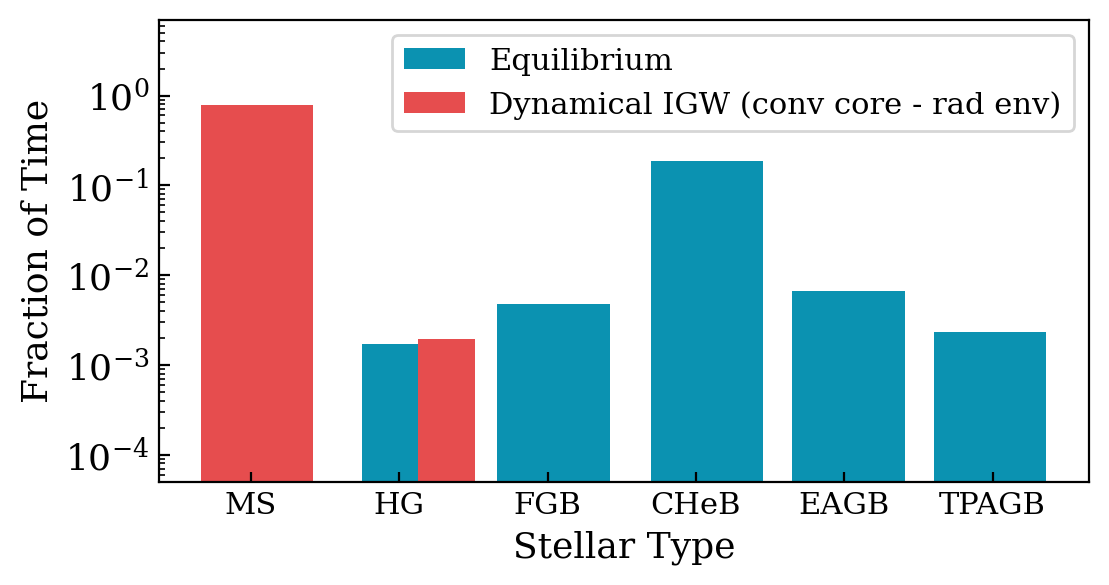

In [51]:
bins = np.linspace(-0.5, len(st_labels_plot)-0.5, len(st_labels_plot))

# Compute the fraction of the final time
total_time = df_sanity["Time"].values[-1] + df_sanity["Dt"].values[-1]

# Compute the sum of Dt for each stellar type
frac_dt_eq = df_sanity.loc[(np.abs(df_sanity["ImK22_1_eq"]) > 0)].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_core = df_sanity.loc[(np.abs(imk22_core_gw) > 0)].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_env = df_sanity.loc[(np.abs(imk22_env_gw) > 0)].groupby("StellarType_1")["Dt"].sum() / total_time
frac_dt_dyn_iw = df_sanity.loc[(np.abs(imk22_inertial) > 0)].groupby("StellarType_1")["Dt"].sum() / total_time

# Generally group together MS types to make labels smaller
frac_dt_eq.index = frac_dt_eq.index.where(frac_dt_eq.index != 0, 1)
frac_dt_dyn_core.index = frac_dt_dyn_core.index.where(frac_dt_dyn_core.index != 0, 1)
frac_dt_dyn_env.index = frac_dt_dyn_env.index.where(frac_dt_dyn_env.index != 0, 1)
frac_dt_dyn_iw.index = frac_dt_dyn_iw.index.where(frac_dt_dyn_iw.index != 0, 1)

unique_idxs = np.unique(np.concatenate([frac_dt_eq.index.values, frac_dt_dyn_core.index.values, frac_dt_dyn_env.index.values, frac_dt_dyn_iw.index.values]))

# Plot bar chart
fig, ax = plt.subplots(nrows=1, figsize=(6, 3))

for idx in unique_idxs:
    n_bars = ((idx in frac_dt_eq.index) + (idx in frac_dt_dyn_core.index) + (idx in frac_dt_dyn_env.index) + (idx in frac_dt_dyn_iw.index))

    bar_width = 0.8 / n_bars

    offset = 0.1 / n_bars - 0.01/np.abs(idx-3.1)

    if idx in frac_dt_eq.index:
        if bar_width > 0.4:
            extra_offset = bar_width/4
        else:
            extra_offset = -0.0
        ax.bar(idx + offset + extra_offset, frac_dt_eq[idx], alpha=1.0, label="Equilibrium" if idx == frac_dt_eq.index[0] else "", width=bar_width, color=colorPalette['blue'])
        offset += bar_width

    if idx in frac_dt_dyn_core.index:
        if idx==8:
            ax.bar(idx + 0.4, frac_dt_dyn_core[idx], alpha=1.0, label="Dynamical IGW (conv core - rad env)" if idx == frac_dt_dyn_core.index[0] else "", width=bar_width, color=colorPalette['red'])
        else:
            ax.bar(idx + offset, frac_dt_dyn_core[idx], alpha=1.0, label="Dynamical IGW (conv core - rad env)" if idx == frac_dt_dyn_core.index[0] else "", width=bar_width, color=colorPalette['red'])
        offset += bar_width

    if idx in frac_dt_dyn_env.index:
        ax.bar(idx + offset, frac_dt_dyn_env[idx], alpha=1.0, label="Dynamical IGW (rad core - conv env)" if idx == frac_dt_dyn_env.index[0] else "", width=bar_width, color=colorPalette['orange'])
        offset += bar_width

    if idx in frac_dt_dyn_iw.index:
        ax.bar(idx + offset, frac_dt_dyn_iw[idx], alpha=1.0, label="Dynamical IW" if idx == frac_dt_dyn_iw.index[0] else "", width=bar_width, color=colorPalette['violet'])

# Set x-axis labels to the stellar types
ax.set_xticks(bins+0.5, labels=st_labels_plot, rotation=0, fontsize=11)
ax.tick_params(axis='y', size=10)

ax.set_xlim(0.4, len(st_labels_plot)-13)
ax.set_ylabel("Fraction of Time")
ax.set_xlabel('Stellar Type')

ax.tick_params(axis='both', which='both', direction='in')
ax.tick_params(axis='y', length=4)
ax.set_ylim(5e-5, 7e0)
ax.set_yscale('log')

handles, labels = ax.get_legend_handles_labels()
# order = [1, 0, 2]
order = [1, 0]
ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], fontsize=11)
# 
plt.savefig(PlotDir+plot_prefix+'tides_type.pdf',dpi=300, bbox_inches='tight')
plt.show()